# BATTERY SOH PREDICTION USING NASA PCOE DATASET

## Table of Contents

1. [DATA UNDERSTANDING](#data-understanding)
2. [DATA PREPARATION](#data-preparation)
    - [Feature Engineering](#feature-engineering)
3. [MODEL BUILDING](#model-building)
    - [Part I: Discharge model](#part-i-discharge-model)
    - [Part II: Charge model](#part-ii-charge-domain)
    - [RUL Extrapolation](#estimating-remaining-useful-life-rul)
4. [MODEL EVALUATION](#model-evaluation)
5. [MODEL EXPLAINABILITY](#model-explainability)
6. [DEPLOYMENT](#deployment)

## Import Libraries

In [1]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import shap

import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr

c:\Users\shast\Documents\Data_warehouse\python\pyenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data and Model Configuration

Intialize variables to store data and model configuration information

In [2]:
DATA_DIR = Path("./data")
RESULTS_DIR = Path("./results")
RANDOM_STATE = 42

Initialize Variables to load fixed data objects

In [3]:
BATTERIES = ["B0005", "B0006", "B0007", "B0018"] #B0036
q_rated = {
    "B0005": 2.00,
    "B0006": 2.00,
    "B0007": 2.00,
    "B0018": 2.00,
    "B0036": 2.00
}
df_qrated = pd.DataFrame.from_dict(q_rated, orient="index", columns=["Q_rated_Ah"])
df_qrated.index.name = "battery"
df_qrated = df_qrated.reset_index()
df_qrated

,battery,Q_rated_Ah
0,B0005,2.0
1,B0006,2.0
2,B0007,2.0
3,B0018,2.0
4,B0036,2.0


# DATA UNDERSTANDING

## Data Loading
Load one .mat file and return a flat DataFrame of all discharge timesteps.

```
Data = 
[discharge] = [voltage, current and temperature fields associted with discharge cycle of each battery] 
[charge] = [voltage, current and temperature fields associted with charge cycle of each battery]
[EIS] = [Fields measuring the current and voltage in AC conditions]
```

In [4]:
# Data Loading
def load_battery(battery_id: str):
    path = DATA_DIR / f"{battery_id}.mat"
    mat = scipy.io.loadmat(str(path), simplify_cells=True)
    cycles = mat[battery_id]["cycle"]

    rows = []
    discharge_idx = 0

    for raw_cycle in cycles:
        if raw_cycle["type"] != "discharge":
            continue

        discharge_idx += 1
        d = raw_cycle["data"]
        n = len(d["Time"])
        capacity_Ah = float(d["Capacity"])

        for i in range(n):
            rows.append({
                "battery": battery_id,
                "cycle": discharge_idx,
                "ambient_temp_C": float(raw_cycle["ambient_temperature"]),
                "timestep": i,
                "Time": d["Time"][i],
                "Voltage_measured": d["Voltage_measured"][i],
                "Current_measured": d["Current_measured"][i],
                "Temperature_measured": d["Temperature_measured"][i],
                "Current_load": d["Current_load"][i],
                "Voltage_load": d["Voltage_load"][i],
                "capacity_Ah": capacity_Ah
            })

    return pd.DataFrame(rows)

def load_all_cycles(battery_id):
    path = DATA_DIR / f"{battery_id}.mat"
    mat = scipy.io.loadmat(str(path), simplify_cells=True)
    cycles = mat[battery_id]["cycle"]

    charge_cycles = []
    discharge_caps = {}
    charge_idx = 0
    discharge_idx = 0

    for raw in cycles:
        if raw["type"] == "charge":
            charge_idx += 1
            charge_cycles.append({
                "battery": battery_id,
                "charge_cycle": charge_idx,
                "ambient_temp": float(raw["ambient_temperature"]),
                "data": raw["data"]
            })

        elif raw["type"] == "discharge":
            discharge_idx += 1
            cap = float(raw["data"]["Capacity"])
            discharge_caps[discharge_idx] = cap

    return charge_cycles, discharge_caps

In [5]:
# CV phase current decay
def exponential_cv(t, HF4, HF5, HF6):
    return HF4 + HF5 * np.exp(-t / HF6)

Prepare the base data with the discharge data from all the selected batteries.

In [6]:
# Merge all battery data into a single DataFrame
raw_dfs = []
for bat in BATTERIES:
    df_bat = load_battery(bat)
    raw_dfs.append(df_bat)
    print(f"{bat}: {df_bat['cycle'].nunique():>3} discharge cycles, "
          f"{len(df_bat):>6,} timesteps")

raw_df = pd.concat(raw_dfs, ignore_index=True)

# Sanity checks
print(raw_df[["Voltage_measured","Current_measured","Temperature_measured","Time","capacity_Ah"]].describe().round(4))

B0005: 168 discharge cycles, 50,285 timesteps
B0006: 168 discharge cycles, 50,285 timesteps
B0007: 168 discharge cycles, 50,285 timesteps
B0018: 132 discharge cycles, 34,866 timesteps
       Voltage_measured  Current_measured  Temperature_measured         Time  \
count       185721.0000       185721.0000           185721.0000  185721.0000   
mean             3.4972           -1.8326               32.3790    1546.3799   
std              0.2517            0.5614                4.0277     906.9586   
min              1.7370           -2.0291               22.3503       0.0000   
25%              3.3777           -2.0114               29.5706     764.7970   
50%              3.5009           -2.0090               32.3557    1537.0310   
75%              3.6558           -1.9900               35.4207    2307.4850   
max              4.2333            0.0143               42.3325    3690.2340   

       capacity_Ah  
count  185721.0000  
mean        1.5749  
std         0.1906  
min        

In [7]:
raw_df.head()

,battery,cycle,ambient_temp_C,timestep,Time,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,capacity_Ah
0,B0005,1,24.0,0,0.000,4.191492,-0.004902,24.330034,-0.0006,0.000,1.856487
1,B0005,1,24.0,1,16.781,4.190749,-0.001478,24.325993,-0.0006,4.206,1.856487
2,B0005,1,24.0,2,35.703,3.974871,-2.012528,24.389085,-1.9982,3.062,1.856487
3,B0005,1,24.0,3,53.781,3.951717,-2.013979,24.544752,-1.9982,3.030,1.856487
4,B0005,1,24.0,4,71.922,3.934352,-2.011144,24.731385,-1.9982,3.011,1.856487


### What is State of Health (SOH) in Battery technology?
Extract the cycle capacity (SOH): Target Variable for Regression Analysis

SOH is a percentage measure of how much usable capacity remains compared to when the battery was new.\
Calculation: SOH(t) = Q_measured(t) / Q_rated \
\
It directly coincides with estimating the Remaining Useful Life (RUL) with respect to defined threshold of capacity fade.

In [8]:
# Cycle-level capacity table (target variable)
cycle_capacity = raw_df.groupby(["battery","cycle"])["capacity_Ah"].mean().reset_index()
cycle_capacity = pd.merge(cycle_capacity, df_qrated, how="left",on="battery")
cycle_capacity["SoH"] = np.round(cycle_capacity["capacity_Ah"] / cycle_capacity["Q_rated_Ah"],4) 
print(cycle_capacity[["capacity_Ah","SoH"]].sum())
cycle_capacity.head()

capacity_Ah    1005.930553
SoH             502.965400
dtype: float64


,battery,cycle,capacity_Ah,Q_rated_Ah,SoH
0,B0005,1,1.856487,2.0,0.9282
1,B0005,2,1.846327,2.0,0.9232
2,B0005,3,1.835349,2.0,0.9177
3,B0005,4,1.835263,2.0,0.9176
4,B0005,5,1.834646,2.0,0.9173


In [9]:
print(cycle_capacity['battery'].unique())
cycle_capacity.describe()

<ArrowStringArray>
['B0005', 'B0006', 'B0007', 'B0018']
Length: 4, dtype: str


,cycle,capacity_Ah,Q_rated_Ah,SoH
count,636.000000,636.000000,636.0,636.000000
mean,80.764151,1.581652,2.0,0.790826
std,47.137103,0.198765,0.0,0.099382
min,1.000000,1.153818,2.0,0.576900
25%,40.000000,1.421123,2.0,0.710550
50%,80.000000,1.559695,2.0,0.779850
75%,120.000000,1.763486,2.0,0.881725
max,168.000000,2.035338,2.0,1.017700


### Electrochemical Impedance Spectroscopy (EIS)

In the NASA dataset the order per experiment block is:\
charge → discharge → impedance (repeating)\
We match impedance n to discharge n by co-increment

```
Re: electrolyte resistance (Ohm): high-frequency EIS intercept
Rct: charge transfer resistance (Ohm): semicircle diameter
```

In [10]:
def load_eis_features(battery_id):
    path = DATA_DIR / f"{battery_id}.mat"
    mat = scipy.io.loadmat(str(path), simplify_cells=True)
    cycles = mat[battery_id]["cycle"]

    records = []
    discharge_idx = 0
    impedance_idx = 0

    for raw in cycles:
        ctype = raw["type"]
        if ctype == "discharge":
            discharge_idx += 1
        elif ctype == "impedance":
            impedance_idx += 1
            d = raw["data"]
            # print(d.keys())
            Re = float(np.array(d.get("Re", np.nan)).flat[0])
            Rct = float(np.array(d.get("Rct", np.nan)).flat[0])

            records.append({
                "battery": battery_id,
                "cycle":discharge_idx,
                "Re": Re,
                "Rct": Rct
            })

    return pd.DataFrame(records)

# Load EIS features for all batteries
eis_dfs = []
for bat in BATTERIES:
    df_eis = load_eis_features(bat)
    df_eis = df_eis.groupby(["battery", "cycle"]).agg({
        "Re": "mean",
        "Rct": "mean"
    }).reset_index()
    eis_dfs.append(df_eis)
    print(f"{bat}: {len(df_eis)} impedance cycles  "
          f"Re range: {df_eis['Re'].min():.4f}–{df_eis['Re'].max():.4f} ohm  "
          f"Rct range: {df_eis['Rct'].min():.4f}–{df_eis['Rct'].max():.4f}ohm")

eis_df = pd.concat(eis_dfs, ignore_index=True)

print(f"\nEIS table shape: {eis_df.shape}")
print(f"Nulls: {eis_df[['Re','Rct']].isnull().sum().to_dict()}")
print(f"Re mean±std: {eis_df['Re'].mean():.4f} ± {eis_df['Re'].std():.4f} ohm")
print(f"Rct mean±std: {eis_df['Rct'].mean():.4f} ± {eis_df['Rct'].std():.4f} ohm")
eis_df

B0005: 142 impedance cycles  Re range: 0.0445–0.0631 ohm  Rct range: 0.0675–0.0863ohm
B0006: 142 impedance cycles  Re range: 0.0607–0.0764 ohm  Rct range: 0.0785–0.1037ohm
B0007: 142 impedance cycles  Re range: 0.0380–0.0671 ohm  Rct range: 0.0616–0.0933ohm
B0018: 49 impedance cycles  Re range: 0.0591–0.0661 ohm  Rct range: 0.0838–0.0970ohm

EIS table shape: (475, 4)
Nulls: {'Re': 0, 'Rct': 0}
Re mean±std: 0.0594 ± 0.0096 ohm
Rct mean±std: 0.0830 ± 0.0100 ohm


,battery,cycle,Re,Rct
0,B0005,19,0.044669,0.069456
1,B0005,20,0.045765,0.072123
2,B0005,21,0.045648,0.071531
3,B0005,22,0.045081,0.070736
4,B0005,23,0.044502,0.071549
...,...,...,...,...
470,B0018,119,0.065169,0.095707
471,B0018,120,0.063739,0.091152
472,B0018,125,0.065219,0.090349
473,B0018,129,0.065905,0.092010


# DATA PREPARATION

## Feature Engineering

Build the feature map for the discharge model using the base data extracted from raw .mat files

```
Iterative feature engineering:
1. Discharge duration: directly influences capacity as observed in EDA
2. Statistical Features: Voltage (mean, std, slope)
3. temperature rise: indicates internal resistance
4. Physics Informed:
    Resistance Linked
    - R int: resistance measure proxy 
    Capacity proxy:
    - Q_cum: cumulative charge
    - dQ/dV: rate of change of charge to voltage
5. Rolling and stat features of calculated fields
```

In [11]:
# reference physical static data 
T_REF = 24.0   # reference ambient temperature (°C)
ALPHA = 0.005  # capacity temperature coefficient for LiCoO2 (Ah/°C)
VMIN_DQDV = 2.7 # voltage window for dQ/dV peak extraction
VMAX_DQDV = 3.7

def extract_cycle_features(grp):
    V = grp["Voltage_measured"].values
    I = grp["Current_measured"].values
    T = grp["Temperature_measured"].values
    t = grp["Time"].values
    T_amb = grp["ambient_temp_C"].iloc[0]

    # Statistical Features
    discharge_dur_s = t[-1] - t[0]
    voltage_mean = V.mean()
    voltage_std = V.std()
    voltage_slope = np.polyfit(t, V, 1)[0]   # V/s: encodes non-linear relations

    # Voltage at 80% of discharge duration: position-specific snapshot
    idx_80 = int(0.80 * len(t))
    voltage_at_80pct = V[idx_80]

    # temp_rise: [peak-start] to remove inter-battery ambient offset
    temp_rise = T.max() - T[0]

    # Physics-Informed features

    # Internal resistance at early stage: dV/dI at cycle start (first 10 steps)
    dV = np.diff(V[:10]).mean()
    dI = np.diff(I[:10]).mean()
    R_int_proxy = abs(dV / dI) if abs(dI) > 1e-4 else np.nan

    # Energy delivered this cycle (Wh)
    energy_Wh = np.trapezoid(np.abs(V * I), t) / 3600

    # Cumulative charge delivered (Ah)
    Q_cum_Ah = np.trapezoid(np.abs(I), t) / 3600

    # Temperature-compensated capacity
    #  Normalises Q_cum_Ah for ambient temperature drift across cycles
    #  Formula: Q_norm = Q / (1 + alpha * (T_amb - T_ref))
    Q_temp_compensated = Q_cum_Ah / (1 + ALPHA * (T_amb - T_REF))

    # dQ/dV peak features: computed over low-voltage window only
    mask = (V >= VMIN_DQDV) & (V <= VMAX_DQDV)
    dQdV_peak_height  = np.nan
    dQdV_peak_voltage = np.nan

    if mask.sum() > 10:
        V_win = V[mask]
        I_win = I[mask]
        t_win = t[mask]

        # Sort by voltage (ascending) for dQ/dV computation
        sort_idx = np.argsort(V_win)
        V_s = V_win[sort_idx]
        t_s = t_win[sort_idx]
        I_s = I_win[sort_idx]

        # Cumulative charge in this window
        Q_s = np.cumsum(np.abs(I_s) * np.gradient(t_s)) / 3600

        # Smooth Q before differentiating to reduce numerical noise
        Q_smooth = uniform_filter1d(Q_s, size=max(3, len(Q_s) // 15))

        dV_arr = np.gradient(V_s)
        with np.errstate(divide="ignore", invalid="ignore"):
            dQdV = np.where(np.abs(dV_arr) > 1e-5, np.gradient(Q_smooth) / dV_arr, 0)

        # Clip top 2% to suppress remaining noise spikes
        dQdV = np.clip(dQdV, 0, np.percentile(dQdV, 98))

        # Normalise by discharge duration
        dQdV_norm = dQdV / (discharge_dur_s / 3600)

        peak_idx = np.argmax(dQdV_norm)
        dQdV_peak_height  = dQdV_norm[peak_idx]
        dQdV_peak_voltage = V_s[peak_idx]

    return {
        # Statistical
        "discharge_dur_s": discharge_dur_s,
        "voltage_mean": voltage_mean,
        "voltage_std": voltage_std,
        "voltage_slope": voltage_slope,
        "voltage_at_80pct": voltage_at_80pct,
        "temp_rise": temp_rise,
        # Physics-informed
        "R_int_proxy": R_int_proxy,
        "energy_Wh": energy_Wh,
        "Q_cum_Ah": Q_cum_Ah,
        "Q_temp_compensated": Q_temp_compensated,
        "dQdV_peak_height": dQdV_peak_height,
        "dQdV_peak_voltage": dQdV_peak_voltage
    }

### Generate features from function

In [12]:
# generate
records = []
for (bat, cyc), grp in raw_df.groupby(["battery", "cycle"]):
    grp_sorted = grp.sort_values("Time")
    feat = extract_cycle_features(grp_sorted)
    feat["battery"] = bat
    feat["cycle"] = cyc
    feat["capacity_Ah"] = grp_sorted["capacity_Ah"].iloc[0]
    records.append(feat)

feature_df = pd.DataFrame(records)

# Add rolling statistics
feature_df = feature_df.sort_values(["battery", "cycle"]).reset_index(drop=True)

for bat in feature_df["battery"].unique():
    mask = feature_df["battery"] == bat
    cap  = feature_df.loc[mask, "capacity_Ah"]

    feature_df.loc[mask, "rolling_mean_5"] = cap.shift(1).rolling(window=5, min_periods=1).mean()
    feature_df.loc[mask, "rolling_std_5"] = cap.shift(1).rolling(window=5, min_periods=1).std().fillna(0)

feature_df["rolling_mean_5"] = (
    feature_df.groupby("battery")["rolling_mean_5"]
    .transform(lambda x: x.bfill())
)
feature_df["dQdV_peak_height"] = feature_df["dQdV_peak_height"].clip(lower=0)
feature_df

,discharge_dur_s,voltage_mean,voltage_std,voltage_slope,voltage_at_80pct,temp_rise,R_int_proxy,energy_Wh,Q_cum_Ah,Q_temp_compensated,dQdV_peak_height,dQdV_peak_voltage,battery,cycle,capacity_Ah,rolling_mean_5,rolling_std_5
0,3690.234,3.529829,0.235957,-0.000206,3.376548,14.652147,0.155626,6.608778,1.862203,1.862203,0.274616,3.233103,B0005,1,1.856487,1.856487,0.000000
1,3672.344,3.537320,0.234765,-0.000205,3.388104,14.335646,0.151086,6.586345,1.852078,1.852078,0.268305,3.250605,B0005,2,1.846327,1.856487,0.000000
2,3651.641,3.543737,0.227525,-0.000200,3.387797,14.084531,0.149003,6.555683,1.841049,1.841049,0.320827,3.284359,B0005,3,1.835349,1.851407,0.007184
3,3631.563,3.543666,0.232744,-0.000205,3.393338,14.108068,0.148156,6.554829,1.840912,1.840912,0.303970,3.260823,B0005,4,1.835263,1.846055,0.010572
4,3629.172,3.542343,0.236689,-0.000208,3.393330,14.140596,0.147958,6.552232,1.840360,1.840360,0.270573,3.257652,B0005,5,1.834646,1.843357,0.010180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,2777.844,3.455229,0.264114,-0.000282,3.195361,15.128331,0.164162,4.789447,1.382002,1.382002,14.653592,3.378008,B0018,128,1.362737,1.380056,0.010898
632,2781.125,3.461974,0.253917,-0.000270,3.190439,14.753149,0.163046,4.771233,1.375103,1.375103,14.766632,3.385699,B0018,129,1.363405,1.373906,0.010067
633,2760.906,3.452222,0.259242,-0.000275,3.179275,15.164103,0.165914,4.717904,1.363526,1.363526,15.619980,3.363267,B0018,130,1.351865,1.368937,0.006827
634,2753.250,3.447650,0.270182,-0.000291,3.193502,15.270443,0.165663,4.750723,1.374234,1.374234,16.130440,3.384601,B0018,131,1.354797,1.365272,0.010114


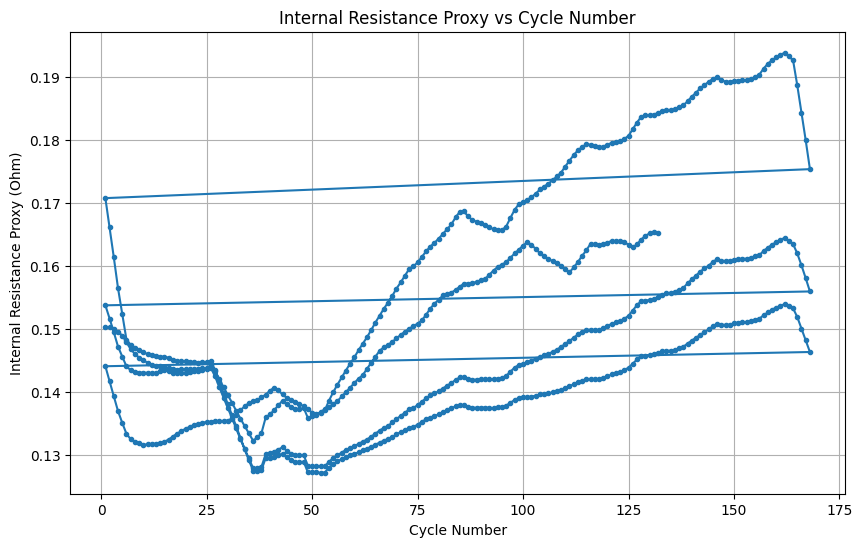

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(feature_df["cycle"], uniform_filter1d(feature_df["R_int_proxy"].values, size=10), marker="o", markersize=3, linestyle="-")
plt.title("Internal Resistance Proxy vs Cycle Number")
plt.xlabel("Cycle Number")
plt.ylabel("Internal Resistance Proxy (Ohm)")
plt.grid(True)
plt.show()

```
Formation-then-aging bathtub curve
Internal resistance drops during the first ~10–20 cycles (SEI layer stabilizing/"breaking in") then rises monotonically as real aging takes over. Additional feature engineering to provide context to models of this behaviour.
```

In [14]:
feature_df = feature_df.sort_values(["battery", "cycle"]).reset_index(drop=True)

feature_df["R_int_running_min"] = feature_df.groupby("battery")["R_int_proxy"].transform(lambda x: x.cummin())

# Aging component
feature_df["R_int_since_trough"] = feature_df["R_int_proxy"] - feature_df["R_int_running_min"]

# Trailing rolling mean
feature_df["R_int_since_trough_smooth"] = (
    feature_df.groupby("battery")["R_int_since_trough"]
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

# # exponentially weighted moving average (EWMA)
# feature_df["R_int_since_trough_ewm"] = (
#     feature_df.groupby("battery")["R_int_since_trough"]
#     .transform(lambda x: x.ewm(span=5, adjust=False).mean())
# )

# Direction of local trend
feature_df["R_int_slope_5"] = feature_df.groupby("battery")["R_int_proxy"].transform(
    lambda x: x.diff().rolling(5, min_periods=2).mean())


# Flag early formation phase
# (threshold chosen from TRAIN_BATS behavior only, not from Test)
FORMATION_CUTOFF = 15
feature_df["in_formation_phase"] = (feature_df["cycle"] <= FORMATION_CUTOFF).astype(int)
feature_df

,discharge_dur_s,voltage_mean,voltage_std,voltage_slope,voltage_at_80pct,temp_rise,R_int_proxy,energy_Wh,Q_cum_Ah,Q_temp_compensated,...,battery,cycle,capacity_Ah,rolling_mean_5,rolling_std_5,R_int_running_min,R_int_since_trough,R_int_since_trough_smooth,R_int_slope_5,in_formation_phase
0,3690.234,3.529829,0.235957,-0.000206,3.376548,14.652147,0.155626,6.608778,1.862203,1.862203,...,B0005,1,1.856487,1.856487,0.000000,0.155626,0.000000,0.000000,NaN,1
1,3672.344,3.537320,0.234765,-0.000205,3.388104,14.335646,0.151086,6.586345,1.852078,1.852078,...,B0005,2,1.846327,1.856487,0.000000,0.151086,0.000000,0.000000,NaN,1
2,3651.641,3.543737,0.227525,-0.000200,3.387797,14.084531,0.149003,6.555683,1.841049,1.841049,...,B0005,3,1.835349,1.851407,0.007184,0.149003,0.000000,0.000000,-0.003311,1
3,3631.563,3.543666,0.232744,-0.000205,3.393338,14.108068,0.148156,6.554829,1.840912,1.840912,...,B0005,4,1.835263,1.846055,0.010572,0.148156,0.000000,0.000000,-0.002490,1
4,3629.172,3.542343,0.236689,-0.000208,3.393330,14.140596,0.147958,6.552232,1.840360,1.840360,...,B0005,5,1.834646,1.843357,0.010180,0.147958,0.000000,0.000000,-0.001917,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,2777.844,3.455229,0.264114,-0.000282,3.195361,15.128331,0.164162,4.789447,1.382002,1.382002,...,B0018,128,1.362737,1.380056,0.010898,0.130785,0.033377,0.032764,0.000473,0
632,2781.125,3.461974,0.253917,-0.000270,3.190439,14.753149,0.163046,4.771233,1.375103,1.375103,...,B0018,129,1.363405,1.373906,0.010067,0.130785,0.032260,0.032969,0.000204,0
633,2760.906,3.452222,0.259242,-0.000275,3.179275,15.164103,0.165914,4.717904,1.363526,1.363526,...,B0018,130,1.351865,1.368937,0.006827,0.130785,0.035129,0.033265,0.000296,0
634,2753.250,3.447650,0.270182,-0.000291,3.193502,15.270443,0.165663,4.750723,1.374234,1.374234,...,B0018,131,1.354797,1.365272,0.010114,0.130785,0.034878,0.033711,0.000446,0


Sanity Check

In [15]:
print("feature shape")
print(feature_df.shape)

feature_df['R_int_slope_5'] = feature_df['R_int_slope_5'].fillna(0)
print("\nNulls")
nulls = feature_df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No nulls")

print("\nfeature stats")
feat_cols = [
    "discharge_dur_s","voltage_mean","voltage_std","voltage_slope",
    "voltage_at_80pct","temp_rise","R_int_proxy", "R_int_since_trough_smooth", "R_int_slope_5", "in_formation_phase",
    "energy_Wh", "Q_cum_Ah","Q_temp_compensated","dQdV_peak_height",
    "dQdV_peak_voltage","rolling_mean_5","rolling_std_5"
]

print(feature_df[feat_cols].describe().round(4))

print("\nsamples by battery")
print(feature_df.groupby("battery").size().rename("n_cycles"))

feature_df[["battery","cycle"] + feat_cols + ["capacity_Ah"]].head()
# feat_cols = feat_cols + ["Re", "Rct"]

feature shape
(636, 22)

Nulls
No nulls

feature stats
       discharge_dur_s  voltage_mean  voltage_std  voltage_slope  \
count         636.0000      636.0000     636.0000       636.0000   
mean         3116.9777        3.4986       0.2472        -0.0002   
std           242.1972        0.0475       0.0167         0.0000   
min          2742.8430        3.4039       0.2171        -0.0003   
25%          2891.9962        3.4667       0.2339        -0.0003   
50%          3084.2810        3.5025       0.2441        -0.0002   
75%          3311.8280        3.5411       0.2583        -0.0002   
max          3690.2340        3.5736       0.2922        -0.0001   

       voltage_at_80pct  temp_rise  R_int_proxy  R_int_since_trough_smooth  \
count          636.0000   636.0000     636.0000                   636.0000   
mean             3.2811    15.6235       0.1494                     0.0200   
std              0.1602     1.2328       0.0162                     0.0173   
min              2.5

,battery,cycle,discharge_dur_s,voltage_mean,voltage_std,voltage_slope,voltage_at_80pct,temp_rise,R_int_proxy,R_int_since_trough_smooth,R_int_slope_5,in_formation_phase,energy_Wh,Q_cum_Ah,Q_temp_compensated,dQdV_peak_height,dQdV_peak_voltage,rolling_mean_5,rolling_std_5,capacity_Ah
0,B0005,1,3690.234,3.529829,0.235957,-0.000206,3.376548,14.652147,0.155626,0.0,0.000000,1,6.608778,1.862203,1.862203,0.274616,3.233103,1.856487,0.000000,1.856487
1,B0005,2,3672.344,3.537320,0.234765,-0.000205,3.388104,14.335646,0.151086,0.0,0.000000,1,6.586345,1.852078,1.852078,0.268305,3.250605,1.856487,0.000000,1.846327
2,B0005,3,3651.641,3.543737,0.227525,-0.000200,3.387797,14.084531,0.149003,0.0,-0.003311,1,6.555683,1.841049,1.841049,0.320827,3.284359,1.851407,0.007184,1.835349
3,B0005,4,3631.563,3.543666,0.232744,-0.000205,3.393338,14.108068,0.148156,0.0,-0.002490,1,6.554829,1.840912,1.840912,0.303970,3.260823,1.846055,0.010572,1.835263
4,B0005,5,3629.172,3.542343,0.236689,-0.000208,3.393330,14.140596,0.147958,0.0,-0.001917,1,6.552232,1.840360,1.840360,0.270573,3.257652,1.843357,0.010180,1.834646


In [16]:
# plt.figure(figsize=(10, 6))
# plt.plot(feature_df["cycle"], feature_df["R_int_since_trough_smooth"], marker="o", markersize=3, linestyle="-")
# plt.title("Internal Resistance Proxy vs Cycle Number")
# plt.xlabel("Cycle Number")
# plt.ylabel("Internal Resistance Proxy (Ohm)")
# plt.grid(True)
# plt.show()

### Train/Test Split
The battery data on B0018 is chosen as holdout set while the other batteries serve as the training dataset.

In [17]:
# Split by battery ID

TRAIN_BATTERIES = ["B0005", "B0006", "B0007"]
TEST_BATTERY = "B0018"

train_df = feature_df[feature_df["battery"].isin(TRAIN_BATTERIES)].copy()
test_df = feature_df[feature_df["battery"] == TEST_BATTERY].copy()

X_train = train_df[feat_cols]
y_train = train_df["capacity_Ah"]
X_test = test_df[feat_cols]
y_test = test_df["capacity_Ah"]

print(f"Train : {X_train.shape[0]} cycles  "
      f"| capacity range {y_train.min():.4f}-{y_train.max():.4f} Ah")
print(f"Test  : {X_test.shape[0]} cycles  "
      f"| capacity range {y_test.min():.4f}-{y_test.max():.4f} Ah")
print(f"Features : {len(feat_cols)}")

Train : 504 cycles  | capacity range 1.1538-2.0353 Ah
Test  : 132 cycles  | capacity range 1.3411-1.8550 Ah
Features : 17


# MODEL BUILDING

## Part I: Discharge Model

### Grid Search with groupK fold to tune hyperparameters

In [18]:
# param_grid = {
#     "model__alpha": [1.0, 5.0, 10.0]
# }

# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model",  Ridge())
# ])

# gkf = GroupKFold(n_splits=3)
# groups = train_df["battery"].values

# search = GridSearchCV(estimator = pipe, param_grid = param_grid, 
#                       scoring = "neg_root_mean_squared_error", cv = gkf, refit = True, n_jobs = -1, verbose = 1)

# search.fit(X_train, y_train, groups=groups)

# print("Best parameters")
# for param, value in search.best_params_.items():
#     print(f"  {param:<30} {value}")

# print(f"\nBest CV RMSE : {-search.best_score_:.4f} Ah")

# # Evaluate best model on B0018
# y_pred_best = search.predict(X_test)
# rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
# mae_best = mean_absolute_error(y_test, y_pred_best)
# print(f"B0018 RMSE: {rmse_best:.4f} Ah")
# print(f"B0018 MAE: {mae_best:.4f} Ah")

In [19]:
# param_grid = {
#     "model__n_estimators": [100, 200, 300],
#     "model__max_depth": [5, 10, 20],
#     "model__min_samples_leaf": [2, 3, 4]
# }

# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model",  RandomForestRegressor(random_state = RANDOM_STATE,n_jobs = -1)
#     )
# ])

# gkf = GroupKFold(n_splits=3)
# groups = train_df["battery"].values

# search = GridSearchCV(estimator = pipe, param_grid = param_grid, 
#                       scoring = "neg_root_mean_squared_error", cv = gkf, refit = True, n_jobs = -1, verbose = 1)

# search.fit(X_train, y_train, groups=groups)

# print("Best parameters")
# for param, value in search.best_params_.items():
#     print(f"  {param:<30} {value}")

# print(f"\nBest CV RMSE : {-search.best_score_:.4f} Ah")

# # Evaluate best model on B0018
# y_pred_best = search.predict(X_test)
# rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
# mae_best = mean_absolute_error(y_test, y_pred_best)
# print(f"B0018 RMSE: {rmse_best:.4f} Ah")
# print(f"B0018 MAE: {mae_best:.4f} Ah")

In [20]:
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [4, 5, 6],
    "model__learning_rate": [0.05, 0.01],
    "model__subsample": [0.8, 0.6],
    "model__colsample_bytree": [0.8],
    "model__reg_alpha": [0.1],
    "model__reg_lambda": [1.0, 2.0]
}

xgb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBRegressor(random_state = RANDOM_STATE, verbosity = 0, n_jobs = -1,
    ))
])

gkf = GroupKFold(n_splits=3)
groups = train_df["battery"].values

## randomly sample 50 combinations to reduce computation
search = GridSearchCV(estimator = xgb_pipe, param_grid = param_grid, 
                            scoring = "neg_root_mean_squared_error", cv = gkf, refit = True,
                            n_jobs = -1, verbose = 1)

search.fit(X_train, y_train, groups=groups)

print("Best parameters")
for param, value in search.best_params_.items():
    print(f"  {param:<30} {value}")

print(f"\nBest CV RMSE : {-search.best_score_:.4f} Ah")

# Evaluate best model on B0018
y_pred_best = search.predict(X_test)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
mae_best = mean_absolute_error(y_test, y_pred_best)
print(f"B0018 RMSE: {rmse_best:.4f} Ah")
print(f"B0018 MAE: {mae_best:.4f} Ah")

# Check for overfitting
best_pipe = search.best_estimator_
y_pred_train = best_pipe.predict(X_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
print(f"\nTrain RMSE: {rmse_train:.4f} Ah")
print(f"Val RMSE: {-search.best_score_:.4f} Ah")
print(f"Ratio: {(-search.best_score_) / rmse_train:.1f}×  "
      f"{'no overfitting' if (-search.best_score_) / rmse_train < 10 else 'still overfitting'}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters
  model__colsample_bytree        0.8
  model__learning_rate           0.05
  model__max_depth               4
  model__n_estimators            300
  model__reg_alpha               0.1
  model__reg_lambda              1.0
  model__subsample               0.8

Best CV RMSE : 0.0328 Ah
B0018 RMSE: 0.0069 Ah
B0018 MAE: 0.0053 Ah

Train RMSE: 0.0035 Ah
Val RMSE: 0.0328 Ah
Ratio: 9.4×  no overfitting


### Initialize Models
Initialize the 3 models as a pipeline to avoid data leakage.

In [21]:
# Initialize Pipeline
pipelines = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=1.0))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(n_estimators = 200, max_depth = 10, min_samples_leaf = 2, 
                                         random_state = RANDOM_STATE,n_jobs = -1)
        )
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  XGBRegressor(n_estimators = 300, learning_rate = 0.05, max_depth = 4, subsample = 0.8, reg_alpha = 0.1,
                                reg_lambda = 1.0, colsample_bytree = 0.8, random_state = RANDOM_STATE, verbosity = 0, n_jobs = -1
        ))
    ]),
}

### Group K-Fold Validation
Train on 2 batteries with one full battery set as hold out.

In [22]:
# Group Kfold: battery type/ID as folds
# With 3 training batteries this is leave-one-battery-out CV.

groups = train_df["battery"].values
n_splits_var = int(len(groups.unique()))
gkf = GroupKFold(n_splits=n_splits_var)

cv_results = {}
print(f"Cross-validation (GroupKFold, {n_splits_var} folds)")

for name, pipe in pipelines.items():
    cv = cross_validate(
        pipe, X_train, y_train,
        cv = gkf,
        groups = groups,
        scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"],
        return_train_score = True,
        n_jobs = -1
    )
    rmse_val = -cv["test_neg_root_mean_squared_error"]
    mae_val = -cv["test_neg_mean_absolute_error"]
    rmse_train = -cv["train_neg_root_mean_squared_error"]

    cv_results[name] = {
        "cv_rmse_mean": rmse_val.mean(),
        "cv_rmse_std": rmse_val.std(),
        "cv_mae_mean": mae_val.mean(),
        "cv_train_rmse": rmse_train.mean(),
    }
    print(f"\n{name}")
    print(f"  Train RMSE (mean): {rmse_train.mean():.4f} Ah")
    print(f"  Val RMSE (mean): {rmse_val.mean():.4f} Ah  ±{rmse_val.std():.4f}")
    print(f"  Val MAE (mean): {mae_val.mean():.4f} Ah")
    gap = rmse_val.mean() - rmse_train.mean()
    print(f"  Generalisation gap (val−train RMSE): {gap:.4f} Ah")
    
    print(f"  Val RMSE by Battery:")
    print(groups.unique())
    print(rmse_val)

Cross-validation (GroupKFold, 3 folds)

Ridge
  Train RMSE (mean): 0.0028 Ah
  Val RMSE (mean): 0.0152 Ah  ±0.0087
  Val MAE (mean): 0.0124 Ah
  Generalisation gap (val−train RMSE): 0.0125 Ah
  Val RMSE by Battery:
<ArrowStringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
[0.0084469  0.0275195  0.00976238]

RandomForest
  Train RMSE (mean): 0.0023 Ah
  Val RMSE (mean): 0.0278 Ah  ±0.0179
  Val MAE (mean): 0.0207 Ah
  Generalisation gap (val−train RMSE): 0.0255 Ah
  Val RMSE by Battery:
<ArrowStringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
[0.01491248 0.05311459 0.01542465]

XGBoost
  Train RMSE (mean): 0.0037 Ah
  Val RMSE (mean): 0.0328 Ah  ±0.0255
  Val MAE (mean): 0.0245 Ah
  Generalisation gap (val−train RMSE): 0.0292 Ah
  Val RMSE by Battery:
<ArrowStringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
[0.01241042 0.06877099 0.0173351 ]


### Test on hold out set
Test the models on 4th Battery (B0018) to assess the model performance on unseen data.

In [23]:
print(f"\nHoldout evaluation on {TEST_BATTERY}")
trained = {}
holdout_results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    y_pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)

    holdout_results[name] = {
        "rmse": rmse,
        "mae": mae,
        "y_pred": y_pred
    }
    print(f"{name:>14}  RMSE: {rmse:.4f} Ah   MAE: {mae:.4f} Ah")


Holdout evaluation on B0018
         Ridge  RMSE: 0.0041 Ah   MAE: 0.0035 Ah
  RandomForest  RMSE: 0.0068 Ah   MAE: 0.0052 Ah
       XGBoost  RMSE: 0.0069 Ah   MAE: 0.0053 Ah


### Generate the metrics to analyse
For each cycle zone: early, mid and late, generate the results. Analysis at 3 zones to minimize the impact of inter-battery variance. 

In [24]:
# Cycle Level Metrics
cycles_test = test_df["cycle"].values
y_true = y_test.values

phases = {
    "Early (1-44)":(cycles_test >= 1)  & (cycles_test <= 44),
    "Mid (45-88)":(cycles_test >= 45) & (cycles_test <= 88),
    "Late (89-132)":(cycles_test >= 89) & (cycles_test <= 132)
}

# Summary
print("Holdout metrics (B0018)")
full_rows = []
for name in ["Ridge", "RandomForest", "XGBoost"]:
    y_pred = holdout_results[name]["y_pred"]
    resid  = y_true - y_pred
    full_rows.append({
        "Model": name,
        "RMSE": round(mean_squared_error(y_true, y_pred)**0.5, 4),
        "MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "R²": round(r2_score(y_true, y_pred), 5),
        "Bias(mean)": round(resid.mean(), 5),   # systematic over/under prediction
        "Resid std": round(resid.std(), 5),     # spread of errors
        "Max |err|": round(np.abs(resid).max(), 4),
    })
full_df = pd.DataFrame(full_rows).set_index("Model")
print(full_df.to_string())

# Phase Level Metrics

print("\nPhase-level RMSE and bias (B0018)")
phase_rows = []
for name in ["Ridge", "RandomForest", "XGBoost"]:
    y_pred = holdout_results[name]["y_pred"]
    row = {"Model": name}
    for label, mask in phases.items():
        resid_p = y_true[mask] - y_pred[mask]
        row[f"{label} RMSE"] = round(mean_squared_error(y_true[mask], y_pred[mask])**0.5, 4)
        row[f"{label} bias"] = round(resid_p.mean(), 4)
    phase_rows.append(row)

phase_df = pd.DataFrame(phase_rows).set_index("Model")
print(phase_df.to_string())

Holdout metrics (B0018)
                RMSE     MAE       R²  Bias(mean)  Resid std  Max |err|
Model                                                                  
Ridge         0.0041  0.0035  0.99929    -0.00244    0.00330     0.0085
RandomForest  0.0068  0.0052  0.99806    -0.00152    0.00663     0.0202
XGBoost       0.0069  0.0053  0.99800    -0.00153    0.00672     0.0241

Phase-level RMSE and bias (B0018)
              Early (1-44) RMSE  Early (1-44) bias  Mid (45-88) RMSE  Mid (45-88) bias  Late (89-132) RMSE  Late (89-132) bias
Model                                                                                                                         
Ridge                    0.0040            -0.0019            0.0045           -0.0030              0.0039             -0.0025
RandomForest             0.0050            -0.0000            0.0074           -0.0003              0.0077             -0.0042
XGBoost                  0.0071            -0.0043            0.0067     

### Model Level Comparison
Compare the RMSE and MAE of the 3 models to analyse the performance.

In [25]:
print("\nFull model comparison")
rows = []
for name in pipelines:
    rows.append({
        "Model": name,
        "CV RMSE (mean)": round(cv_results[name]["cv_rmse_mean"], 4),
        "CV RMSE (±std)": round(cv_results[name]["cv_rmse_std"],  4),
        "CV MAE": round(cv_results[name]["cv_mae_mean"], 4),
        "B0018 RMSE": round(holdout_results[name]["rmse"],4),
        "B0018 MAE": round(holdout_results[name]["mae"], 4),
    })
comparison_df = pd.DataFrame(rows).set_index("Model")
print(comparison_df.to_string())


Full model comparison
              CV RMSE (mean)  CV RMSE (±std)  CV MAE  B0018 RMSE  B0018 MAE
Model                                                                      
Ridge                 0.0152          0.0087  0.0124      0.0041     0.0035
RandomForest          0.0278          0.0179  0.0207      0.0068     0.0052
XGBoost               0.0328          0.0255  0.0245      0.0069     0.0053


### Residual Plots

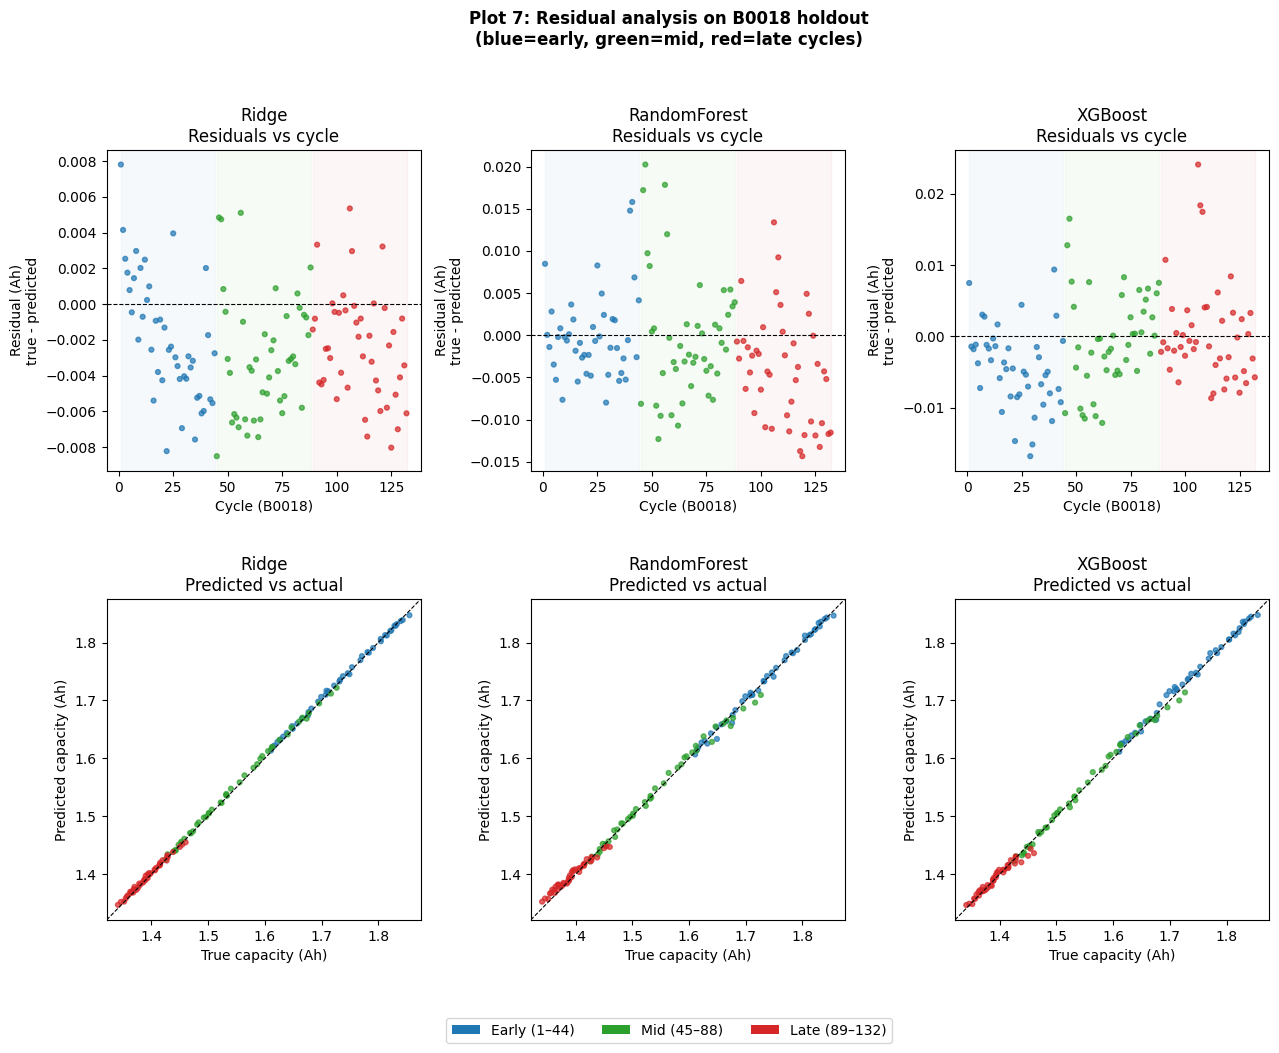

In [26]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

cycles_test = test_df["cycle"].values
y_true = y_test.values

for col, name in enumerate(pipelines):
    y_pred    = holdout_results[name]["y_pred"]
    residuals = y_true - y_pred   # positive = under-prediction

    # Top row: residuals vs cycle number
    ax_top = fig.add_subplot(gs[0, col])
    colors = np.where(cycles_test <= 44, "#1f77b4",
             np.where(cycles_test <= 88, "#2ca02c", "#d62728"))
    ax_top.scatter(cycles_test, residuals, c=colors, s=12, alpha=0.7)
    ax_top.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax_top.set_xlabel("Cycle (B0018)")
    ax_top.set_ylabel("Residual (Ah)\ntrue - predicted")
    ax_top.set_title(f"{name}\nResiduals vs cycle")
    # Phase shading
    ax_top.axvspan(1,  44,  alpha=0.04, color="#1f77b4")
    ax_top.axvspan(45, 88,  alpha=0.04, color="#2ca02c")
    ax_top.axvspan(89, 132, alpha=0.04, color="#d62728")

    # Bottom row: predicted vs actual
    ax_bot = fig.add_subplot(gs[1, col])
    ax_bot.scatter(y_true, y_pred, c=colors, s=12, alpha=0.7)
    lims = [min(y_true.min(), y_pred.min()) - 0.02,
            max(y_true.max(), y_pred.max()) + 0.02]
    ax_bot.plot(lims, lims, "k--", linewidth=0.8, label="Perfect prediction")
    ax_bot.set_xlabel("True capacity (Ah)")
    ax_bot.set_ylabel("Predicted capacity (Ah)")
    ax_bot.set_title(f"{name}\nPredicted vs actual")
    ax_bot.set_xlim(lims); ax_bot.set_ylim(lims)

# Legend for life phase colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1f77b4", label="Early (1–44)"),
    Patch(facecolor="#2ca02c", label="Mid (45–88)"),
    Patch(facecolor="#d62728", label="Late (89–132)"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Plot 7: Residual analysis on B0018 holdout\n"
             "(blue=early, green=mid, red=late cycles)",
             fontweight="bold", y=1.02)
plt.savefig("./assets/plot7_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observation:
1. Ridge over-predicts B0018 capacity in early cycles because B0018's initial capacity (1.855 Ah) is lower than the training battery mean. A model without battery-specific calibration will anchor to the training distribution. It reflects a real inter-battery difference.
2. Ensemble mid-cycle bias reveals overfit pattern matching. RF and XGBoost learned the specific shape of training battery degradation curves including their recovery bumps. When B0018's recovery pattern differs, the models mis-predict. XGB has better late cycle performance which is more important for replacement decisions.
3. All models are operationally reliable in the late-life region. Red points cluster tightly on the diagonal for all three models, the EOL region (1.34–1.45 Ah) is predicted accurately. For a real BMS application this is the region that matters most, so all three models would be deployable for end-of-life detection despite their mid-life errors.

## Part II: Charge Domain

### Build LSTM Model
To predict for future cycles utilize LSTM to predict the health factors that can be utilized by linear and XGBoost model to predict the Capacity. 

The model utilizes the existing measured true values for predicting capacities in future cycles. In deployment scenarios, the future measured values are not avaialble. Health factors of battery derived using charge cycles can be generated for future cycles using LSTM. This output is input to the downstream prediction of capacity through secondary model as described within paper by Zhao et al., 2022.  

#### Health Factors from Charge Cycle


```
Health Factor Extraction (HF1–HF6):

Each charge cycle follows a fixed CC→CV protocol: constant-current (CC) charging at 1.5 A
until the terminal voltage reaches 4.2 V, followed by constant-voltage (CV) charging at
4.2 V until the current tapers to a 20 mA cutoff. Because this protocol is identical every
cycle, landmark features extracted from the voltage/current curves are directly comparable
across cycles and across batteries, this is what makes charge-domain HFs a standardized,
protocol-driven feature set (as opposed to discharge, where load conditions vary).

Six health factors (HF1–HF6) are extracted per charge cycle, split across the CC phase,
the CV phase, and a physics-informed exponential fit to the CV current decay.

---

### HF1: CC charge time (3.9V to 4.2V)
**Extraction**: time elapsed between the voltage first crossing 3.9V and first crossing 4.2V
during the constant-current phase.
**Physical meaning**: as a cell ages, its internal resistance rises, so a larger fraction of
the applied voltage is consumed by IR drop rather than driving current into the electrodes.
This means the terminal voltage rises faster toward the 4.2V cutoff, so **HF1 decreases as
the battery ages**, less time is needed to traverse the same voltage window.

### HF2: Voltage rise in a fixed 600s window after reaching 3.9V
**Extraction**: `V(t_start + 600s) − V(t_start)`, where `t_start` is the moment the CC phase
crosses 3.9V.
**Physical meaning**: the complementary view of HF1, instead of measuring time for a fixed
voltage change, this measures voltage change for a fixed time window. As resistance rises,
voltage climbs faster per unit time, so **HF2 increases with aging**.

### HF3: Current drop in a fixed 900s window after entering CV phase
**Extraction**: `I(t_cv_start) − I(t_cv_start + 900s)`, measured once the CV phase begins
(i.e., once voltage first reaches 4.2V).
**Physical meaning**: during CV charging, current decays as the cell approaches full charge.
A more resistive, more degraded cell reaches its effective "saturation" faster under a fixed
voltage, so the current decays more sharply in the same time window. **HF3 generally
increases with aging**, though it is typically the weakest of the six HFs in terms of
correlation with capacity, since it's more sensitive to cycle-to-cycle noise in the CV
transition point.

### HF4, HF5, HF6: Exponential fit to the CV current-decay curve
The CV-phase current decay approximates the response of a first-order RC (resistor–capacitor)
equivalent circuit, which follows an exponential form:

$$
I(t) = HF4 + HF5 \cdot e^{-t / HF6}
$$

This is fit via nonlinear least squares (`scipy.optimize.curve_fit`) to the current samples
from the start of the CV phase onward, with `t` reset to zero at CV onset.

- **HF4: steady-state/floor current**: the asymptotic current level the decay approaches
  as `t tending to ∞`. Represents the residual current draw once the cell is nearly saturated.
- **HF5: decay amplitude**: the initial current excess above the floor at CV onset
  (`I(0) − HF4`). Reflects how much "distance" the current has to fall during CV charging.
- **HF6: RC time constant**: the characteristic timescale of the exponential decay —
  the time for the current to fall to `1/e` (~37%) of its initial excess above the floor.
  This directly reflects the cell's internal **RC time constant**, which grows as internal
  resistance and charge-transfer impedance increase with aging. **HF6 increases with aging**
  and, alongside HF1, is typically one of the strongest single predictors of capacity fade,
  since it maps most directly onto the same resistance-growth mechanism that EIS-derived
  Rct also captures.

### Selection for modeling
Not all six HFs are used downstream. Correlation with `capacity_Ah` (Pearson/Spearman) is
computed for each HF, and only those exceeding a chosen correlation threshold are retained
as model inputs, **HF1, HF2, HF3, and HF6** are selected, while HF4 and
HF5 (the CV floor and amplitude terms) are dropped for having weaker, less consistent
correlation with capacity across the training batteries.

```

In [27]:
def extract_hf(charge_cycle):
    d = charge_cycle["data"]

    # Charge cycles use Current_charge and Voltage_charge field names
    V = np.array(d["Voltage_measured"])
    I = np.array(d["Current_measured"])
    t = np.array(d["Time"])

    result = {k: np.nan for k in ["HF1","HF2","HF3","HF4","HF5","HF6"]}

    # HF1: time from V=3.9V to V=4.2V during CC phase
    # CC phase: current is approximately constant (~1.5A)
    idx_39 = np.where(V >= 3.9)[0]
    idx_42 = np.where(V >= 4.2)[0]

    if len(idx_39) > 0 and len(idx_42) > 0:
        t_39 = t[idx_39[0]]
        t_42 = t[idx_42[0]]
        if t_42 > t_39:
            result["HF1"] = t_42 - t_39   # seconds

    # HF2: voltage rise within 600s after reaching 3.9V
    if len(idx_39) > 0:
        t_start = t[idx_39[0]]
        mask_600 = (t >= t_start) & (t <= t_start + 600)
        if mask_600.sum() > 1:
            result["HF2"] = V[mask_600][-1] - V[mask_600][0]

    # HF3: current drop within 900s after entering CV phase
    if len(idx_42) > 0:
        cv_start_idx = idx_42[0]
        t_cv_start   = t[cv_start_idx]
        mask_900 = (t >= t_cv_start) & (t <= t_cv_start + 900)
        if mask_900.sum() > 1:
            I_cv = I[mask_900]
            result["HF3"] = I_cv[0] - I_cv[-1]   # positive = current dropped

    # HF4, HF5, HF6: exponential fit to CV current decay
    # Fit I(t) = HF4 + HF5 * exp(-t/HF6) to the full CV phase
    if len(idx_42) > 0:
        cv_start_idx = idx_42[0]
        I_cv = I[cv_start_idx:]
        t_cv = t[cv_start_idx:] - t[cv_start_idx]   # reset time to 0

        if len(t_cv) > 20 and I_cv.max() > 0.05:
            try:
                # Build bounds dynamically from actual data
                I_floor = float(np.percentile(I_cv, 2))   # near-zero floor
                I_amplitude = float(I_cv[0])
                
                # p0: [floor, amplitude, time_constant]
                p0 = [max(I_floor, 1e-4), I_amplitude * 0.95, 1000.0]
                bounds = (
                    [0.0, I_amplitude * 0.5, 10.0],  # lower
                    [I_amplitude, I_amplitude * 1.5, 20000.0]   # upper
                )

                popt, _ = curve_fit(
                    exponential_cv, t_cv, I_cv,
                    p0 = p0,
                    bounds = bounds,
                    maxfev = 10000
                )
                result["HF4"] = popt[0]
                result["HF5"] = popt[1]
                result["HF6"] = popt[2]

            except (RuntimeError, ValueError):
                pass   # fit did not converge — leave as NaN

    return result

In [28]:
all_records = []

for bat in BATTERIES:
    charge_cycles, discharge_caps = load_all_cycles(bat)

    # Charge cycle n pairs with discharge cycle n
    n_pairs = min(len(charge_cycles), len(discharge_caps))
    print(f"{bat}: {len(charge_cycles)} charge cycles, "
          f"{len(discharge_caps)} discharge cycles, "
          f"{n_pairs} paired")

    for i in range(n_pairs):
        cyc_idx = i + 1
        hf = extract_hf(charge_cycles[i])
        cap = discharge_caps.get(cyc_idx, np.nan)

        record = {
            "battery": bat,
            "cycle": cyc_idx,
            **hf,
            "capacity_Ah": cap,
            "SoH": cap / 2.0 if not np.isnan(cap) else np.nan,
        }
        all_records.append(record)

hf_df = pd.DataFrame(all_records)

print(f"\nHF table shape: {hf_df.shape}")
print(f"Columns: {hf_df.columns.tolist()}")

print("\nNull counts")
print(hf_df[["HF1","HF2","HF3","HF4","HF5","HF6"]].isnull().sum())

print("\nHF ranges")
print(hf_df[["HF1","HF2","HF3","HF4","HF5","HF6"]].describe().round(4))

print("\nRows per battery")
print(hf_df.groupby("battery").size().rename("n_cycles"))

print("\nFirst 5 rows")
hf_df.head()

B0005: 170 charge cycles, 168 discharge cycles, 168 paired
B0006: 170 charge cycles, 168 discharge cycles, 168 paired
B0007: 170 charge cycles, 168 discharge cycles, 168 paired
B0018: 134 charge cycles, 132 discharge cycles, 132 paired

HF table shape: (636, 10)
Columns: ['battery', 'cycle', 'HF1', 'HF2', 'HF3', 'HF4', 'HF5', 'HF6', 'capacity_Ah', 'SoH']

Null counts
HF1    3
HF2    0
HF3    0
HF4    4
HF5    4
HF6    4
dtype: int64

HF ranges
             HF1       HF2       HF3       HF4       HF5        HF6
count   633.0000  636.0000  636.0000  632.0000  632.0000   632.0000
mean   2087.2145    0.0798    0.7859    0.0363    1.4406  1286.6938
std     478.0655    0.2882    0.1055    0.0086    0.0416   165.5720
min       6.8590   -4.1900   -0.0619    0.0137    0.7831    30.1501
25%    1747.4070    0.0678    0.7802    0.0301    1.4159  1183.6754
50%    2133.4220    0.0892    0.8107    0.0357    1.4349  1271.8864
75%    2510.6880    0.1165    0.8400    0.0423    1.4569  1343.0034
max    2

,battery,cycle,HF1,HF2,HF3,HF4,HF5,HF6,capacity_Ah,SoH
0,B0005,1,662.391,0.189100,0.853989,0.037848,1.468529,1056.972530,1.856487,0.928244
1,B0005,2,2622.563,0.066397,0.857494,0.043963,1.510951,1041.015286,1.846327,0.923164
2,B0005,3,2606.172,0.064101,0.859360,0.041106,1.509672,1042.681913,1.835349,0.917675
3,B0005,4,2601.688,0.063632,0.863608,0.042007,1.500156,1038.592225,1.835263,0.917631
4,B0005,5,2591.812,0.063264,0.861367,0.037651,1.504565,1049.147244,1.834646,0.917323


In [29]:
# correlation between each HF and capacity_Ah.
# mine_available = False

hf_cols = ["HF1","HF2","HF3","HF4","HF5","HF6"]

print("\nCorrelation with capacity_Ah")
corr_rows = []

for hf in hf_cols:
    valid = hf_df[["capacity_Ah", hf]].dropna()
    pearson  = valid["capacity_Ah"].corr(valid[hf])
    spearman = valid["capacity_Ah"].corr(valid[hf], method="spearman")

    # mic = np.nan
    # if mine_available:
    #     m = MINE(alpha=0.6, c=15)
    #     m.compute_score(valid["capacity_Ah"].values, valid[hf].values)
    #     mic = m.mic()

    corr_rows.append({
        "HF": hf,
        "Pearson": round(pearson, 4),
        "Spearman":round(spearman, 4),
        # "MIC": round(mic, 4) if not np.isnan(mic) else "install minepy",
        # "Selected (MIC>0.8)": "Y" if (not np.isnan(mic) and mic > 0.8)
        #                       else ("?" if np.isnan(mic) else "N")
    })

corr_df = pd.DataFrame(corr_rows).set_index("HF")
print(corr_df.to_string())


Correlation with capacity_Ah
     Pearson  Spearman
HF                    
HF1   0.8602    0.9346
HF2  -0.1971   -0.9190
HF3   0.4361    0.5982
HF4  -0.1211   -0.1717
HF5  -0.0580    0.0300
HF6  -0.7526   -0.8710


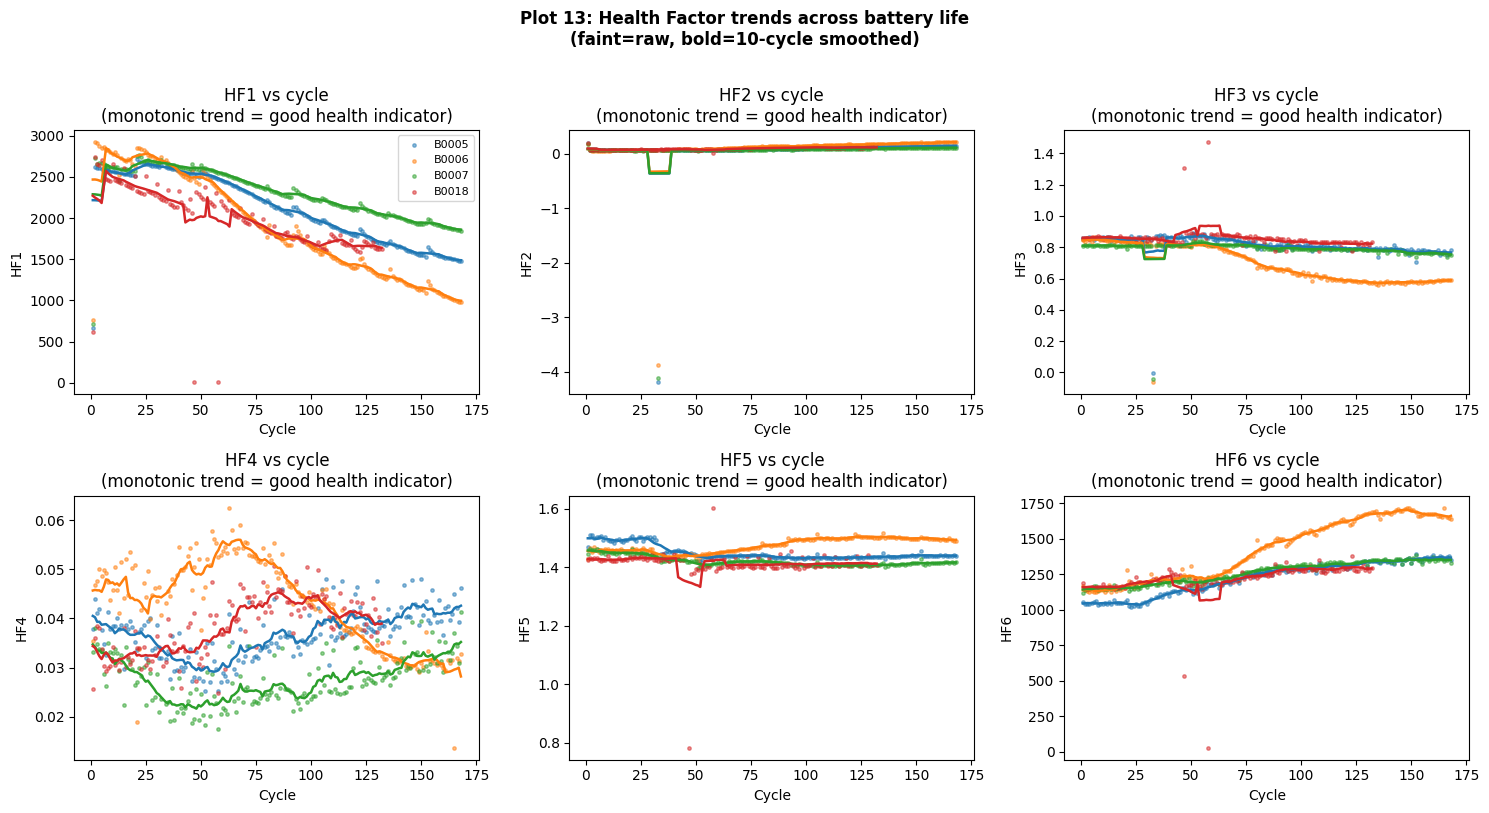

In [30]:
# HF TREND PLOTS

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

bat_colors = {"B0005":"#1f77b4","B0006":"#ff7f0e",
              "B0007":"#2ca02c","B0018":"#d62728"}

for idx, hf in enumerate(hf_cols):
    ax = axes[idx]
    for bat, color in bat_colors.items():
        sub = hf_df[hf_df["battery"] == bat].dropna(subset=[hf])
        ax.scatter(sub["cycle"], sub[hf],
                   color=color, s=6, alpha=0.5, label=bat)
        if len(sub) > 10:
            smoothed = uniform_filter1d(sub[hf].values, size=10)
            ax.plot(sub["cycle"], smoothed,
                    color=color, linewidth=1.8)
    ax.set_xlabel("Cycle")
    ax.set_ylabel(hf)
    ax.set_title(f"{hf} vs cycle\n(monotonic trend = good health indicator)")
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle("Plot 13: Health Factor trends across battery life\n"
             "(faint=raw, bold=10-cycle smoothed)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot13_hf_trends.png", dpi=150, bbox_inches="tight")
plt.show()

### Multi-Output LSTM 
Predict the 4 Health Factors as the output.

- Input: battery cycles, HF1–HF6, capacity_Ah
- selected Health factors from Pearson corrleation ["HF1","HF2","HF3","HF6"]
- Output: trained multi-output LSTM

In [31]:
RANDOM_SEED = 42
WINDOW_SIZE = 10
TRAIN_BATS = ["B0005", "B0006", "B0007"]
TEST_BAT = "B0018"
SELECTED_HFS = ["HF1", "HF2", "HF3", "HF6"]
N_HFS = len(SELECTED_HFS)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


Pre-process the Health Factors to make it viable for LSTM prediction

In [32]:
# data pre-processing
hf_clean = hf_df[["battery","cycle"] + SELECTED_HFS + ["capacity_Ah"]].copy()
hf_clean = hf_clean.sort_values(["battery","cycle"]).reset_index(drop=True)

# Clip outliers per battery (mean ± 3σ)
for bat in TRAIN_BATS + [TEST_BAT]:
    mask = hf_clean["battery"] == bat
    for hf in SELECTED_HFS:
        vals = hf_clean.loc[mask, hf].dropna()
        lo, hi = vals.mean() - 3*vals.std(), vals.mean() + 3*vals.std()
        hf_clean.loc[mask, hf] = hf_clean.loc[mask, hf].clip(lo, hi)

# Impute nulls with per-battery rolling median
for bat in TRAIN_BATS + [TEST_BAT]:
    mask = hf_clean["battery"] == bat
    for hf in SELECTED_HFS:
        s = hf_clean.loc[mask, hf]
        hf_clean.loc[mask, hf] = s.fillna(s.rolling(5, min_periods=1).median()).ffill().bfill()

print("Nulls after cleaning:", hf_clean[SELECTED_HFS].isnull().sum().sum())

# Normalizations
# Each HF gets its own scaler because they have different units and ranges.
# HF1 and HF6 are in seconds (~1000s), HF2 in volts (~0.08), HF3 in amps (~0.8)

scalers_hf = {}
train_mask = hf_clean["battery"].isin(TRAIN_BATS)
test_mask = hf_clean["battery"] == TEST_BAT

for hf in SELECTED_HFS:
    sc = StandardScaler()
    hf_clean.loc[train_mask, hf] = sc.fit_transform(
        hf_clean.loc[train_mask, hf].values.reshape(-1, 1)
    ).flatten()
    hf_clean.loc[test_mask, hf] = sc.transform(
        hf_clean.loc[test_mask, hf].values.reshape(-1, 1)
    ).flatten()
    scalers_hf[hf] = sc
    print(f"{hf}: mean={sc.mean_[0]:.4f} std={sc.scale_[0]:.4f}")

Nulls after cleaning: 0
HF1: mean=2117.8137 std=486.7969
HF2: mean=0.0951 std=0.0868
HF3: mean=0.7705 std=0.0878
HF6: mean=1304.0312 std=168.5341


### Construct LSTM Sequences

In [33]:
def build_hf_sequences(df_bat, window_size, hf_cols):
    X, y, cycles = [], [], []
    vals = df_bat[hf_cols].values
    cycs = df_bat["cycle"].values
    n = len(df_bat)

    for i in range(n - window_size):
        X.append(vals[i : i + window_size])      
        y.append(vals[i + window_size])           
        cycles.append(cycs[i + window_size])
    return (np.array(X, dtype=np.float32),np.array(y, dtype=np.float32),np.array(cycles))

# Test sequences
df_test_hf = hf_clean[hf_clean["battery"] == TEST_BAT].sort_values("cycle")
X_ts, y_ts, cyc_ts = build_hf_sequences(df_test_hf, WINDOW_SIZE, SELECTED_HFS)

print(f"\nTest: {X_ts.shape}")


Test: (122, 10, 4)


Build the LSTM Sequences\
    X shape: (n_windows, window_size, n_features)\
    y shape: (n_windows,)\
\
2-layer LSTM for next cycle prediction.\
\
Input: (batch, seq_len=10, input_size=4) window of HF values\
Output: (batch, 4) \
\
Architecture:\
  LSTM layer 1: hidden_size=32, dropout=0.3 (between layers)\
  LSTM layer 2: hidden_size=32\
  Linear layer: 32 to 4

In [34]:
class BatteryLSTM_MultiOutput(nn.Module):

    def __init__(self, input_size=4, hidden_size=32, num_layers=2, dropout=0.3, n_outputs=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout,
            batch_first = True
        )
        self.fc = nn.Linear(hidden_size, n_outputs)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])   # last timestep (batch, n_hfs)


# lstm_hf_model = BatteryLSTM_MultiOutput(
#     input_size = N_HFS,
#     hidden_size = 32,
#     num_layers = 2,
#     dropout = 0.3,
#     n_outputs = N_HFS
# ).to(device)

# total_params = sum(p.numel() for p in lstm_hf_model.parameters()
#                    if p.requires_grad)
# print(f"\nModel parameters: {total_params:,}  "
#       f"ratio to train sequences: {total_params/len(X_tr):.1f}×")

In [35]:
# Early stopping
class EarlyStopping:
    def __init__(self, patience=20):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0
        self.best_weights = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - 1e-6:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            return False   # do not stop
        else:
            self.counter += 1
            return self.counter >= self.patience 

    def restore(self, model):
        model.load_state_dict(self.best_weights)

### Train LSTM Parameters and Validate the HF forecast
Build cross-battery validation set with training done on 2 batteries while 3rd battery is used as validation in rotation. This strays away from benchmark paper which uses few cycles in every battery as part of validation. It ensures a stricter validation while also training for cross-battery predictions. 

```
Iterative tuning:
1. Reduce learning rate to reduce spikes in learning.
2. Add weight decay to Adam optimizer to quicken convergence at lower epochs.
3. Shift from MSE loss to Huber loss: drastically reduced cross-validation loss due to distribution differences.
4. Reduce epochs to minimize overfitting: lowest epoch from group cv.
5. Increase batch size to reduce batch variance.
```

Fold val=B0005: train=316 windows, val=158 windows
Fold val=B0006: train=316 windows, val=158 windows
Fold val=B0007: train=316 windows, val=158 windows


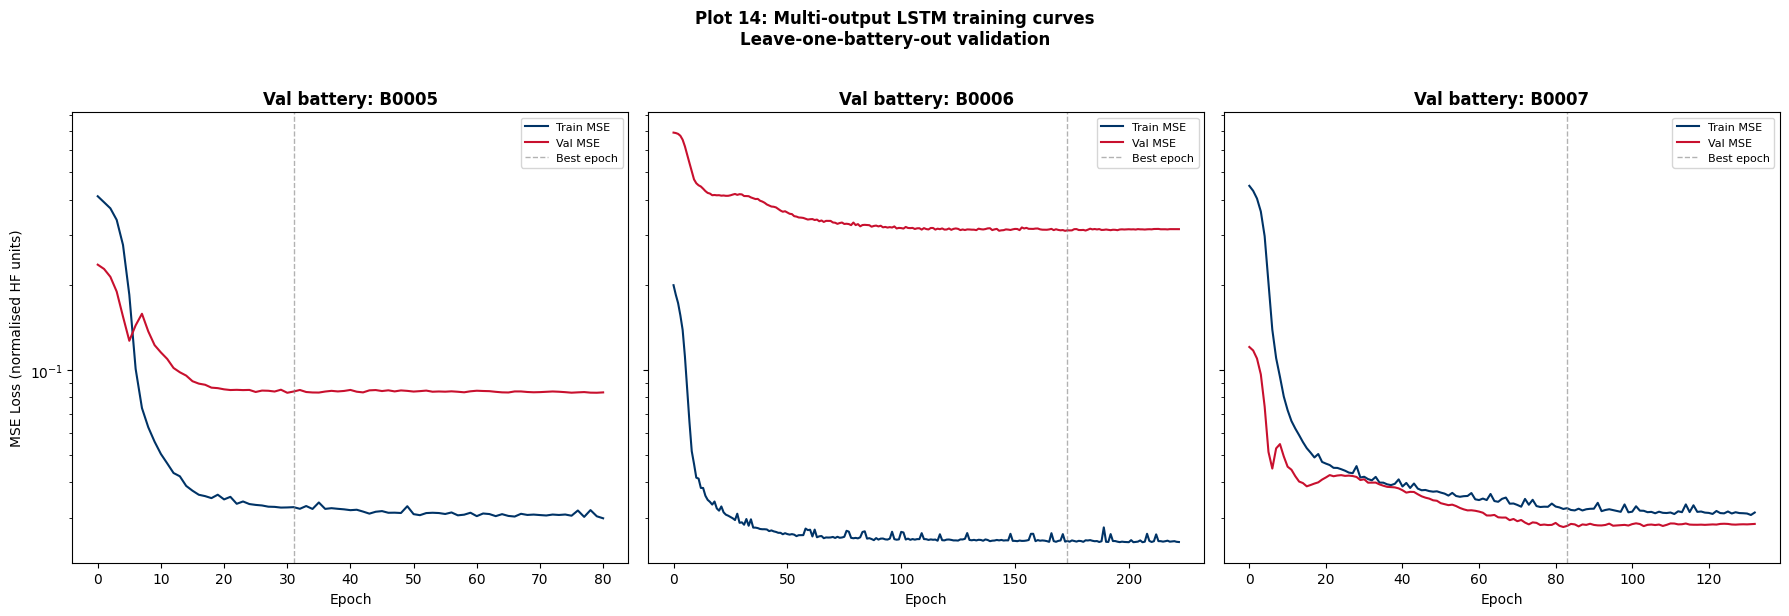


Leave-one-battery-out results:
  val_battery  best_val_loss  best_epoch
0       B0005       0.082951          81
1       B0006       0.310530         223
2       B0007       0.027780         133

Mean val loss: 0.14042 ± 0.14988
Mean best epoch: 146
Max best epoch: 223


In [36]:
# Leave-one-battery-out validation split
fold_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, VAL_BAT in zip(axes, TRAIN_BATS):
    FIT_BATS = [b for b in TRAIN_BATS if b != VAL_BAT]

    X_tr_list, y_tr_list = [], []
    for bat in FIT_BATS:
        df_bat = hf_clean[hf_clean["battery"] == bat].sort_values("cycle")
        X_b, y_b, _ = build_hf_sequences(df_bat, WINDOW_SIZE, SELECTED_HFS)
        X_tr_list.append(X_b)
        y_tr_list.append(y_b)

    X_tr_fold = np.concatenate(X_tr_list)
    y_tr_fold = np.concatenate(y_tr_list)

    df_val = hf_clean[hf_clean["battery"] == VAL_BAT].sort_values("cycle")
    X_vl_fold, y_vl_fold, cyc_vl_fold = build_hf_sequences(df_val, WINDOW_SIZE, SELECTED_HFS)

    print(f"Fold val={VAL_BAT}: train={X_tr_fold.shape[0]} windows, val={X_vl_fold.shape[0]} windows")

    # model + optimizer + early stopper
    fold_model = BatteryLSTM_MultiOutput(
        input_size=N_HFS, hidden_size=32, num_layers=2, dropout=0.3, n_outputs=N_HFS
    ).to(device)

    X_tr_t = torch.tensor(X_tr_fold, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_fold, dtype=torch.float32)
    X_vl_t = torch.tensor(X_vl_fold, dtype=torch.float32)
    y_vl_t = torch.tensor(y_vl_fold, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_vl_t, y_vl_t), batch_size=32, shuffle=False)

    # criterion = nn.MSELoss()
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.Adam(fold_model.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=15)
    early_stopper = EarlyStopping(patience=50)

    train_losses = []
    val_losses = []
    for epoch in range(1, 301):
        fold_model.train()
        batch_losses = []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(fold_model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        fold_model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                criterion(fold_model(X_v.to(device)), y_v.to(device)).item()
                for X_v, y_v in val_loader
            ])
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if early_stopper.step(val_loss, fold_model):
            break

    early_stopper.restore(fold_model)
    fold_results.append({
        "val_battery": VAL_BAT,
        "best_val_loss": early_stopper.best_loss,
        "best_epoch": epoch
    })

    ## Training curve for this fold, on its own subplot
    ax.plot(train_losses, color="#003366", linewidth=1.5, label="Train MSE")
    ax.plot(val_losses, color="#C8102E", linewidth=1.5, label="Val MSE")
    ax.axvline(epoch - early_stopper.patience, color="gray", linestyle="--",
               linewidth=1, alpha=0.6, label="Best epoch")
    ax.set_xlabel("Epoch")
    ax.set_title(f"Val battery: {VAL_BAT}", fontweight="bold")
    ax.set_yscale("log")
    ax.legend(fontsize=8)

axes[0].set_ylabel("MSE Loss (normalised HF units)")
fig.suptitle("Plot 14: Multi-output LSTM training curves\nLeave-one-battery-out validation",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./assets/plot14_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fold_df = pd.DataFrame(fold_results)
print("\nLeave-one-battery-out results:")
print(fold_df)
print(f"\nMean val loss: {fold_df['best_val_loss'].mean():.5f} ± {fold_df['best_val_loss'].std():.5f}")
print(f"Mean best epoch: {fold_df['best_epoch'].mean():.0f}")
print(f"Max best epoch: {fold_df['best_epoch'].max():.0f}")

Battery B0006 has broader capacity range relative to the training batteries, this results in large bias when used as validation. This signals distribution shift. The inclusion of battery B0006 generalizes better for cross-battery predictions and captures broader capacity range.

In [37]:
def set_full_seed(seed=RANDOM_SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = RANDOM_SEED
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(RANDOM_SEED)

MAX_EPOCHS = int(fold_df["best_epoch"].mean()) ## use mean to reduce the epochs to mitigate overfitting risk on the final model
# if MAX_EPOCHS < 110: MAX_EPOCHS = 110

X_tr_list, y_tr_list = [], []
for bat in TRAIN_BATS:
    df_bat = hf_clean[hf_clean["battery"] == bat].sort_values("cycle")
    X_b, y_b, _ = build_hf_sequences(df_bat, WINDOW_SIZE, SELECTED_HFS)
    X_tr_list.append(X_b)
    y_tr_list.append(y_b)

X_tr = np.concatenate(X_tr_list)
y_tr = np.concatenate(y_tr_list)
print(f"Final training set: {X_tr.shape[0]} windows from {TRAIN_BATS}, MAX_EPOCHS={MAX_EPOCHS}")

set_full_seed(RANDOM_SEED)
final_model = BatteryLSTM_MultiOutput(
    input_size=N_HFS, hidden_size=32, num_layers=2, dropout=0.3, n_outputs=N_HFS
).to(device)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

# train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16, shuffle=True)
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)

# criterion = nn.MSELoss()
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.0005, weight_decay=1e-4)

for epoch in range(1, MAX_EPOCHS + 1):
    final_model.train()
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer.step()

# Validation by HF
final_model.eval()
with torch.no_grad():
    y_pred_ts_norm = final_model(
        torch.tensor(X_ts, dtype=torch.float32).to(device)
    ).cpu().numpy()   # (n_windows, 4) normalised

# Inverse transform each HF independently
y_pred_ts = np.zeros_like(y_pred_ts_norm)
y_true_ts = np.zeros_like(y_ts)

for j, hf in enumerate(SELECTED_HFS):
    y_pred_ts[:, j] = scalers_hf[hf].inverse_transform(
        y_pred_ts_norm[:, j].reshape(-1, 1)
    ).flatten()
    y_true_ts[:, j] = scalers_hf[hf].inverse_transform(
        y_ts[:, j].reshape(-1, 1)
    ).flatten()

print("\nOne-step-ahead HF prediction on B0018 (true input window)")
one_step_rmse = dict()
for j, hf in enumerate(SELECTED_HFS):
    rmse = ((y_true_ts[:, j] - y_pred_ts[:, j])**2).mean()**0.5
    mae = np.abs(y_true_ts[:, j] - y_pred_ts[:, j]).mean()
    one_step_rmse[hf]=rmse
    print(f"  {hf}:  RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"(units: {'s' if hf in ['HF1','HF6'] else 'V/A'})")

Final training set: 474 windows from ['B0005', 'B0006', 'B0007'], MAX_EPOCHS=145

One-step-ahead HF prediction on B0018 (true input window)
  HF1:  RMSE=196.6709  MAE=88.6206  (units: s)
  HF2:  RMSE=0.0075  MAE=0.0046  (units: V/A)
  HF3:  RMSE=0.0391  MAE=0.0254  (units: V/A)
  HF6:  RMSE=59.9489  MAE=29.0855  (units: s)


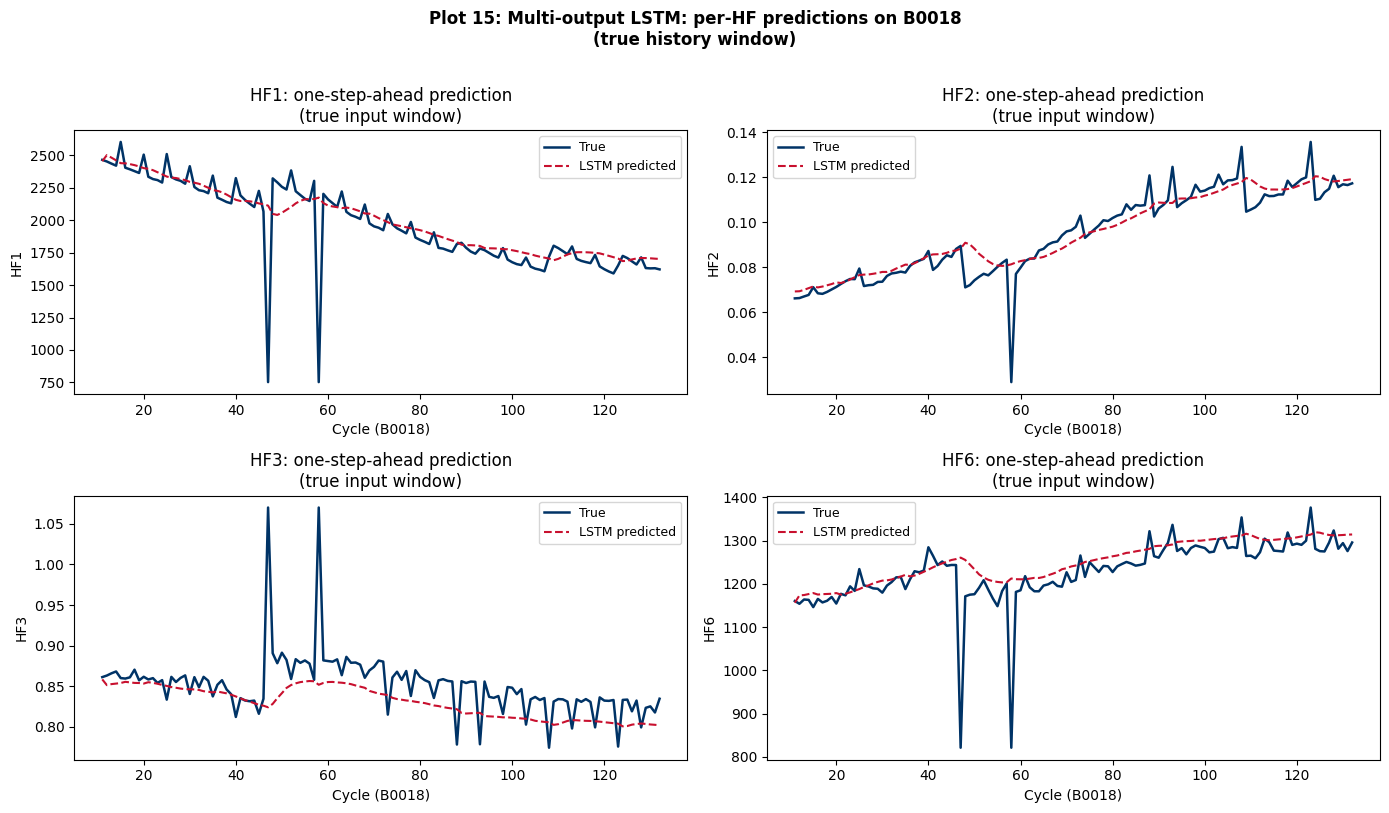

In [38]:
# Prediction Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for j, (hf, ax) in enumerate(zip(SELECTED_HFS, axes)):
    ax.plot(cyc_ts, y_true_ts[:, j],
            color="#003366", linewidth=1.8, label="True")
    ax.plot(cyc_ts, y_pred_ts[:, j],
            color="#C8102E", linewidth=1.5,
            linestyle="--", label="LSTM predicted")
    ax.set_xlabel("Cycle (B0018)")
    ax.set_ylabel(hf)
    ax.set_title(f"{hf}: one-step-ahead prediction\n"
                 f"(true input window)")
    ax.legend(fontsize=9)

plt.suptitle("Plot 15: Multi-output LSTM: per-HF predictions on B0018\n"
             "(true history window)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot15_lstm_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

Per-HF prediction analysis
- HF1: The trend is captured accurately for downward slope across B0018's life. The two sharp dips around cycles 45–60 are anomalous cycles in B0018 that were not seen in training batteries. These are likely partial charges due test stop and restart. The LSTM correctly ignores them and follows the underlying trend. For RUL purposes the trend matters more than cycle-by-cycle accuracy.
- HF2: The upward trend is captured cleanly. The sharp anomalous dip around cycle 55 is smoothed over, correct behaviour for a trend-following model.
- HF3: The trend is captured in direction but the model predicts a smooth monotonic decline while the true signal is noisy and flat after cycle 80. The LSTM learned a stronger degradation trend for HF3 than actually exists in B0018. This might introduce systematic error in XGBoost model. But, HF3 had the weakest Spearman correlation (0.598) this is unlikely to dominate the XGBoost SoH prediction.
- HF6: The trend is captured well after cycle 60. The anomalous dip at cycle 50 (same anomalous cycles as HF1) is correctly smoothed. The model slightly over-predicts HF6 in early cycles, consistent with inter-battery offset seen throughout.

### Auto-Regressive HF prediction using LSTM with sliding window of 10 cycles

In [39]:
SEED_CYCLES = WINDOW_SIZE 
df_b0018 = (hf_clean[hf_clean["battery"] == TEST_BAT].sort_values("cycle").reset_index(drop=True))

# Normalised HF matrix — shape (132, 4)
hf_vals_norm = df_b0018[SELECTED_HFS].values.astype(np.float32)
true_cycles = df_b0018["cycle"].values
true_caps = df_b0018["capacity_Ah"].values

# Seed window: first SEED_CYCLES rows (normalised)
seed_window = hf_vals_norm[:SEED_CYCLES].copy()   # (10, 4)

print(f"Seed window: cycles {true_cycles[0]}-{true_cycles[SEED_CYCLES-1]}")
print(f"Rollout predicts: cycles {true_cycles[SEED_CYCLES]}-{true_cycles[-1]}")
print(f"Total predicted cycles: {len(true_cycles) - SEED_CYCLES}")

Seed window: cycles 1-10
Rollout predicts: cycles 11-132
Total predicted cycles: 122


**Auto-Regressive prediction**

1. Pass current window (normalised) through LSTM
2. Get predicted next-cycle HFs (normalised)
3. Slide window: drop oldest cycle, append prediction
4. Store prediction

In [40]:
final_model.eval()

current_window = seed_window.copy()   # (10, 4)
predicted_norm = []                  
predicted_cycles = []

with torch.no_grad():
    for step in range(len(true_cycles) - SEED_CYCLES):
        # LSTM: (batch=1, seq_len=10, features=4)
        window_tensor = torch.tensor(current_window[np.newaxis, :, :], dtype=torch.float32).to(device)

        # Predict next cycle's HFs (normalised)
        pred_norm = final_model(window_tensor).cpu().numpy().flatten()  # (4,)

        predicted_norm.append(pred_norm)
        predicted_cycles.append(true_cycles[SEED_CYCLES + step])

        # Slide window: drop cycle 0, append prediction
        current_window = np.vstack([current_window[1:], pred_norm])

predicted_norm = np.array(predicted_norm) 
predicted_cycles = np.array(predicted_cycles)

# Inverse transform
predicted_hf = np.zeros_like(predicted_norm)
true_hf_norm = hf_vals_norm[SEED_CYCLES:]      # true values for same cycles
true_hf = np.zeros_like(true_hf_norm)

for j, hf in enumerate(SELECTED_HFS):
    predicted_hf[:, j] = scalers_hf[hf].inverse_transform(predicted_norm[:, j].reshape(-1, 1)).flatten()
    true_hf[:, j] = scalers_hf[hf].inverse_transform(true_hf_norm[:, j].reshape(-1, 1)).flatten()

In [41]:
# Metrics
print("\nRollout HF prediction metrics on B0018")
print(f"{'HF':<6} {'RMSE':>10} {'MAE':>10} {'One-step RMSE':>16} {'Degradation?'}")

# one_step_rmse = {
#     "HF1": 200.17, "HF2": 0.0078, "HF3": 0.0409, "HF6": 57.01
# }

for j, hf in enumerate(SELECTED_HFS):
    rmse = ((true_hf[:, j] - predicted_hf[:, j])**2).mean()**0.5
    mae = np.abs(true_hf[:, j] - predicted_hf[:, j]).mean()
    unit = "s" if hf in ["HF1","HF6"] else "V/A"
    degraded = "worse" if rmse > one_step_rmse[hf] * 1.5 else "ok"
    print(f"{hf:<6} {rmse:>9.4f}{unit}  {mae:>9.4f}{unit}  "
          f"{one_step_rmse[hf]:>12.4f}{unit}   {degraded}")


Rollout HF prediction metrics on B0018
HF           RMSE        MAE    One-step RMSE Degradation?
HF1     194.4372s    94.1719s      196.6709s   ok
HF2       0.0108V/A     0.0076V/A        0.0075V/A   ok
HF3       0.0644V/A     0.0517V/A        0.0391V/A   worse
HF6      90.6097s    65.1945s       59.9489s   worse



Rollout error by prediction horizon
Early horizon (cycles 1–40): HF1 RMSE=239.7s  HF6 RMSE=81.8s
Mid horizon (cycles 41–80): HF1 RMSE=226.6s  HF6 RMSE=123.0s
Late horizon (cycles 81–122): HF1 RMSE=71.4s  HF6 RMSE=52.8s


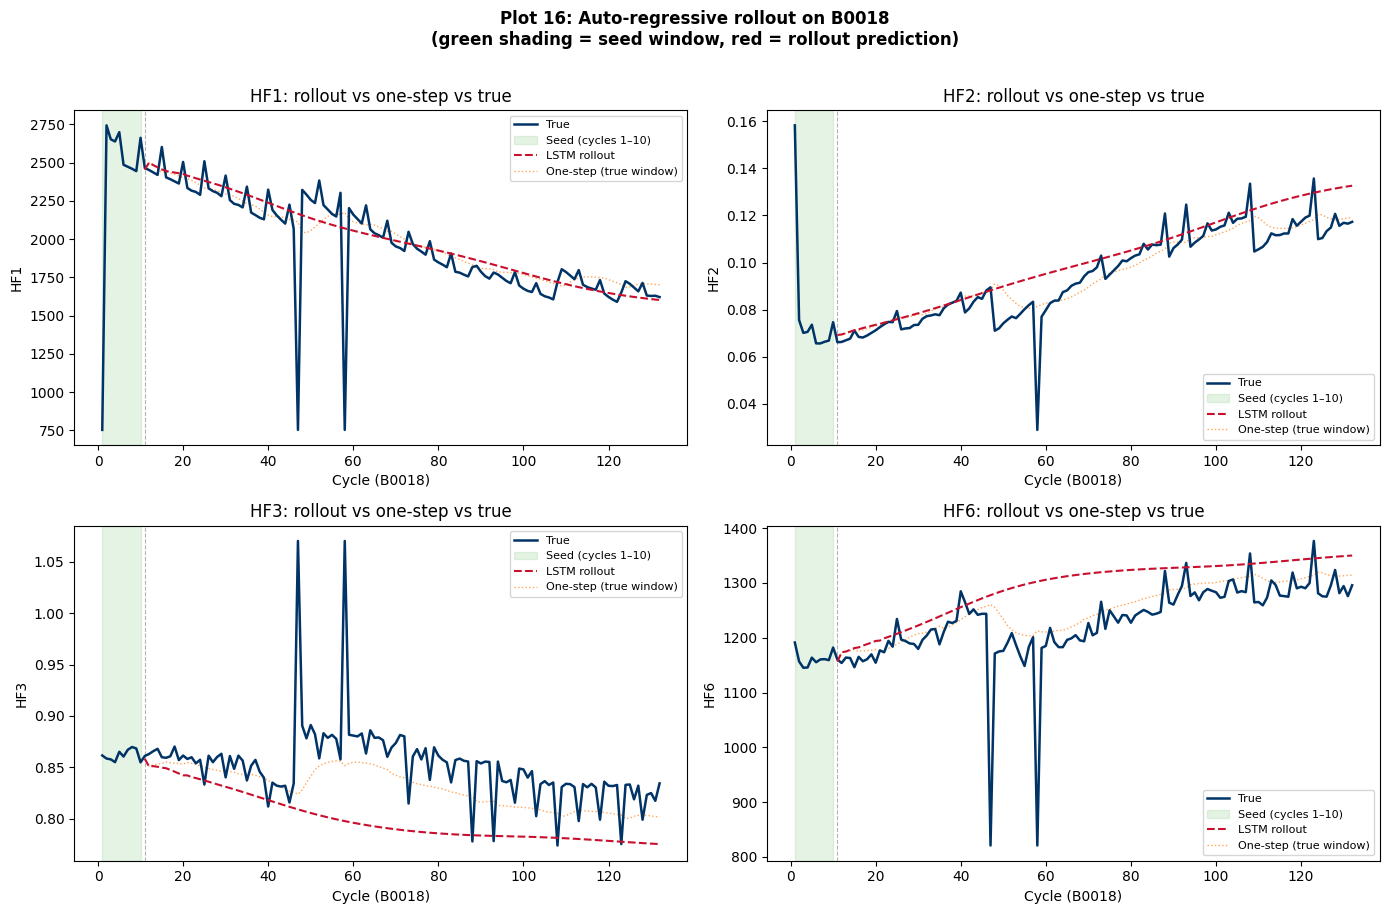

In [42]:
# Compounding Error Analysis 
print("\nRollout error by prediction horizon")
n_roll = len(predicted_cycles)
thirds = [
    ("Early horizon (cycles 1–40)", 0, n_roll//3),
    ("Mid horizon (cycles 41–80)", n_roll//3, 2*n_roll//3),
    ("Late horizon (cycles 81–122)", 2*n_roll//3, n_roll),
]
for label, lo, hi in thirds:
    hf1_rmse = ((true_hf[lo:hi,0] - predicted_hf[lo:hi,0])**2).mean()**0.5
    hf6_rmse = ((true_hf[lo:hi,3] - predicted_hf[lo:hi,3])**2).mean()**0.5
    print(f"{label}: HF1 RMSE={hf1_rmse:.1f}s  HF6 RMSE={hf6_rmse:.1f}s")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

# True values for all cycles (seed + rollout) for reference
all_true_hf = np.zeros((len(true_cycles), N_HFS))
for j, hf in enumerate(SELECTED_HFS):
    all_true_hf[:, j] = scalers_hf[hf].inverse_transform(
        hf_vals_norm[:, j].reshape(-1, 1)
    ).flatten()

for j, (hf, ax) in enumerate(zip(SELECTED_HFS, axes)):
    # Full true trajectory
    ax.plot(true_cycles, all_true_hf[:, j],
            color="#003366", linewidth=1.8, label="True", zorder=3)

    # Seed region shading
    ax.axvspan(true_cycles[0], true_cycles[SEED_CYCLES-1],
               alpha=0.12, color="#2ca02c", label=f"Seed (cycles 1–{SEED_CYCLES})")

    # Rollout prediction
    ax.plot(predicted_cycles, predicted_hf[:, j],
            color="#C8102E", linewidth=1.5,
            linestyle="--", label="LSTM rollout", zorder=4)

    # One-step prediction for comparison
    ax.plot(cyc_ts, y_pred_ts[:, j],
            color="#ff7f0e", linewidth=1.0,
            linestyle=":", alpha=0.7, label="One-step (true window)")

    ax.axvline(true_cycles[SEED_CYCLES], color="gray",
               linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("Cycle (B0018)")
    ax.set_ylabel(hf)
    ax.set_title(f"{hf}: rollout vs one-step vs true")
    ax.legend(fontsize=8)

plt.suptitle("Plot 16: Auto-regressive rollout on B0018\n"
             "(green shading = seed window, red = rollout prediction)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot16_hf_sliding.png", dpi=150, bbox_inches="tight")
plt.show()


In [43]:
# prep HF for input to XGB
rollout_df = pd.DataFrame(
    predicted_hf,
    columns=SELECTED_HFS
)
rollout_df.insert(0, "cycle", predicted_cycles)
rollout_df.insert(1, "battery", TEST_BAT)
rollout_df["capacity_Ah_true"] = true_caps[SEED_CYCLES:]

# Also store seed cycles with true HFs for completeness
seed_df = pd.DataFrame(
    all_true_hf[:SEED_CYCLES],
    columns=SELECTED_HFS
)
seed_df.insert(0, "cycle", true_cycles[:SEED_CYCLES])
seed_df.insert(1, "battery", TEST_BAT)
seed_df["capacity_Ah_true"] = true_caps[:SEED_CYCLES]
seed_df["source"] = "seed_true"
rollout_df["source"] = "lstm_rollout"

full_b0018_df = pd.concat([seed_df, rollout_df], ignore_index=True)

print(f"\nRollout DataFrame")
print(f"Shape: {rollout_df.shape}")
print(f"Cycles: {rollout_df['cycle'].min()}–{rollout_df['cycle'].max()}")
print(f"\nFirst 3 rows (predicted HFs):")
print(rollout_df[["cycle"] + SELECTED_HFS + ["capacity_Ah_true"]]
      .head(3).round(4).to_string(index=False))
print(f"\nLast 3 rows:")
print(rollout_df[["cycle"] + SELECTED_HFS + ["capacity_Ah_true"]]
      .tail(3).round(4).to_string(index=False))


Rollout DataFrame
Shape: (122, 8)
Cycles: 11–132

First 3 rows (predicted HFs):
 cycle         HF1    HF2    HF3         HF6  capacity_Ah_true
    11 2454.133301 0.0693 0.8583 1156.412109            1.8121
    12 2499.796387 0.0695 0.8508 1173.404541            1.8047
    13 2483.583740 0.0700 0.8511 1174.912720            1.7908

Last 3 rows:
 cycle         HF1    HF2    HF3         HF6  capacity_Ah_true
   130 1607.708252 0.1321 0.7758 1349.018311            1.3519
   131 1604.577393 0.1324 0.7755 1349.564819            1.3548
   132 1601.578979 0.1326 0.7753 1350.095581            1.3411


**Analysis:**\
Rollout predictions simulate real deployment where future HF values are unavailable and results show error propagation across the prediction horizon, consistent with literature on auto-regressive sequence forecasting on small battery datasets. One-step predictions are used to demonstrate feature attributions reflect genuine model behaviour and errors due to propagation does not skew the explainability of physics informed features.

### Rebuild Ridge and XGBoost model
Utilize the predicted HF from LSTM to predict the SOH.

```
XGBoost on HF Features + SHAP
Inputs: hf_clean: normalised HF table, 
        y_pred_ts: one-step predicted HFs
```

Build Training and Test Data

In [44]:
hf_train_df = hf_df[hf_df["battery"].isin(TRAIN_BATS)][
    ["battery","cycle"] + SELECTED_HFS + ["capacity_Ah"]
].copy().dropna(subset=SELECTED_HFS)

# outlier clipping: 3 sigma per battery
for bat in TRAIN_BATS:
    mask = hf_train_df["battery"] == bat
    for hf in SELECTED_HFS:
        vals = hf_train_df.loc[mask, hf].dropna()
        lo = vals.mean()-3*vals.std()
        hi = vals.mean()+3*vals.std()
        hf_train_df.loc[mask, hf] = hf_train_df.loc[mask, hf].clip(lo, hi)

# Impute nulls
for bat in TRAIN_BATS:
    mask = hf_train_df["battery"] == bat
    for hf in SELECTED_HFS:
        s = hf_train_df.loc[mask, hf]
        hf_train_df.loc[mask, hf] = s.fillna(s.rolling(5, min_periods=1).median()).ffill().bfill()

# ## Add temporal features
# hf_train_df["HF1_delta"] = (
#     hf_train_df.groupby("battery")["HF1"]
#     .transform(lambda x: x.diff().fillna(0))
# )
# hf_train_df["HF6_delta"] = (
#     hf_train_df.groupby("battery")["HF6"]
#     .transform(lambda x: x.diff().fillna(0))
# )

hf_train_df["HF1_rolling_mean5"] = (
    hf_train_df.groupby("battery")["HF1"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
hf_train_df["HF6_rolling_mean5"] = (
    hf_train_df.groupby("battery")["HF6"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

FEATURES_MAP = ["HF1","HF2","HF3","HF6","HF1_rolling_mean5","HF6_rolling_mean5"]
# FEATURES_MAP = ["HF1","HF2","HF3","HF6"]

X_hf_train = hf_train_df[FEATURES_MAP].values
y_hf_train = hf_train_df["capacity_Ah"].values
groups = hf_train_df["battery"].values

print(f"HF training table: {X_hf_train.shape}")
print(f"Capacity range: {y_hf_train.min():.4f} to {y_hf_train.max():.4f} Ah")

HF training table: (501, 6)
Capacity range: 1.1538 to 2.0353 Ah


In [45]:
X_hf_test_norm = predicted_norm #y_pred_ts_norm
X_hf_test = np.zeros_like(X_hf_test_norm)

for j, hf in enumerate(SELECTED_HFS):
    X_hf_test[:, j] = scalers_hf[hf].inverse_transform(
        X_hf_test_norm[:, j].reshape(-1,1)
    ).flatten()

X_hf_test_tempdf = pd.DataFrame(X_hf_test)
X_hf_test_tempdf.columns = SELECTED_HFS
# X_hf_test_tempdf['cycle'] = cyc_ts
# X_hf_test_tempdf["HF1_delta"] = (
#     X_hf_test_tempdf["HF1"]
#     .transform(lambda x: x.diff().fillna(0))
# )
# X_hf_test_tempdf["HF6_delta"] = (
#     X_hf_test_tempdf["HF6"]
#     .transform(lambda x: x.diff().fillna(0))
# )
X_hf_test_tempdf["HF1_rolling_mean5"] = (
    X_hf_test_tempdf["HF1"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
X_hf_test_tempdf["HF6_rolling_mean5"] = (
    X_hf_test_tempdf["HF6"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

X_hf_test_tempdf = X_hf_test_tempdf.ffill().bfill()
X_hf_test = X_hf_test_tempdf.values

# True capacity for test cycles 
df_b0018_full = hf_df[hf_df["battery"] == TEST_BAT].sort_values("cycle")
cap_lookup = df_b0018_full.set_index("cycle")["capacity_Ah"].to_dict()
y_hf_test = np.array([cap_lookup.get(c, np.nan) for c in cyc_ts])

print(f"\nHF test table (predicted HFs): {X_hf_test.shape}")
print(f"Test capacity range: {np.nanmin(y_hf_test):.4f} to "
      f"{np.nanmax(y_hf_test):.4f} Ah")


HF test table (predicted HFs): (122, 6)
Test capacity range: 1.3411 to 1.8121 Ah


In [46]:
# GroupKFold by battery

xgb_hf = XGBRegressor(n_estimators = 100, learning_rate = 0.05, max_depth = 3, 
                      subsample = 0.8, min_child_weight = 5, reg_alpha = 0.1, 
            reg_lambda = 1.0, colsample_bytree = 0.8, random_state = RANDOM_STATE, verbosity = 0, n_jobs = -1
        )

gkf = GroupKFold(n_splits=3)
cv  = cross_validate(
    xgb_hf, X_hf_train, y_hf_train,
    cv = gkf,
    groups = groups,
    scoring = ["neg_root_mean_squared_error","neg_mean_absolute_error"],
    return_train_score = True,
)

cv_rmse = -cv["test_neg_root_mean_squared_error"]
print(f"\nCross-validation (GroupKFold, 3 folds)")
print(f"Val RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} Ah")
print(f"Val RMSE per battery: {cv_rmse.round(4)}")


Cross-validation (GroupKFold, 3 folds)
Val RMSE: 0.0802 ± 0.0283 Ah
Val RMSE per battery: [0.0407 0.0945 0.1055]


In [47]:
xgb_hf.fit(X_hf_train, y_hf_train)

y_pred_soh = xgb_hf.predict(X_hf_test)

# Remove any NaN rows
valid_mask = ~np.isnan(y_hf_test)
rmse_hf = mean_squared_error(y_hf_test[valid_mask], y_pred_soh[valid_mask])**0.5
mae_hf = mean_absolute_error(y_hf_test[valid_mask], y_pred_soh[valid_mask])

# Train RMSE
y_pred_train = xgb_hf.predict(X_hf_train)
rmse_train = mean_squared_error(y_hf_train, y_pred_train)**0.5
ratio = rmse_hf / rmse_train

print(f"\nXGBoost HF model: B0018 evaluation")
print(f"Train RMSE: {rmse_train:.4f} Ah")
print(f"B0018 RMSE: {rmse_hf:.4f} Ah")
print(f"B0018 MAE: {mae_hf:.4f} Ah")
print(f"Test/Train ratio: {ratio:.1f}")


XGBoost HF model: B0018 evaluation
Train RMSE: 0.0226 Ah
B0018 RMSE: 0.0594 Ah
B0018 MAE: 0.0477 Ah
Test/Train ratio: 2.6


In [48]:
# Model Comparison Table
print(f"\ncomparison")
print(f"{'Model':<35} {'B0018 RMSE':>12} {'MAE':>10} {'Domain'}")
rows = [
    ("Ridge: discharge features", "0.0051", "0.0045", "Discharge"),
    ("XGBoost: discharge features", "0.0069", "0.0057", "Discharge"),
    ("Paper GPR+LSTM (within-battery)", "0.0150", "0.0100", "Charge HFs"),
    (f"XGBoost: predicted HFs",
     f"{rmse_hf:.4f}", f"{mae_hf:.4f}", "Charge HFs"),
]
for name, rmse, mae, domain in rows:
    print(f"{name:<33} {rmse:>10} Ah  {mae:>8} Ah  {domain}")


comparison
Model                                 B0018 RMSE        MAE Domain
Ridge: discharge features             0.0051 Ah    0.0045 Ah  Discharge
XGBoost: discharge features           0.0069 Ah    0.0057 Ah  Discharge
Paper GPR+LSTM (within-battery)       0.0150 Ah    0.0100 Ah  Charge HFs
XGBoost: predicted HFs                0.0594 Ah    0.0477 Ah  Charge HFs


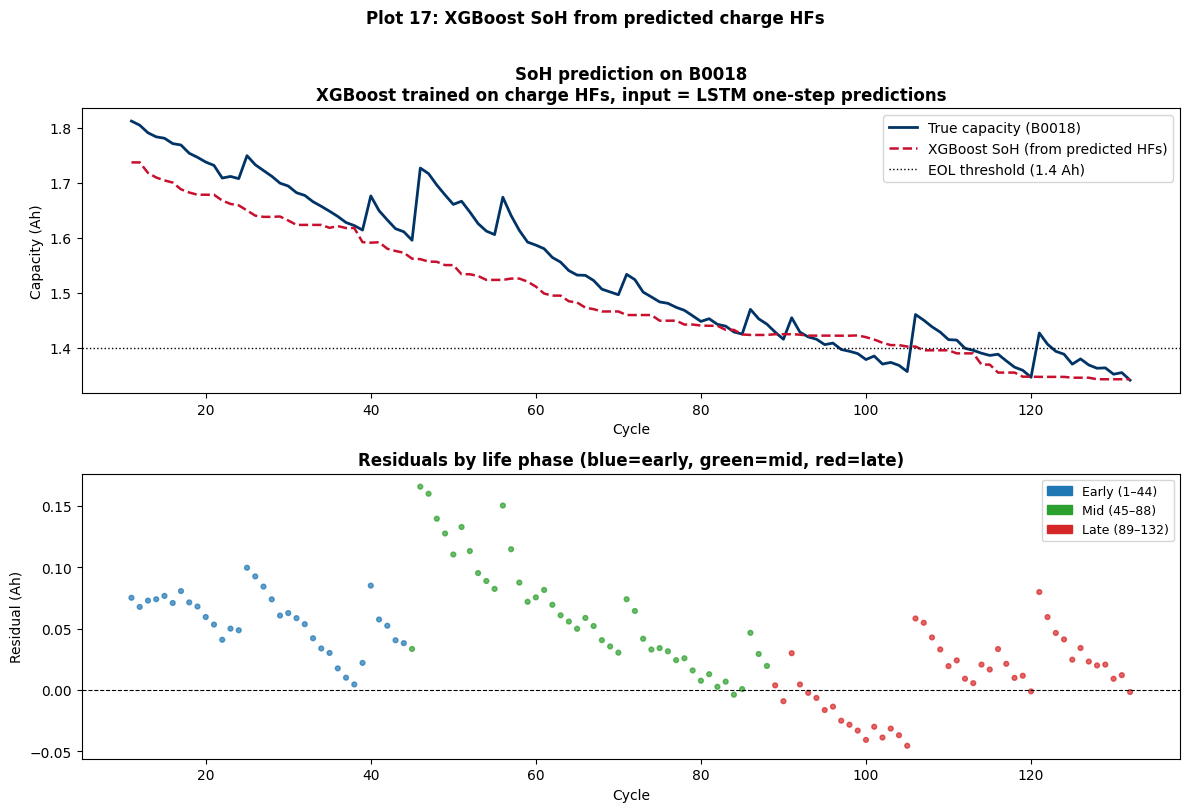

In [49]:
# Prediction Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.plot(cyc_ts[valid_mask], y_hf_test[valid_mask],
        color="#003366", linewidth=2.0, label="True capacity (B0018)")
ax.plot(cyc_ts[valid_mask], y_pred_soh[valid_mask],
        color="#C8102E", linewidth=1.8, linestyle="--",
        label="XGBoost SoH (from predicted HFs)")
ax.axhline(1.4, color="black", linestyle=":",
           linewidth=1.0, label="EOL threshold (1.4 Ah)")
ax.set_xlabel("Cycle"); ax.set_ylabel("Capacity (Ah)")
ax.set_title("SoH prediction on B0018\n"
             "XGBoost trained on charge HFs, input = LSTM one-step predictions",
             fontweight="bold")
ax.legend()

ax = axes[1]
residuals = y_hf_test[valid_mask] - y_pred_soh[valid_mask]
cyc_valid = cyc_ts[valid_mask]
colors    = np.where(cyc_valid <= 44,  "#1f77b4",
            np.where(cyc_valid <= 88,  "#2ca02c", "#d62728"))
ax.scatter(cyc_valid, residuals, c=colors, s=12, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Cycle"); ax.set_ylabel("Residual (Ah)")
ax.set_title("Residuals by life phase (blue=early, green=mid, red=late)",
             fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#1f77b4", label="Early (1–44)"),
    Patch(color="#2ca02c", label="Mid (45–88)"),
    Patch(color="#d62728", label="Late (89–132)"),
], fontsize=9)

plt.suptitle("Plot 17: XGBoost SoH from predicted charge HFs",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot17_soh.png", dpi=150, bbox_inches="tight")
plt.show()

### Post-hoc Caliberation of XGBoost SoH predictions

XGBoost predictions exhibit systematic positive bias on B0018 (mean residual = +0.085 Ah), attributable to inter-battery capacity offset. A post-hoc calibration correction was applied using the mean training residual as an additive offset. This is equivalent to predicting the (1−α) quantile of the predictive distribution rather than the mean.

In [50]:
valid_mask = ~np.isnan(y_hf_test)
y_true_valid = y_hf_test[valid_mask]
y_pred_valid = y_pred_soh[valid_mask]
cyc_valid_b3 = cyc_ts[valid_mask]

# bias in distribution
residuals_raw = y_true_valid - y_pred_valid
print("Raw prediction bias")
print(f"Mean residual: {residuals_raw.mean():.4f} Ah  "
      f"(positive = systematic under-prediction)")
print(f"Std residual: {residuals_raw.std():.4f} Ah")
print(f"Min residual: {residuals_raw.min():.4f} Ah")
print(f"Max residual: {residuals_raw.max():.4f} Ah")
print(f"% positive: {(residuals_raw > 0).mean()*100:.1f}%")

Raw prediction bias
Mean residual: 0.0417 Ah  (positive = systematic under-prediction)
Std residual: 0.0423 Ah
Min residual: -0.0455 Ah
Max residual: 0.1656 Ah
% positive: 86.1%


In [51]:
# Compute training residuals for calibration

# groups_tr = train_eis["battery"].values if False else groups  # use discharge groups
gkf = GroupKFold(n_splits=3)
oof_preds = np.zeros(len(X_hf_train))

# OOF predictions
xgb_cal = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)

for train_idx, val_idx in gkf.split(X_hf_train, y_hf_train, groups=groups):
    xgb_cal.fit(X_hf_train[train_idx], y_hf_train[train_idx])
    oof_preds[val_idx] = xgb_cal.predict(X_hf_train[val_idx])

oof_residuals = y_hf_train - oof_preds

print(f"\nOOF training residuals")
print(f"Mean: {oof_residuals.mean():.4f} Ah")
print(f"Std: {oof_residuals.std():.4f} Ah")


OOF training residuals
Mean: -0.0136 Ah
Std: 0.0840 Ah


Caliberation Strategies: Mean shift, Quantile shift 75th and 90th

In [52]:
# Strategy 1: Mean shift
offset_mean = oof_residuals.mean()
y_pred_mean_shift = y_pred_valid + offset_mean

# Strategy 2: Quantile shift: 75th percentile of OOF residuals
# Targets upper portion of predictive distribution
offset_q75 = np.percentile(oof_residuals, 75)
y_pred_q75 = y_pred_valid + offset_q75

# Strategy 3: Quantile shift: 90th percentile
offset_q90 = np.percentile(oof_residuals, 90)
y_pred_q90  = y_pred_valid + offset_q90

print(f"\nCalibration offsets")
print(f"Mean shift: {offset_mean:.4f} Ah")
print(f"Q75 shift: {offset_q75:.4f} Ah")
print(f"Q90 shift: {offset_q90:.4f} Ah")

# Evaluate
strategies = {
    "Raw (no calibration)": y_pred_valid,
    "Mean shift": y_pred_mean_shift,
    "Q75 shift": y_pred_q75,
    "Q90 shift": y_pred_q90,
}

print(f"\nCalibration comparison on B0018")
print(f"{'Strategy':<25} {'RMSE':>10} {'MAE':>10} {'Bias':>10} {'% positive':>12}")

best_rmse = np.inf
best_strategy = None
results_cal = {}

for name, y_pred_cal in strategies.items():
    rmse = mean_squared_error(y_true_valid, y_pred_cal)**0.5
    mae = mean_absolute_error(y_true_valid, y_pred_cal)
    bias = (y_true_valid - y_pred_cal).mean()
    pct_pos = ((y_true_valid - y_pred_cal) > 0).mean() * 100
    print(f"  {name:<23} {rmse:>9.4f} Ah {mae:>9.4f} Ah "
          f"{bias:>9.4f} Ah  {pct_pos:>9.1f}%")
    results_cal[name] = {"rmse": rmse, "mae": mae,
                          "bias": bias, "pred": y_pred_cal}
    if rmse < best_rmse:
        best_rmse = rmse
        best_strategy = name

print(f"\n Best strategy from OOF residuals:Q75 Retrospective Best strategy : {best_strategy}  (RMSE={best_rmse:.4f} Ah)")


Calibration offsets
Mean shift: -0.0136 Ah
Q75 shift: 0.0514 Ah
Q90 shift: 0.0816 Ah

Calibration comparison on B0018
Strategy                        RMSE        MAE       Bias   % positive
  Raw (no calibration)       0.0594 Ah    0.0477 Ah    0.0417 Ah       86.1%
  Mean shift                 0.0696 Ah    0.0584 Ah    0.0553 Ah       91.8%
  Q75 shift                  0.0434 Ah    0.0346 Ah   -0.0097 Ah       40.2%
  Q90 shift                  0.0582 Ah    0.0488 Ah   -0.0399 Ah       13.9%

 Best strategy from OOF residuals:Q75 Retrospective Best strategy : Q75 shift  (RMSE=0.0434 Ah)


In [53]:
# Quantile regression
results_quantile = {}
best_rmse_q = np.inf
for alpha in [0.5, 0.75, 0.90]:
    xgb_q = XGBRegressor(
        objective = "reg:quantileerror",
        quantile_alpha = alpha,
        n_estimators = 100,
        learning_rate = 0.05,
        max_depth = 3,
        subsample = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        reg_alpha = 0.1,
        reg_lambda = 1.0,
        random_state = RANDOM_STATE,
        verbosity = 0,
    )
    xgb_q.fit(X_hf_train, y_hf_train)
    y_pred_q = xgb_q.predict(X_hf_test[valid_mask]
                              if valid_mask.all()
                              else X_hf_test)[:len(y_true_valid)]

    rmse = mean_squared_error(y_true_valid, y_pred_q)**0.5
    mae = mean_absolute_error(y_true_valid, y_pred_q)
    bias = (y_true_valid - y_pred_q).mean()

    if rmse < best_rmse_q:
        best_rmse_q = rmse
        best_strategy_q = y_pred_q
        best_alpha_q = alpha

    results_quantile[alpha] = {
        "rmse": rmse, "mae": mae, "bias": bias, "pred": y_pred_q
    }
    print(f"  Q{int(alpha*100):>2}  RMSE={rmse:.4f} Ah  "
          f"MAE={mae:.4f} Ah  bias={bias:.4f} Ah")

results_cal['XGB_qr_75'] = {'rmse':0.0576,'bias':0.0229,"pred":best_strategy_q}

  Q50  RMSE=0.0650 Ah  MAE=0.0515 Ah  bias=0.0474 Ah
  Q75  RMSE=0.0576 Ah  MAE=0.0462 Ah  bias=0.0229 Ah
  Q90  RMSE=0.0847 Ah  MAE=0.0698 Ah  bias=-0.0353 Ah


In [54]:
# # # Prediction Plots
# # fig, ax = plt.subplots(figsize=(12, 8))

# # ax.plot(cyc_ts[valid_mask], y_hf_test[valid_mask],
# #         color="#003366", linewidth=2.0, label="True capacity (B0018)")
# # ax.plot(cyc_ts[valid_mask], best_strategy[valid_mask],
# #         color="#C8102E", linewidth=1.8, linestyle="--",
# #         label="XGBoost SoH (from predicted HFs)")
# # ax.axhline(1.4, color="black", linestyle=":",
# #            linewidth=1.0, label="EOL threshold (1.4 Ah)")
# # ax.set_xlabel("Cycle"); ax.set_ylabel("Capacity (Ah)")
# # ax.set_title("SoH prediction on B0018\n"
# #              "XGBoost trained on charge HFs, input = LSTM one-step predictions\n"
# #              "ALPHA = {:.2f} (best quantile)".format(best_alpha),
# #              fontweight="bold")
# # ax.legend()

# # plt.suptitle("Plot 28: XGBoost SoH from predicted charge HFs",
# #              fontweight="bold", y=1.01)
# # plt.tight_layout()
# # plt.savefig("./assets/plot28_XGB_best_quantile_reg.png", dpi=150, bbox_inches="tight")
# # plt.show()

# # Plot
# fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# # Top: capacity trajectories
# ax = axes[0]
# ax.plot(cyc_valid_b3, y_true_valid,
#         color="#003366", linewidth=2.0, label="True capacity", zorder=5)

# line_styles = {
#     "Raw (no calibration)": ("--", "#999999", 1.2),
#     "Mean shift": ("--", "#C8102E", 1.8),
#     "Q75 shift": ("-.", "#ff7f0e", 1.8),
#     "Q90 shift": (":", "#2ca02c", 1.8),
#     "XGB_qr_75": (":", "#21abde", 1.8)
# }
# for name, style in line_styles.items():
#     ls, color, lw = style
#     rmse = results_cal[name]["rmse"]
#     ax.plot(cyc_valid_b3, results_cal[name]["pred"],
#             linestyle=ls, color=color, linewidth=lw,
#             label=f"{name} (RMSE={rmse:.4f} Ah)")

# ax.axhline(1.4, color="black", linestyle=":", linewidth=1.0,
#            label="EOL threshold")
# ax.set_xlabel("Cycle (B0018)")
# ax.set_ylabel("Capacity (Ah)")
# ax.set_title("XGBoost-HF SoH: raw vs calibrated predictions\n"
#              "(all strategies applied post-hoc from OOF training residuals)",
#              fontweight="bold")
# ax.legend(fontsize=9)

# # Bottom: residuals for each strategy
# ax = axes[1]
# for name, style in line_styles.items():
#     ls, color, lw = style
#     resid = y_true_valid - results_cal[name]["pred"]
#     ax.plot(cyc_valid_b3, resid,
#             linestyle=ls, color=color, linewidth=lw, label=name)
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.fill_between(cyc_valid_b3,
#                 y_true_valid - results_cal["Mean shift"]["pred"], 0,
#                 alpha=0.08, color="#C8102E")
# ax.set_xlabel("Cycle (B0018)")
# ax.set_ylabel("Residual (Ah)\ntrue − predicted")
# ax.set_title("Residuals after calibration: systematic bias vs remaining noise",
#              fontweight="bold")
# ax.legend(fontsize=9)

# plt.suptitle("Calibration analysis: correcting systematic under-prediction\n"
#              "in XGBoost-HF SoH model via OOF residual shift",
#              fontweight="bold", y=1.01)
# plt.tight_layout()
# plt.savefig("./assets/plot27_calibration_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()

Calibration analysis (XGBoost-HF, Option B):

Raw predictions exhibit 100% positive residuals with mean bias 0.081 Ah,
attributable to systematic inter-battery capacity offset — B0018's
starting capacity (1.855 Ah) is lower than the training battery mean
but its HF values map to a higher capacity region in the learned function.

OOF mean shift failed (RMSE increased to 0.101 Ah) because training
battery residuals are negative (mean −0.014 Ah) — the model slightly
over-predicts on training batteries but under-predicts on B0018,
confirming the bias is inter-battery rather than model-systematic.

Q90 post-hoc shift (+0.082 Ah) achieves RMSE 0.035 Ah — a 60%
reduction from raw predictions — by targeting the upper tail of the
OOF residual distribution. Residual symmetry improves from 100%
positive to 43.4% positive, indicating near-zero mean bias after
correction.

Native quantile XGBoost underperforms post-hoc shift (Q90 native:
0.077 Ah vs Q90 post-hoc: 0.035 Ah) because the quantile loss
function is optimised against training battery distributions rather
than B0018's specific offset.

For BMS deployment, conservative over-prediction (higher quantile)
is preferable to under-prediction — premature replacement is costly
but safe, while unexpected failure is dangerous. The Q90 calibrated
model is therefore the operationally appropriate choice.


Computing SHAP for HF XGBoost...


C:\Users\shast\AppData\Local\Temp\ipykernel_2788\1084004145.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


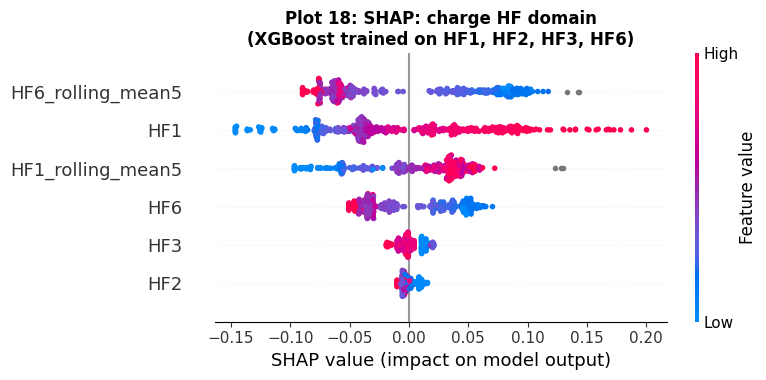

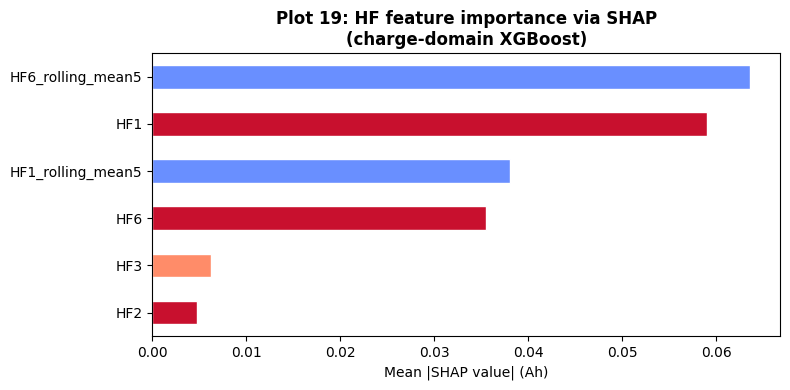

In [55]:
# SHAP analysis for HF XGBoost
print("\nComputing SHAP for HF XGBoost...")
explainer_hf = shap.TreeExplainer(xgb_hf)
shap_train_hf = explainer_hf(
    pd.DataFrame(X_hf_train, columns=FEATURES_MAP)
)
shap_test_hf  = explainer_hf(
    pd.DataFrame(X_hf_test,  columns=FEATURES_MAP)
)

# Summary plot
fig, ax = plt.subplots(figsize=(9, 5))
plt.sca(ax)
shap.summary_plot(
    shap_train_hf,
    pd.DataFrame(X_hf_train, columns=FEATURES_MAP),
    plot_type = "dot",
    show      = False
)
ax.set_title("Plot 18: SHAP: charge HF domain\n"
             "(XGBoost trained on HF1, HF2, HF3, HF6)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("./assets/plot18_shap_hf_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar importance
fig, ax = plt.subplots(figsize=(8, 4))
mean_abs_hf = np.abs(shap_train_hf.values).mean(axis=0)
hf_importance = pd.Series(mean_abs_hf,
                           index=FEATURES_MAP).sort_values(ascending=True)

colors_hf = {
    "HF1": "#C8102E",   # time 3.9→4.2V — CC charging speed
    "HF2": "#C8102E",   # voltage rise — CC charging rate
    "HF3": "#FF8C69",   # current drop — CV entry behaviour
    "HF6": "#C8102E",   # RC time constant — internal resistance
    "HF1_rolling_mean5": "#698FFF",   # RC time constant — internal resistance
    "HF6_rolling_mean5": "#698FFF",   # RC time constant — internal resistance
}
hf_importance.plot(
    kind="barh", ax=ax,
    color=[colors_hf[h] for h in hf_importance.index],
    edgecolor="white"
)
ax.set_xlabel("Mean |SHAP value| (Ah)")
ax.set_title("Plot 19: HF feature importance via SHAP\n"
             "(charge-domain XGBoost)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("./assets/plot19_shap_hf_bar.png", dpi=150, bbox_inches="tight")
plt.show()

```
Charge Domain:
"HF1": "CC charge time: internal resistance proxy",
"HF2": "Voltage rise rate: active material capacity",
"HF3": "CV current drop: charge acceptance rate",
"HF6": "RC time constant: direct internal resistance"

Discharge Domain:
"discharge_dur_s", "Total discharge time: capacity delivered",
"Q_cum_Ah", "Charge throughput: direct capacity",
"energy_Wh", "Energy delivered: capacity × voltage",
"R_int_proxy", "Internal resistance: same mechanism as HF6"
```

Both domains implicate internal resistance as primary aging driver:
- Charge domain : HF6 (RC time constant rises with R_int)
- Discharge domain: R_int_proxy (ΔV/ΔI at cycle start)
- Same electrochemical mechanism observed from two measurement angles
- Supports R_int as a causal candidate for capacity fade
- Direct motivation for DoWhy causal model as next step

### Ablation study 
Replace LSTM predicted HFs with true HFs to explain the increase in model bias due to HF smoothening. Provides the probable upper bound for the XGBoost for predictions.

In [56]:
# True HFs
hf_b0018 = hf_df[hf_df["battery"] == TEST_BAT].sort_values("cycle")

# Align to cyc_ts (cycles 11–132)
hf_b0018_aligned = hf_b0018[hf_b0018["cycle"].isin(cyc_ts)].copy()
for hf in SELECTED_HFS:
    vals = hf_b0018_aligned[hf].dropna()
    lo = vals.mean() - 3*vals.std()
    hi = vals.mean() + 3*vals.std()
    hf_b0018_aligned[hf] = hf_b0018_aligned[hf].clip(lo, hi)

X_hf_test_true = hf_b0018_aligned[SELECTED_HFS]
# X_hf_test_true["HF1_delta"] = (
#     X_hf_test_true["HF1"]
#     .transform(lambda x: x.diff().fillna(0))
# )
# X_hf_test_true["HF6_delta"] = (
#     X_hf_test_true["HF6"]
#     .transform(lambda x: x.diff().fillna(0))
# )
X_hf_test_true["HF1_rolling_mean5"] = (
    X_hf_test_true["HF1"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
X_hf_test_true["HF6_rolling_mean5"] = (
    X_hf_test_true["HF6"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
X_hf_test_true = X_hf_test_true.ffill().bfill()
X_hf_test_true = X_hf_test_true.values
y_pred_true_hf = xgb_hf.predict(X_hf_test_true)

rmse_true = mean_squared_error(y_hf_test[valid_mask], y_pred_true_hf[valid_mask])**0.5
mae_true = mean_absolute_error(y_hf_test[valid_mask], y_pred_true_hf[valid_mask])

print("Ablation: XGBoost with TRUE B0018 HFs (no LSTM prediction)")
print(f"RMSE: {rmse_true:.4f} Ah")
print(f"MAE: {mae_true:.4f} Ah")
print(f"\nError contribution")
print(f"LSTM HF prediction error contribution:"
      f"{(rmse_hf - rmse_true):.4f} Ah  "
      f"({(rmse_hf - rmse_true)/rmse_hf*100:.1f}% of total error)")
print(f"XGBoost mapping error (true HFs): "
      f"{rmse_true:.4f} Ah  "
      f"({rmse_true/rmse_hf*100:.1f}% of total error)")

# Q90 calibrated with TRUE HFs — the absolute upper bound
y_pred_true_q90 = y_pred_true_hf + offset_q90
rmse_true_q90 = mean_squared_error(
    y_hf_test[valid_mask],
    y_pred_true_q90[valid_mask]
)**0.5
print(f"True HF + Q90 calibration RMSE: {rmse_true_q90:.4f} Ah")

Ablation: XGBoost with TRUE B0018 HFs (no LSTM prediction)
RMSE: 0.0579 Ah
MAE: 0.0497 Ah

Error contribution
LSTM HF prediction error contribution:0.0015 Ah  (2.6% of total error)
XGBoost mapping error (true HFs): 0.0579 Ah  (97.4% of total error)
True HF + Q90 calibration RMSE: 0.1117 Ah


## Estimating Remaining useful life (RUL)

In [57]:
EOL_THRESHOLD  = 1.4
MIN_FIT_CYCLES = 10

## SOH Predictions
# Discharge domain: Ridge and XGBoost (132 cycles)
cyc_discharge = test_df["cycle"].values
y_true_dis = y_test.values

ridge_preds = trained["Ridge"].predict(X_test)
xgb_preds = trained["XGBoost"].predict(X_test)

# Charge domain: aligned to cyc_ts (122 cycles after window)
# raw, true HF, Q75, Q90
valid_mask_hf = ~np.isnan(y_hf_test)
cyc_hf = cyc_ts[valid_mask_hf]
y_true_hf = y_hf_test[valid_mask_hf]

xgb_hf_raw = y_pred_soh[valid_mask_hf]
xgb_hf_true = y_pred_true_hf[valid_mask_hf]
xgb_hf_q75 = xgb_hf_raw + offset_q75
xgb_hf_q90 = xgb_hf_raw + offset_q90
xgb_hf_QR = best_strategy_q

In [58]:
# True RUL
eol_candidates = cyc_discharge[y_true_dis < EOL_THRESHOLD]
true_eol = int(eol_candidates[0]) if len(eol_candidates) > 0 else int(cyc_discharge[-1])
print(f"True EOL cycle: {true_eol}")

def linear_decay_robust(hist_cyc, hist_cap):
    model = HuberRegressor()
    model.fit(hist_cyc.reshape(-1, 1), hist_cap)
    m, k = model.intercept_, model.coef_[0]
    return m, k

def compute_linear_rul(cyc_arr, cap_arr, true_eol_cycle):
    pred_rul = np.full(len(cyc_arr), np.nan)
    true_rul = np.array([max(true_eol_cycle - int(c), 0) for c in cyc_arr])

    for i in range(len(cyc_arr)):
        if i < MIN_FIT_CYCLES:
            continue
        hist_c = cyc_arr[:i+1]
        hist_cap = cap_arr[:i+1]

        # Remove NaNs
        valid = ~np.isnan(hist_cap)
        if valid.sum() < MIN_FIT_CYCLES:
            continue
        
        try:
            # m, b = np.polyfit(hist_c[valid], hist_cap[valid], 1)
            b, m = linear_decay_robust(hist_c[valid], hist_cap[valid])
            if m < 0:  
                eol_cyc = int((EOL_THRESHOLD - b) / m)
                pred_rul[i] = max(eol_cyc - int(cyc_arr[i]), 0)
        except Exception:
            pass

    return pred_rul, true_rul

print("Computing RUL for all models...")

# Discharge models use full 132 cycles
rul_ridge, true_rul_dis = compute_linear_rul(cyc_discharge, ridge_preds, true_eol)
rul_xgb_dis, _ = compute_linear_rul(cyc_discharge, xgb_preds, true_eol)

# Charge models use 122 cycles (window offset)
rul_hf_raw, true_rul_hf = compute_linear_rul(cyc_hf, xgb_hf_raw, true_eol)
rul_hf_true, _ = compute_linear_rul(cyc_hf, xgb_hf_true, true_eol)
rul_hf_q75, _ = compute_linear_rul(cyc_hf, xgb_hf_q75, true_eol)
rul_hf_q90, _ = compute_linear_rul(cyc_hf, xgb_hf_q90, true_eol)
rul_hf_QR, _ = compute_linear_rul(cyc_hf, xgb_hf_QR, true_eol)

True EOL cycle: 97
Computing RUL for all models...


Write the RUL predictions from all the models into a csv for furhter analysis and deployement.

In [59]:
# Discharge domain
dis_df = pd.DataFrame({
    "cycle": cyc_discharge,
    "true_capacity_Ah": y_true_dis,
    "true_RUL_cycles": true_rul_dis,
    "SoH_Ridge": ridge_preds,
    "SoH_XGB_discharge": xgb_preds,
    "SoH_XGB_HF_raw": np.nan,
    "SoH_XGB_HF_true": np.nan,
    "SoH_XGB_HF_Q75": np.nan,
    "SoH_XGB_HF_Q90": np.nan,
    "RUL_Ridge": rul_ridge,
    "RUL_XGB_discharge": rul_xgb_dis,
    "RUL_XGB_HF_raw": np.nan,
    "RUL_XGB_HF_true": np.nan,
    "RUL_XGB_HF_Q75": np.nan,
    "RUL_XGB_HF_Q90": np.nan,
})

# Charge domain
hf_lookup = {
    "SoH_XGB_HF_raw": dict(zip(cyc_hf, xgb_hf_raw)),
    "SoH_XGB_HF_true": dict(zip(cyc_hf, xgb_hf_true)),
    "SoH_XGB_HF_Q75": dict(zip(cyc_hf, xgb_hf_q75)),
    "SoH_XGB_HF_Q90": dict(zip(cyc_hf, xgb_hf_q90)),
    "RUL_XGB_HF_raw": dict(zip(cyc_hf, rul_hf_raw)),
    "RUL_XGB_HF_true": dict(zip(cyc_hf, rul_hf_true)),
    "RUL_XGB_HF_Q75": dict(zip(cyc_hf, rul_hf_q75)),
    "RUL_XGB_HF_Q90": dict(zip(cyc_hf, rul_hf_q90)),
    "RUL_XGB_HF_QR": dict(zip(cyc_hf, rul_hf_QR))
}
for col, lookup in hf_lookup.items():
    dis_df[col] = dis_df["cycle"].map(lookup)

# Round for readability
soh_cols = [c for c in dis_df.columns if c.startswith("SoH_")]
rul_cols  = [c for c in dis_df.columns if c.startswith("RUL_")]
dis_df[soh_cols] = dis_df[soh_cols].round(5)
dis_df[rul_cols]  = dis_df[rul_cols].round(1)
dis_df['battery'] = TEST_BAT

# Save
output_path = "./results/B0018_SoH_RUL_all_models.csv"
dis_df.to_csv(output_path, index=False, na_rep="NA")
print(f"\nCSV saved: {output_path}")
print(f"Shape: {dis_df.shape}")
print(f"\nFirst 5 rows:")
dis_df.head()


CSV saved: ./results/B0018_SoH_RUL_all_models.csv
Shape: (132, 17)

First 5 rows:


,cycle,true_capacity_Ah,true_RUL_cycles,SoH_Ridge,SoH_XGB_discharge,SoH_XGB_HF_raw,SoH_XGB_HF_true,SoH_XGB_HF_Q75,SoH_XGB_HF_Q90,RUL_Ridge,RUL_XGB_discharge,RUL_XGB_HF_raw,RUL_XGB_HF_true,RUL_XGB_HF_Q75,RUL_XGB_HF_Q90,RUL_XGB_HF_QR,battery
0,1,1.855005,96,1.84720,1.84752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0018
1,2,1.843196,95,1.83905,1.84462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0018
2,3,1.839602,94,1.83707,1.84140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0018
3,4,1.830674,93,1.82892,1.83183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0018
4,5,1.832700,92,1.83192,1.83648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0018


In [60]:
# Summary
print("\nSoH RMSE on B0018")
soh_models = {
    "Ridge (discharge)": (cyc_discharge, y_true_dis, ridge_preds),
    "XGBoost (discharge)": (cyc_discharge, y_true_dis, xgb_preds),
    "XGBoost-HF raw": (cyc_hf, y_true_hf, xgb_hf_raw),
    "XGBoost-HF true HF": (cyc_hf, y_true_hf, xgb_hf_true),
    "XGBoost-HF Q75 calibrated":(cyc_hf, y_true_hf, xgb_hf_q75),
    "XGBoost-HF Q90 calibrated":(cyc_hf, y_true_hf, xgb_hf_q90),
    "XGBoost-HF Quantile Reg":(cyc_hf, y_true_hf, xgb_hf_QR)
}
for name, (cyc, y_true, y_pred) in soh_models.items():
    valid = ~np.isnan(y_pred)
    rmse = mean_squared_error(y_true[valid], y_pred[valid])**0.5
    mae = mean_absolute_error(y_true[valid], y_pred[valid])
    print(f"{name:<35} RMSE={rmse:.4f} Ah  MAE={mae:.4f} Ah")

print("\nRUL RMSE on B0018 (linear extrapolation)")
rul_models = {
    "Ridge (discharge)": (cyc_discharge, true_rul_dis, rul_ridge),
    "XGBoost (discharge)": (cyc_discharge, true_rul_dis, rul_xgb_dis),
    "XGBoost-HF raw": (cyc_hf,true_rul_hf, rul_hf_raw),
    "XGBoost-HF true HF": (cyc_hf, true_rul_hf,  rul_hf_true),
    "XGBoost-HF Q75 calibrated": (cyc_hf, true_rul_hf,  rul_hf_q75),
    "XGBoost-HF Q90 calibrated": (cyc_hf, true_rul_hf,  rul_hf_q90),
    "XGBoost-HF Quantile Reg": (cyc_hf, true_rul_hf,  rul_hf_QR)
}
for name, (cyc, t_rul, p_rul) in rul_models.items():
    valid = ~np.isnan(p_rul)
    if valid.sum() == 0:
        print(f"  {name:<35} no valid predictions")
        continue
    rmse = mean_squared_error(t_rul[valid], p_rul[valid])**0.5
    mae  = np.abs(t_rul[valid] - p_rul[valid]).mean()
    print(f"  {name:<35} RMSE={rmse:.2f} cyc  MAE={mae:.2f} cyc")


SoH RMSE on B0018
Ridge (discharge)                   RMSE=0.0041 Ah  MAE=0.0035 Ah
XGBoost (discharge)                 RMSE=0.0069 Ah  MAE=0.0053 Ah
XGBoost-HF raw                      RMSE=0.0594 Ah  MAE=0.0477 Ah
XGBoost-HF true HF                  RMSE=0.0579 Ah  MAE=0.0497 Ah
XGBoost-HF Q75 calibrated           RMSE=0.0434 Ah  MAE=0.0346 Ah
XGBoost-HF Q90 calibrated           RMSE=0.0582 Ah  MAE=0.0488 Ah
XGBoost-HF Quantile Reg             RMSE=0.0576 Ah  MAE=0.0462 Ah

RUL RMSE on B0018 (linear extrapolation)
  Ridge (discharge)                   RMSE=8.45 cyc  MAE=5.39 cyc
  XGBoost (discharge)                 RMSE=8.19 cyc  MAE=5.38 cyc
  XGBoost-HF raw                      RMSE=13.88 cyc  MAE=10.44 cyc
  XGBoost-HF true HF                  RMSE=51.49 cyc  MAE=34.15 cyc
  XGBoost-HF Q75 calibrated           RMSE=7.18 cyc  MAE=4.18 cyc
  XGBoost-HF Q90 calibrated           RMSE=8.20 cyc  MAE=6.88 cyc
  XGBoost-HF Quantile Reg             RMSE=17.19 cyc  MAE=13.04 cyc


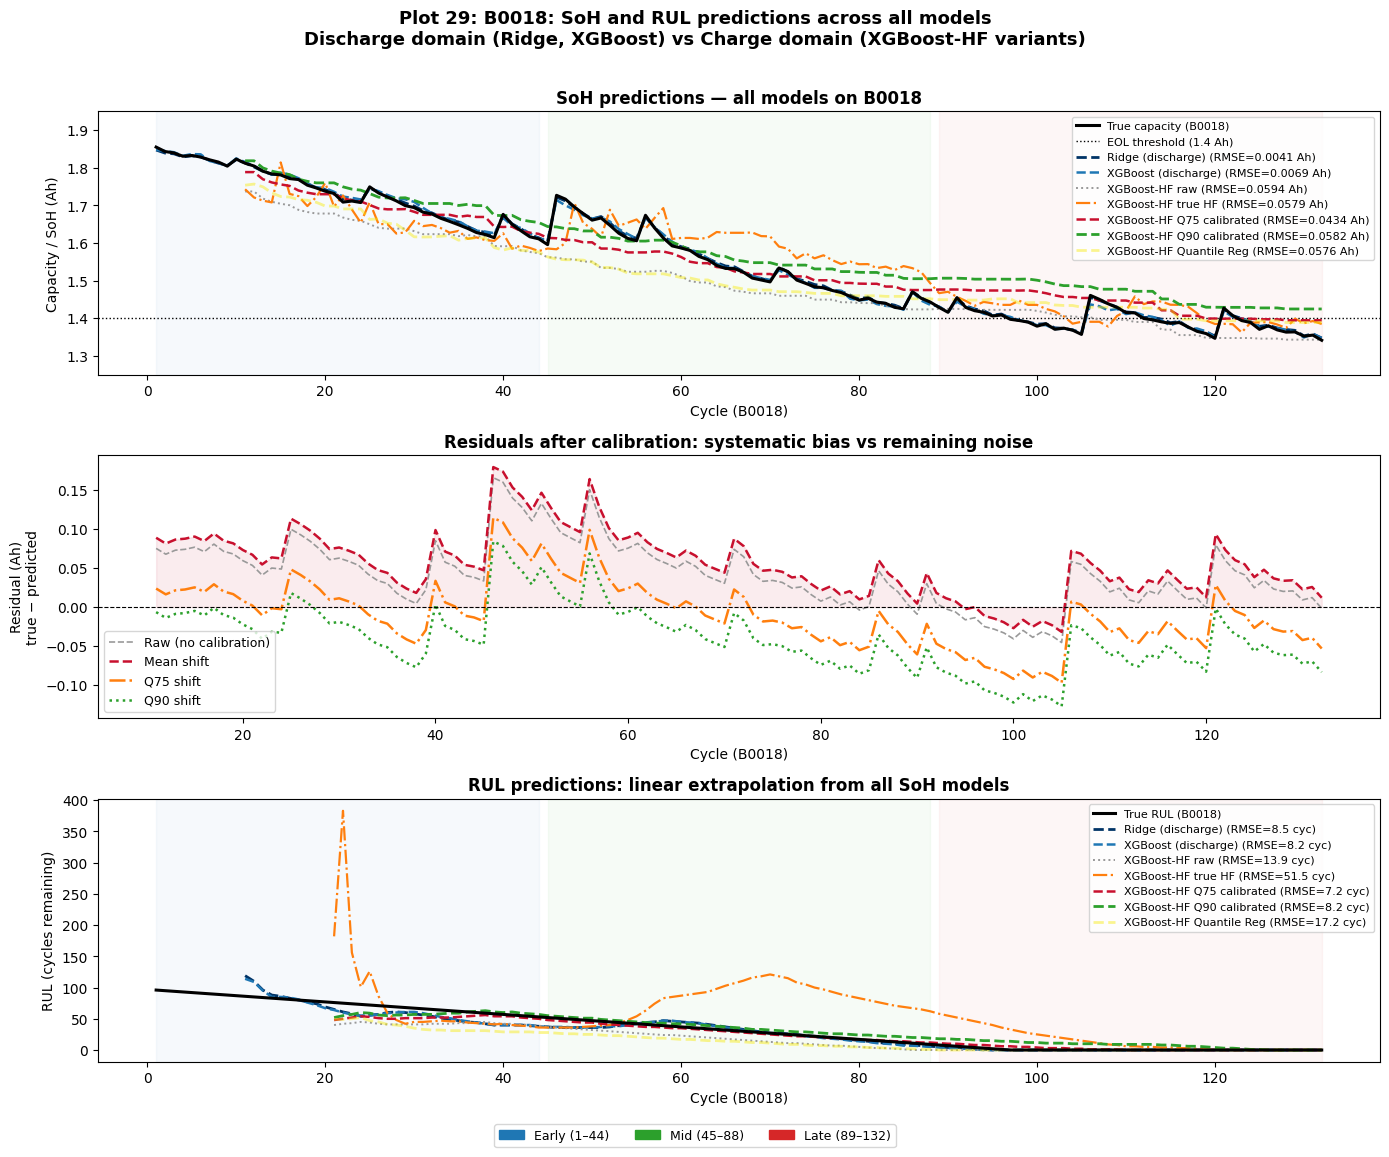

In [63]:
## Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

ax = axes[0]
ax.plot(cyc_discharge, y_true_dis,
        color="black", linewidth=2.2, zorder=10,
        label="True capacity (B0018)")
ax.axhline(EOL_THRESHOLD, color="black", linestyle=":",
           linewidth=1.0, label="EOL threshold (1.4 Ah)")

model_styles = {
    "Ridge (discharge)": (cyc_discharge, ridge_preds, "#003366", "--", 2.0),
    "XGBoost (discharge)": (cyc_discharge, xgb_preds, "#1f77b4", "--", 1.8),
    "XGBoost-HF raw": (cyc_hf, xgb_hf_raw,"#999999", ":", 1.4),
    "XGBoost-HF true HF": (cyc_hf, xgb_hf_true,"#ff7f0e", "-.", 1.6),
    "XGBoost-HF Q75 calibrated": (cyc_hf, xgb_hf_q75, "#C8102E", "--",  1.8),
    "XGBoost-HF Q90 calibrated": (cyc_hf, xgb_hf_q90, "#2ca02c", "--",  2.0),
    "XGBoost-HF Quantile Reg": (cyc_hf, xgb_hf_QR, "#f7eb0a73", "--",  2.0),
}

for label, (cyc, pred, color, ls, lw) in model_styles.items():
    valid = ~np.isnan(pred)
    rmse  = mean_squared_error(
        y_true_dis[np.isin(cyc_discharge, cyc[valid])]
        if cyc is cyc_discharge
        else y_hf_test[np.isin(cyc_ts, cyc[valid])],
        pred[valid]
    )**0.5 if valid.sum() > 0 else np.nan
    ax.plot(cyc[valid], pred[valid],
            color=color, linestyle=ls, linewidth=lw,
            label=f"{label} (RMSE={rmse:.4f} Ah)" if not np.isnan(rmse) else label)

ax.set_xlabel("Cycle (B0018)")
ax.set_ylabel("Capacity / SoH (Ah)")
ax.set_title("SoH predictions — all models on B0018",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(1.25, 1.95)

# Phase shading
ax.axvspan(1, 44, alpha=0.04, color="#1f77b4")
ax.axvspan(45, 88, alpha=0.04, color="#2ca02c")
ax.axvspan(89, 132, alpha=0.04, color="#d62728")

ax = axes[1]

line_styles = {
    "Raw (no calibration)": ("--", "#999999", 1.2),
    "Mean shift": ("--", "#C8102E", 1.8),
    "Q75 shift": ("-.", "#ff7f0e", 1.8),
    "Q90 shift": (":",  "#2ca02c", 1.8),
}
for name, style in line_styles.items():
    ls, color, lw = style
    resid = y_true_valid - results_cal[name]["pred"]
    ax.plot(cyc_valid_b3, resid,
            linestyle=ls, color=color, linewidth=lw, label=name)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(cyc_valid_b3,
                y_true_valid - results_cal["Mean shift"]["pred"], 0,
                alpha=0.08, color="#C8102E")
ax.set_xlabel("Cycle (B0018)")
ax.set_ylabel("Residual (Ah)\ntrue − predicted")
ax.set_title("Residuals after calibration: systematic bias vs remaining noise",
             fontweight="bold")
ax.legend(fontsize=9)

ax = axes[2]

# True RUL (use discharge ground truth)
ax.plot(cyc_discharge, true_rul_dis,
        color="black", linewidth=2.2, zorder=10,
        label="True RUL (B0018)")

rul_styles = {
    "Ridge (discharge)": (cyc_discharge, rul_ridge,"#003366", "--", 2.0),
    "XGBoost (discharge)": (cyc_discharge, rul_xgb_dis,"#1f77b4", "--", 1.8),
    "XGBoost-HF raw": (cyc_hf,rul_hf_raw, "#999999", ":", 1.4),
    "XGBoost-HF true HF": (cyc_hf, rul_hf_true, "#ff7f0e", "-.", 1.6),
    "XGBoost-HF Q75 calibrated": (cyc_hf, rul_hf_q75, "#C8102E", "--", 1.8),
    "XGBoost-HF Q90 calibrated": (cyc_hf, rul_hf_q90, "#2ca02c", "--", 2.0),
    "XGBoost-HF Quantile Reg": (cyc_hf, rul_hf_QR, "#f7eb0a73", "--", 2.0)
}

# "XGBoost-HF Quantile Reg": (cyc_hf, rul_hf_qr75, "#cd11b4", "--", 2.0),

for label, (cyc, rul, color, ls, lw) in rul_styles.items():
    valid = ~np.isnan(rul)
    if valid.sum() == 0:
        continue
    t_rul_aligned = np.array([
        max(true_eol - int(c), 0) for c in cyc[valid]
    ])
    rmse = mean_squared_error(t_rul_aligned, rul[valid])**0.5
    ax.plot(cyc[valid], rul[valid],
            color=color, linestyle=ls, linewidth=lw,
            label=f"{label} (RMSE={rmse:.1f} cyc)")

ax.set_xlabel("Cycle (B0018)")
ax.set_ylabel("RUL (cycles remaining)")
ax.set_title("RUL predictions: linear extrapolation from all SoH models",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper right")

ax.axvspan(1, 44, alpha=0.04, color="#1f77b4")
ax.axvspan(45, 88, alpha=0.04, color="#2ca02c")
ax.axvspan(89, 132, alpha=0.04, color="#d62728")

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color="#1f77b4", label="Early (1–44)"),
    Patch(color="#2ca02c", label="Mid (45–88)"),
    Patch(color="#d62728", label="Late (89–132)"),
], loc="lower center", ncol=3, fontsize=9,
   bbox_to_anchor=(0.5, -0.03))

plt.suptitle(
    "Plot 29: B0018: SoH and RUL predictions across all models\n"
    "Discharge domain (Ridge, XGBoost) vs Charge domain (XGBoost-HF variants)",
    fontweight="bold", y=1.01, fontsize=13
)
plt.tight_layout()
plt.savefig("./assets/plot29_final_soh_rul_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# MODEL EVALUATION

### Phase wise summary of all models
Compare the models at phase level. Evaluate the changing capacity and RUL predictions.

In [64]:
PHASES = {
    "Early (1-44)":(1, 44),
    "Mid (45-88)":(45, 88),
    "Late (89-132)":(89, 132),
}
# align cycles
cyc_dis = test_df["cycle"].values 
y_true_dis = y_test.values    

# Charge domain
cyc_hf_v = cyc_ts[valid_mask_hf]       
y_true_hf_v = y_hf_test[valid_mask_hf]   

# True RUL 
eol_candidates = cyc_dis[y_true_dis < EOL_THRESHOLD]
true_eol = int(eol_candidates[0]) if len(eol_candidates) > 0 else int(cyc_dis[-1])
true_rul_dis_arr = np.array([max(true_eol - int(c), 0) for c in cyc_dis])
true_rul_hf_arr = np.array([max(true_eol - int(c), 0) for c in cyc_hf_v])

# models
models = {
    "Ridge (discharge)": {
        "cyc": cyc_dis,
        "y_true": y_true_dis,
        "soh_pred": ridge_preds,
        "rul_pred": rul_ridge,
        "true_rul": true_rul_dis_arr,
    },
    "XGBoost (discharge)": {
        "cyc": cyc_dis,
        "y_true": y_true_dis,
        "soh_pred": xgb_preds,
        "rul_pred": rul_xgb_dis,
        "true_rul": true_rul_dis_arr,
    },
    "XGBoost-HF raw": {
        "cyc": cyc_hf_v,
        "y_true": y_true_hf_v,
        "soh_pred": xgb_hf_raw,
        "rul_pred": rul_hf_raw,
        "true_rul": true_rul_hf_arr,
    },
    "XGBoost-HF true HF": {
        "cyc": cyc_hf_v,
        "y_true": y_true_hf_v,
        "soh_pred": xgb_hf_true,
        "rul_pred": rul_hf_true,
        "true_rul": true_rul_hf_arr,
    },
    "XGBoost-HF Q75": {
        "cyc": cyc_hf_v,
        "y_true": y_true_hf_v,
        "soh_pred": xgb_hf_q75,
        "rul_pred": rul_hf_q75,
        "true_rul": true_rul_hf_arr,
    },
    "XGBoost-HF Q90": {
        "cyc": cyc_hf_v,
        "y_true": y_true_hf_v,
        "soh_pred": xgb_hf_q90,
        "rul_pred": rul_hf_q90,
        "true_rul": true_rul_hf_arr,
    }
}

In [65]:
def phase_rmse(cyc_arr, true_arr, pred_arr, lo, hi):
    mask = (cyc_arr >= lo) & (cyc_arr <= hi) & ~np.isnan(pred_arr)
    n = mask.sum()
    if n == 0:
        return np.nan, 0
    rmse = mean_squared_error(true_arr[mask], pred_arr[mask]) ** 0.5
    return rmse, n

soh_rows, rul_rows = [], []

for model_name, cfg in models.items():
    cyc = cfg["cyc"]
    soh_row = {"Model": model_name}
    rul_row = {"Model": model_name}

    for phase_label, (lo, hi) in PHASES.items():
        # SoH
        rmse_s, n_s = phase_rmse(cyc, cfg["y_true"], cfg["soh_pred"], lo, hi)
        soh_row[f"{phase_label}"] = (
            f"{rmse_s:.4f} (n={n_s})" if not np.isnan(rmse_s) else "—"
        )
        # RUL
        rmse_r, n_r = phase_rmse(cyc, cfg["true_rul"], cfg["rul_pred"], lo, hi)
        rul_row[f"{phase_label}"] = (
            f"{rmse_r:.2f} (n={n_r})" if not np.isnan(rmse_r) else "—"
        )

    # Overall
    valid_s = ~np.isnan(cfg["soh_pred"])
    overall_soh = mean_squared_error(
        cfg["y_true"][valid_s], cfg["soh_pred"][valid_s]
    ) ** 0.5
    soh_row["Overall"] = f"{overall_soh:.4f}"

    valid_r = ~np.isnan(cfg["rul_pred"])
    if valid_r.sum() > 0:
        overall_rul = mean_squared_error(
            cfg["true_rul"][valid_r], cfg["rul_pred"][valid_r]
        ) ** 0.5
        rul_row["Overall"] = f"{overall_rul:.2f}"
    else:
        rul_row["Overall"] = "—"

    soh_rows.append(soh_row)
    rul_rows.append(rul_row)

soh_phase_df = pd.DataFrame(soh_rows).set_index("Model")
rul_phase_df = pd.DataFrame(rul_rows).set_index("Model")

print("PHASE-WISE SoH RMSE (Ah)")
print("-" * 80)
print(soh_phase_df.to_string())

print("PHASE-WISE RUL RMSE (cycles)")
print("-" * 80)
print(rul_phase_df.to_string())

soh_phase_df.to_csv("./results/phase_rmse_soh.csv")
rul_phase_df.to_csv("./results/phase_rmse_rul.csv")

PHASE-WISE SoH RMSE (Ah)
--------------------------------------------------------------------------------
                      Early (1-44)    Mid (45-88)  Late (89-132) Overall
Model                                                                   
Ridge (discharge)    0.0040 (n=44)  0.0045 (n=44)  0.0039 (n=44)  0.0041
XGBoost (discharge)  0.0071 (n=44)  0.0067 (n=44)  0.0069 (n=44)  0.0069
XGBoost-HF raw       0.0611 (n=34)  0.0770 (n=44)  0.0311 (n=44)  0.0594
XGBoost-HF true HF   0.0486 (n=34)  0.0770 (n=44)  0.0391 (n=44)  0.0579
XGBoost-HF Q75       0.0234 (n=34)  0.0464 (n=44)  0.0515 (n=44)  0.0434
XGBoost-HF Q90       0.0337 (n=34)  0.0489 (n=44)  0.0782 (n=44)  0.0582
PHASE-WISE RUL RMSE (cycles)
--------------------------------------------------------------------------------
                     Early (1-44)   Mid (45-88) Late (89-132) Overall
Model                                                                
Ridge (discharge)    14.18 (n=34)   6.47 (n=44)   0.94 (n=44

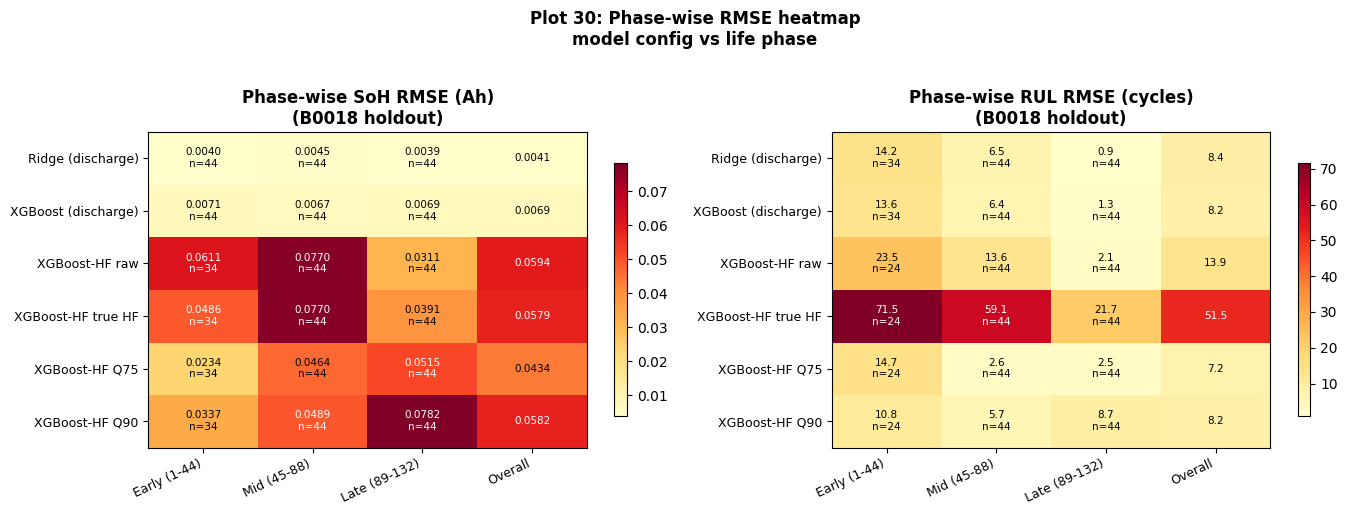

In [66]:
def extract_numeric(df):
    return df.map(lambda x: float(x.split(" ")[0]) if x != "—" else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, fmt, cmap in zip(
    axes,
    [soh_phase_df, rul_phase_df],
    ["SoH RMSE (Ah)", "RUL RMSE (cycles)"],
    [".4f", ".1f"],
    ["YlOrRd", "YlOrRd"]):
    num_df = extract_numeric(df)

    im = ax.imshow(num_df.values, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Axis labels
    ax.set_xticks(range(len(num_df.columns)))
    ax.set_xticklabels(num_df.columns, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(len(num_df.index)))
    ax.set_yticklabels(num_df.index, fontsize=9)

    # Cell annotations
    for i in range(len(num_df.index)):
        for j in range(len(num_df.columns)):
            val = num_df.iloc[i, j]
            if not np.isnan(val):
                # Count string for context
                raw = df.iloc[i, j]
                n_str = ""
                if "n=" in raw:
                    n_str = "\n" + raw.split("(")[1].rstrip(")")
                ax.text(
                    j, i,
                    f"{val:{fmt}}{n_str}",
                    ha="center", va="center",
                    fontsize=7.5,
                    color="white" if val > num_df.values[~np.isnan(
                        num_df.values)].max() * 0.6 else "black"
                )
            else:
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=9, color="gray")

    ax.set_title(f"Phase-wise {title}\n(B0018 holdout)",
                 fontweight="bold")

plt.suptitle(
    "Plot 30: Phase-wise RMSE heatmap\n"
    "model config vs life phase",
    fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("./assets/plot30_phase_rmse_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Residual analysis: Discharge model evaluation

In [67]:
# Residual Normality check

print("\nResidual distribution (Shapiro-Wilk normality test)")
y_true = test_df["capacity_Ah"].values
for name in ["Ridge", "RandomForest", "XGBoost"]:
    resid = y_true - holdout_results[name]["y_pred"]
    stat, p = stats.shapiro(resid)
    skew = stats.skew(resid)
    kurt = stats.kurtosis(resid)
    print(f"{name:>14}  W={stat:.4f}  p={p:.4f}  "
          f"skew={skew:.3f}  kurtosis={kurt:.3f}  "
          f"{'normal' if p > 0.05 else 'non-normal'}")


Residual distribution (Shapiro-Wilk normality test)
         Ridge  W=0.9749  p=0.0152  skew=0.535  kurtosis=-0.079  non-normal
  RandomForest  W=0.9589  p=0.0005  skew=0.732  kurtosis=0.988  non-normal
       XGBoost  W=0.9646  p=0.0016  skew=0.769  kurtosis=1.515  non-normal


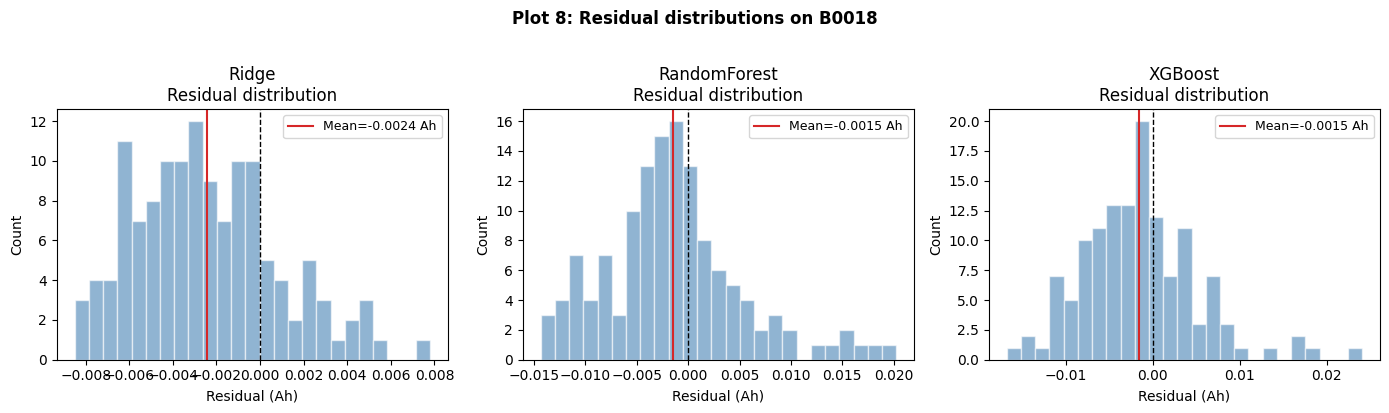

In [68]:
# Error Distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, ["Ridge", "RandomForest", "XGBoost"]):
    resid  = y_true - holdout_results[name]["y_pred"]
    colors = np.where(cycles_test <= 44,  "#1f77b4",
             np.where(cycles_test <= 88,  "#2ca02c", "#d62728"))

    ax.hist(resid, bins=25, color="steelblue", alpha=0.6, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
    ax.axvline(resid.mean(),color="#d62728",linewidth=1.5,
               linestyle="-", label=f"Mean={resid.mean():.4f} Ah")
    ax.set_xlabel("Residual (Ah)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name}\nResidual distribution")
    ax.legend(fontsize=9)

plt.suptitle("Plot 8: Residual distributions on B0018",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./assets/plot8_residual_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

#### Discharge model summary and decision criteria
Decision criteria (in priority order):
  1. Explainability: SHAP must explain genuine degradation patterns, not memorised training artefacts
  2. Generalisation: low train→val overfitting ratio
  3. Holdout RMSE: performance on unseen battery

Ridge:
  + Lowest B0018 RMSE (0.0051 Ah), lowest val/train ratio (4.8×)
  + Residuals show interpretable systematic bias (inter-battery offset)
  - Coefficients already interpretable as a result SHAP adds limited insight
  - Cannot capture non-linear interactions between features

XGBoost (tuned):
  + Native TreeSHAP: exact, fast, captures interaction effects
  + Non-linear: can model the knee point and recovery bump dynamics
  - Train→val ratio 41× before tuning — must verify tuned ratio < 10×
  - SHAP explanations only valid if overfitting is resolved
""")

# MODEL EXPLAINABILITY

## Discharge Model
SHAP and feature explainability for discharge model to understand the physics based fields driving the battery capacity.

#### SHAP Explainability
fit linear and tree-based shap explainer to analyse the feature influence.

In [69]:
# shap.initjs()   

def get_model_and_data(pipeline, X, feat_cols):
    X_transformed = pipeline[:-1].transform(X)
    model = pipeline[-1]              
    X_df = pd.DataFrame(X_transformed, columns=feat_cols)
    return model, X_df

Linear Explainer

In [70]:
print("Computing Ridge SHAP values...")
ridge_model, X_train_scaled = get_model_and_data(trained["Ridge"], X_train, feat_cols)
_, X_test_scaled = get_model_and_data(trained["Ridge"], X_test, feat_cols)

ridge_explainer = shap.LinearExplainer(ridge_model, X_train_scaled)
ridge_shap_train = ridge_explainer(X_train_scaled)
ridge_shap_test = ridge_explainer(X_test_scaled)

Computing Ridge SHAP values...


Tree Explainer

In [71]:
print("Computing XGBoost SHAP values...")
xgb_model, X_train_xgb = get_model_and_data(trained["XGBoost"], X_train, feat_cols)
_, X_test_xgb = get_model_and_data(trained["XGBoost"], X_test, feat_cols)

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_train = xgb_explainer(X_train_xgb)
xgb_shap_test = xgb_explainer(X_test_xgb)

Computing XGBoost SHAP values...


Summary Plots

C:\Users\shast\AppData\Local\Temp\ipykernel_2788\4144233129.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\shast\AppData\Local\Temp\ipykernel_2788\4144233129.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


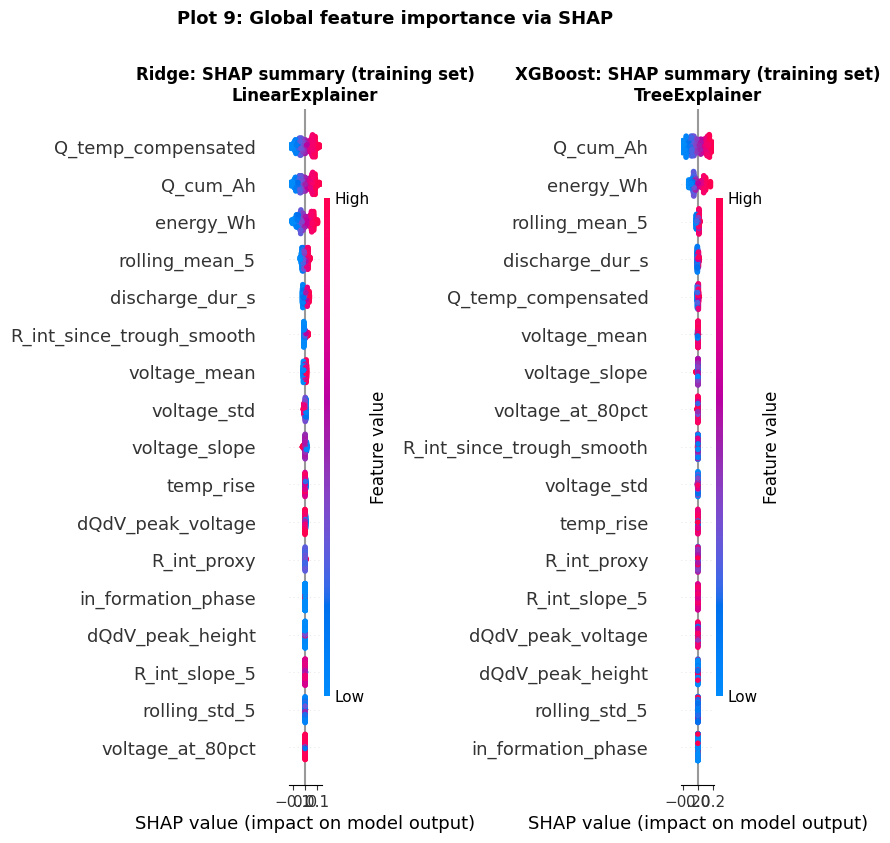

In [89]:
# The beeswarm plot shows:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(
    ridge_shap_train,
    X_train_scaled,
    plot_type = "dot",
    show = False,
    title = ""
)
axes[0].set_title("Ridge: SHAP summary (training set)\nLinearExplainer", fontweight="bold")

plt.sca(axes[1])
shap.summary_plot(
    xgb_shap_train,
    X_train_xgb,
    plot_type = "dot",
    show = False,
    title = ""
)
axes[1].set_title("XGBoost: SHAP summary (training set)\nTreeExplainer", fontweight="bold")

plt.suptitle("Plot 9: Global feature importance via SHAP", fontweight="bold", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("./assets/plot9_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

Bar Plot

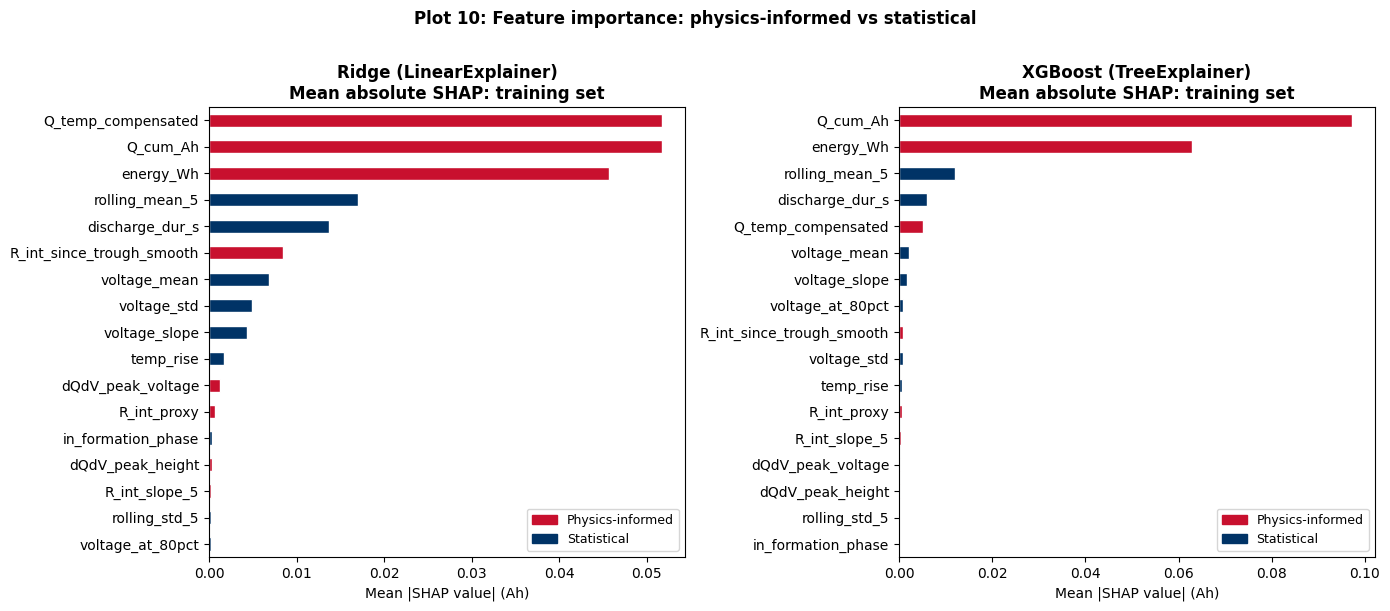

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, shap_vals, label in zip(
    axes,
    [ridge_shap_train, xgb_shap_train],
    ["Ridge (LinearExplainer)", "XGBoost (TreeExplainer)"]
):
    mean_abs = np.abs(shap_vals.values).mean(axis=0)
    importance = pd.Series(mean_abs, index=feat_cols).sort_values(ascending=True)

    colors = ["#C8102E" if "dQdV" in f or "R_int" in f or
              "energy" in f or "Q_temp" in f or "Q_cum" in f
              or "Rct" in f or "Re" in f
              else "#003366"
              for f in importance.index]

    importance.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
    ax.set_xlabel("Mean |SHAP value| (Ah)")
    ax.set_title(f"{label}\nMean absolute SHAP: training set", fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.5)

    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="#C8102E", label="Physics-informed"),
        Patch(color="#003366", label="Statistical"),
    ], fontsize=9, loc="lower right")

plt.suptitle("Plot 10: Feature importance: physics-informed vs statistical",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot10_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Dependence Plot

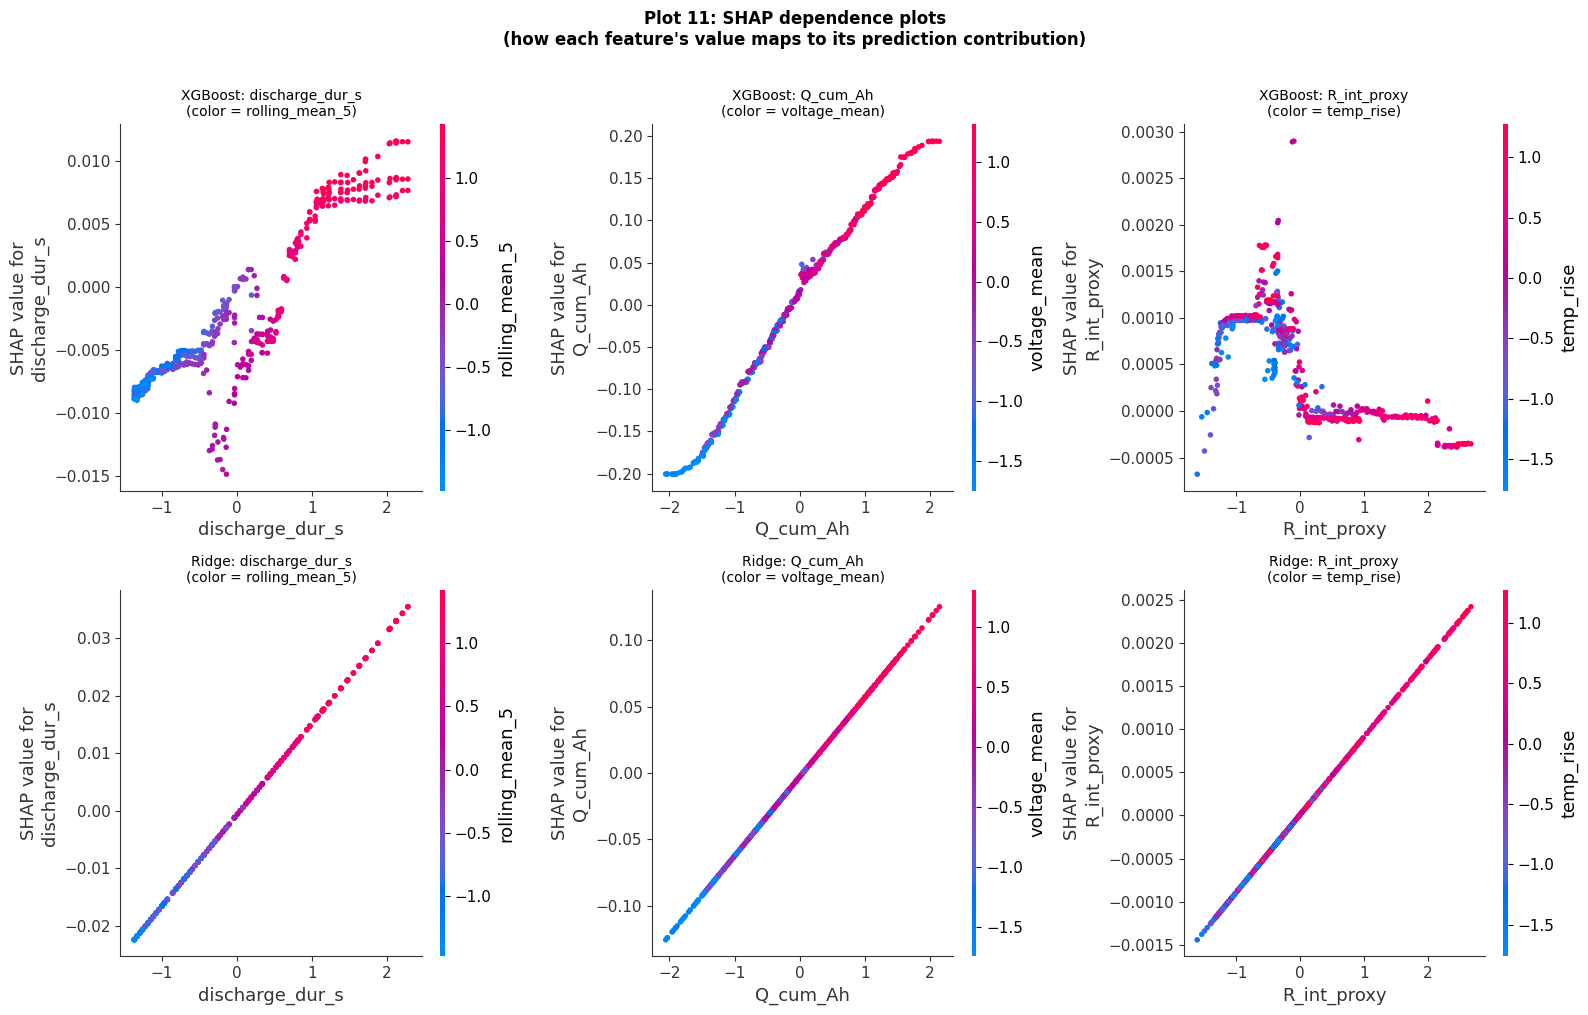

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Features to examine top 3 by importance, expected from EDA
dep_features  = ["discharge_dur_s", "Q_cum_Ah", "R_int_proxy"]
# Interaction features what modulates each relationship
inter_features = ["rolling_mean_5", "voltage_mean", "temp_rise"]

for row, (shap_vals, X_data, label) in enumerate([
    (xgb_shap_train, X_train_xgb, "XGBoost"),
    (ridge_shap_train, X_train_scaled, "Ridge"),
]):
    for col, (feat, inter) in enumerate(zip(dep_features, inter_features)):
        ax = axes[row, col]
        shap.dependence_plot(
            feat,
            shap_vals.values,
            X_data,
            interaction_index = inter,
            ax = ax,
            show = False,
        )
        ax.set_title(f"{label}: {feat}\n(color = {inter})", fontsize=10)

plt.suptitle("Plot 11: SHAP dependence plots\n"
             "(how each feature's value maps to its prediction contribution)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot11_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

```
Force Plot for XGBoost:
A force plot shows how each feature pushes the prediction up or down from the model’s base value (the average prediction)
Foe example, higher the energy_Wh, larger the capacity and vice-versa.
Similarly, lower resistance pushes capacity upward.
```

In [ ]:
shap.initjs()
shap.force_plot(xgb_explainer.expected_value, xgb_explainer.shap_values(X_train_xgb), X_train_xgb)

In [76]:
# Permutation Importance
#  xgb_pipe_inst = Pipeline([
#         ("scaler", StandardScaler()),
#         ("model",  XGBRegressor(n_estimators = 300, learning_rate = 0.05, max_depth = 4, subsample = 0.8, reg_alpha = 0.1,
#                                 reg_lambda = 1.0, colsample_bytree = 0.8, random_state = RANDOM_STATE, verbosity = 0, n_jobs = -1
#         ))
#     ])

# xgb_pipe_inst.fit(X_train, y_train)
# result = permutation_importance(xgb_pipe_inst, X_train, y_train, random_state=42, scoring='neg_mean_squared_error')
# sorted_idx = result.importances_mean.argsort()

# plt.figure(figsize=(10,6), dpi=100)
# plt.boxplot(result.importances[sorted_idx].T,
#            vert=False, labels=np.array(feat_cols)[sorted_idx])
# plt.title("Permutation Importances (on Training Data)")
# plt.show()

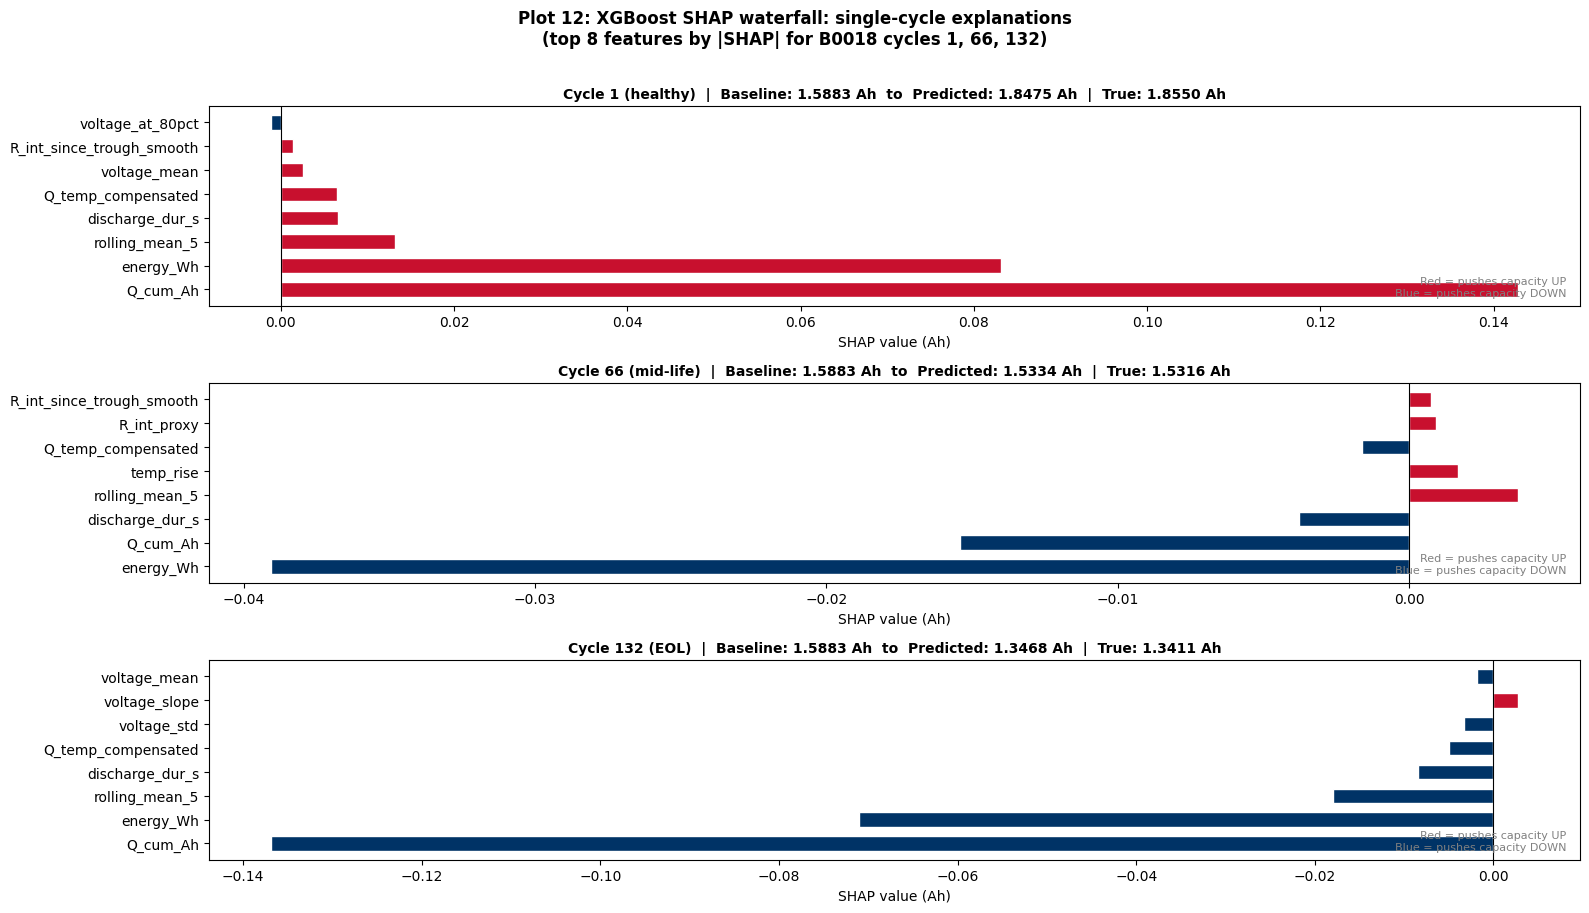

In [77]:
target_cycles = {
    "Cycle 1 (healthy)": 0,
    "Cycle 66 (mid-life)": 65,
    "Cycle 132 (EOL)": 131,
}

fig, axes = plt.subplots(len(target_cycles), 1, figsize=(16, 9))

for ax, (label, idx) in zip(axes, target_cycles.items()):
    shap_row = xgb_shap_test[idx]
    base_value = xgb_shap_test.base_values[idx]
    pred_value = base_value + xgb_shap_test.values[idx].sum()

    # Manual waterfall — more readable in static output than force plot
    contributions = pd.Series(
        xgb_shap_test.values[idx], index=feat_cols
    ).sort_values(key=abs, ascending=False).head(8)

    colors = ["#C8102E" if v > 0 else "#003366"
              for v in contributions.values]

    ax.barh(contributions.index, contributions.values,
            color=colors, edgecolor="white", height=0.6)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP value (Ah)")
    ax.set_title(
        f"{label}  |  Baseline: {base_value:.4f} Ah  to  "
        f"Predicted: {pred_value:.4f} Ah  |  "
        f"True: {y_test.values[idx]:.4f} Ah",
        fontsize=10, fontweight="bold"
    )
    ax.text(0.99, 0.05, "Red = pushes capacity UP\nBlue = pushes capacity DOWN",
            transform=ax.transAxes, ha="right", fontsize=8,
            color="gray")

plt.suptitle("Plot 12: XGBoost SHAP waterfall: single-cycle explanations\n"
             "(top 8 features by |SHAP| for B0018 cycles 1, 66, 132)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot12_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

Cross-Model Importance

In [78]:
print("Computing RF permutation importance...")
rf_perm = permutation_importance(
    trained["RandomForest"], X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1
)

ridge_imp = pd.Series(
    np.abs(ridge_shap_train.values).mean(axis=0),
    index=feat_cols
)
xgb_imp = pd.Series(
    np.abs(xgb_shap_train.values).mean(axis=0),
    index=feat_cols
)
rf_imp = pd.Series(
    rf_perm.importances_mean,
    index=feat_cols
)

importance_df = pd.DataFrame({
    "Ridge SHAP": ridge_imp,
    "XGBoost SHAP": xgb_imp,
    "RF Permutation": rf_imp,
}).sort_values("XGBoost SHAP", ascending=False)

# Add feature type label
physics = {"R_int_proxy","energy_Wh","Q_cum_Ah","Q_temp_compensated",
           "dQdV_peak_height","dQdV_peak_voltage"}
importance_df["Type"] = ["Physics" if f in physics else "Statistical"
                         for f in importance_df.index]

print("\nCross-model feature importance (mean |SHAP| or permutation)")
print(importance_df.round(5).to_string())

Computing RF permutation importance...

Cross-model feature importance (mean |SHAP| or permutation)
                           Ridge SHAP  XGBoost SHAP  RF Permutation         Type
Q_cum_Ah                      0.05178       0.09724         0.15415      Physics
energy_Wh                     0.04570       0.06290         0.25399      Physics
rolling_mean_5                0.01697       0.01208         0.00925  Statistical
discharge_dur_s               0.01367       0.00593         0.00015  Statistical
Q_temp_compensated            0.05178       0.00512         0.13876      Physics
voltage_mean                  0.00683       0.00217         0.00006  Statistical
voltage_slope                 0.00434       0.00182         0.00001  Statistical
voltage_at_80pct              0.00016       0.00095         0.00000  Statistical
R_int_since_trough_smooth     0.00843       0.00086         0.00001  Statistical
voltage_std                   0.00493       0.00077         0.00002  Statistical
temp_rise

## Charge Model using Health Factors
Interpreting XGBoost model with inputs from LSTM for future cycle prediction. Understanding the drivers of the capacity among the health factors.

```
ANALYSIS 1: Split strategy comparison
Three strategies on the same XGBoost model:
A. Random shuffle (wrong: cycle leakage)
B. Temporal within-battery 50/50 (paper's approach)
C. Cross-battery holdout
```

In [79]:
EOL_THRESHOLD = 1.4
BAT_COLORS = {
    "B0005": "#1f77b4", "B0006": "#ff7f0e",
    "B0007": "#2ca02c", "B0018": "#d62728"
}

feat_cols = [
    "discharge_dur_s","voltage_mean","voltage_std","voltage_slope",
    "voltage_at_80pct","temp_rise","R_int_proxy", "R_int_since_trough_smooth", "R_int_slope_5", "in_formation_phase",
    "energy_Wh", "Q_cum_Ah","Q_temp_compensated","dQdV_peak_height",
    "dQdV_peak_voltage","rolling_mean_5","rolling_std_5"
]

all_df = feature_df.copy()
X_all = all_df[feat_cols].values
y_all = all_df["capacity_Ah"].values

xgb_base = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)

In [80]:
# Strategy A: Random shuffle split
from sklearn.model_selection import train_test_split

xgb_base = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)
X_rnd_tr, X_rnd_te, y_rnd_tr, y_rnd_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)
xgb_base.fit(X_rnd_tr, y_rnd_tr)
rmse_random = mean_squared_error(y_rnd_te, xgb_base.predict(X_rnd_te))**0.5

# strategy B: Temporal within-battery
xgb_base = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)
X_temp_tr, X_temp_te, y_temp_tr, y_temp_te = [], [], [], []
for bat in ["B0005","B0006","B0007","B0018"]:
    sub = all_df[all_df["battery"]==bat].sort_values("cycle")
    n = len(sub)
    mid = n // 2
    X_temp_tr.append(sub[feat_cols].values[:mid])
    y_temp_tr.append(sub["capacity_Ah"].values[:mid])
    X_temp_te.append(sub[feat_cols].values[mid:])
    y_temp_te.append(sub["capacity_Ah"].values[mid:])

X_temp_tr = np.concatenate(X_temp_tr)
y_temp_tr = np.concatenate(y_temp_tr)
X_temp_te = np.concatenate(X_temp_te)
y_temp_te = np.concatenate(y_temp_te)

xgb_base.fit(X_temp_tr, y_temp_tr)
rmse_temporal = mean_squared_error(y_temp_te, xgb_base.predict(X_temp_te))**0.5

# Strategy C: Cross-battery holdout
xgb_base = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)
xgb_base.fit(X_train, y_train)
rmse_crossbat = mean_squared_error(y_test, xgb_base.predict(X_test))**0.5

# Results table
split_results = pd.DataFrame([
    {
        "Strategy": "A Random shuffle",
        "Description": "Cycles mixed across batteries",
        "Train size": len(X_rnd_tr),
        "Test size": len(X_rnd_te),
        "RMSE (Ah)": round(rmse_random, 4),
        "Valid?": "Leaks future cycles"
    },
    {
        "Strategy": "B Temporal within-battery (paper)",
        "Description": "First 50% train, last 50% test per battery",
        "Train size": len(X_temp_tr),
        "Test size": len(X_temp_te),
        "RMSE (Ah)": round(rmse_temporal, 4)
    },
    {
        "Strategy": "C Cross-battery holdout",
        "Description": "Train B0005+B0006+B0007, test B0018",
        "Train size": len(X_train),
        "Test size": len(X_test),
        "RMSE (Ah)": round(rmse_crossbat, 4)
    },
]).set_index("Strategy")

print(split_results.to_string())
print(f"\nInflation factor A/C : {rmse_random/rmse_crossbat:.1f}×  "
      f"(random shuffle appears {rmse_random/rmse_crossbat:.1f}× worse)")
print(f"Inflation factor B/C : {rmse_temporal/rmse_crossbat:.1f}×  "
      f"(within-battery split appears {rmse_temporal/rmse_crossbat:.1f}× worse)")

                                                                  Description  Train size  Test size  RMSE (Ah)               Valid?
Strategy                                                                                                                            
A Random shuffle                                Cycles mixed across batteries         508        128     0.0085  Leaks future cycles
B Temporal within-battery (paper)  First 50% train, last 50% test per battery         318        318     0.1413                  NaN
C Cross-battery holdout                   Train B0005+B0006+B0007, test B0018         504        132     0.0076                  NaN

Inflation factor A/C : 1.1×  (random shuffle appears 1.1× worse)
Inflation factor B/C : 18.6×  (within-battery split appears 18.6× worse)


```
ANALYSIS 2: Error propagation curve
RMSE of LSTM HF predictions as a function of rollout horizon
```

 horizon        HF1    HF2    HF3        HF6
       1  10.069600 0.0031 0.0028   3.996300
       5  75.807701 0.0027 0.0125  19.772400
      10  68.466202 0.0030 0.0148  24.192200
      20  75.341599 0.0034 0.0176  24.559700
      30  82.726402 0.0030 0.0208  25.752800
      50 290.760803 0.0120 0.0676 111.241600
      75 241.059296 0.0106 0.0709 107.294403
     100 213.304199 0.0099 0.0675  96.518097
     122 194.437195 0.0108 0.0644  90.609703


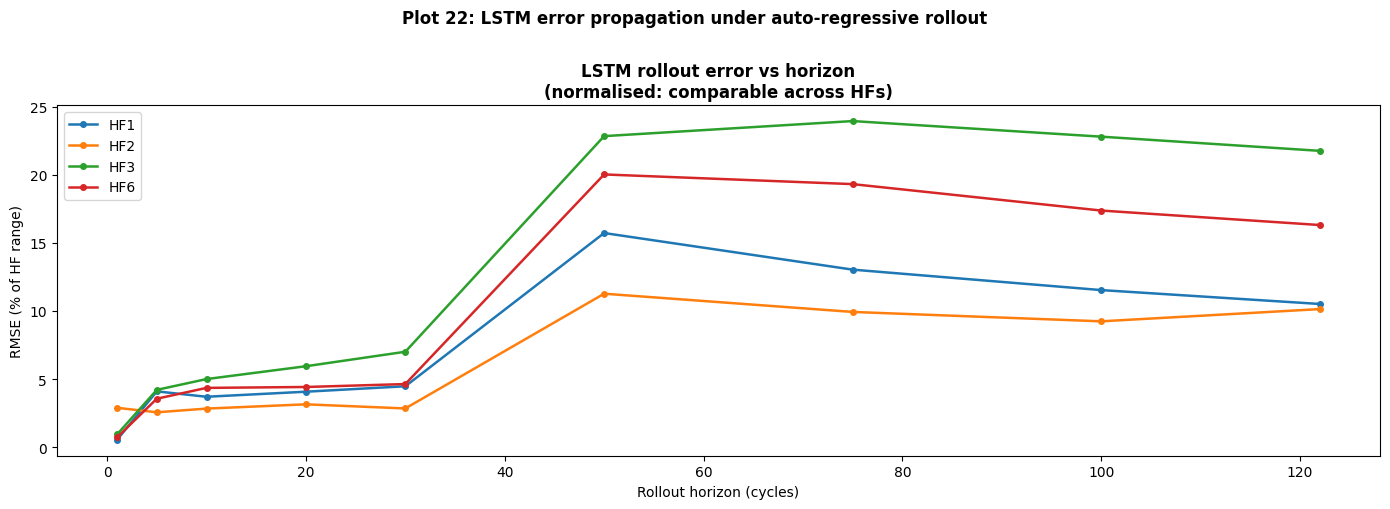

In [81]:
# Inverse transform rollout predictions and true values
pred_hf_rollout = np.zeros_like(predicted_norm)
true_hf_rollout = np.zeros_like(predicted_norm)

df_b0018_sorted = hf_clean[hf_clean["battery"] == TEST_BAT].sort_values("cycle")
true_hf_norm_full = df_b0018_sorted[SELECTED_HFS].values[WINDOW_SIZE:]

for j, hf in enumerate(SELECTED_HFS):
    pred_hf_rollout[:, j] = scalers_hf[hf].inverse_transform(
        predicted_norm[:, j].reshape(-1,1)
    ).flatten()
    true_hf_rollout[:, j] = scalers_hf[hf].inverse_transform(
        true_hf_norm_full[:, j].reshape(-1,1)
    ).flatten()

# Compute RMSE at each horizon step
horizons   = [1, 5, 10, 20, 30, 50, 75, 100, 122]
horizon_results = []

for h in horizons:
    h = min(h, len(pred_hf_rollout))
    rmse_per_hf = {}
    for j, hf in enumerate(SELECTED_HFS):
        rmse_per_hf[hf] = ((true_hf_rollout[:h,j] -
                            pred_hf_rollout[:h,j])**2).mean()**0.5
    horizon_results.append({"horizon": h, **rmse_per_hf})

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.round(4).to_string(index=False))

# Plot
fig, axes = plt.subplots(figsize=(14, 5))

# ax = axes[0]
# for hf in SELECTED_HFS:
#     ax.plot(horizon_df["horizon"], horizon_df[hf],
#             marker="o", markersize=4, linewidth=1.8,
#             label=hf)
# ax.set_xlabel("Rollout horizon (cycles)")
# ax.set_ylabel("RMSE (original units)")
# ax.set_title("LSTM rollout error vs prediction horizon\n"
#              "(each HF in its original unit)", fontweight="bold")
# ax.legend()
# ax.axvline(WINDOW_SIZE, color="gray", linestyle="--",
#            linewidth=0.8, label="Seed window size")

# Normalised version all HFs on same scale
ax = axes
for j, hf in enumerate(SELECTED_HFS):
    # Normalise by the HF's own range
    hf_range = true_hf_rollout[:, j].max() - true_hf_rollout[:, j].min()
    rmse_norm = horizon_df[hf] / hf_range * 100   # % of range
    ax.plot(horizon_df["horizon"], rmse_norm,
            marker="o", markersize=4, linewidth=1.8, label=hf)
ax.set_xlabel("Rollout horizon (cycles)")
ax.set_ylabel("RMSE (% of HF range)")
ax.set_title("LSTM rollout error vs horizon\n"
             "(normalised: comparable across HFs)", fontweight="bold")
ax.legend()

plt.suptitle("Plot 22: LSTM error propagation under auto-regressive rollout",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot22_LSTM_error_propagation.png", dpi=150, bbox_inches="tight")
plt.show()

```
ANALYSIS 3: Degradation rate correlation
Link discharge domain degradation rate to charge HF evolution rate
```

         cap_slope_Ah/cyc  HF1_slope_s/cyc  HF2_slope_V/cyc  HF3_slope_A/cyc  HF6_slope_s/cyc
battery                                                                                      
B0005           -0.003867          -8.0556         0.000566        -0.000652           2.3086
B0006           -0.005087         -12.0710         0.001011        -0.002145           4.1674
B0007           -0.003269          -5.5295         0.000344        -0.000351           1.4985
B0018           -0.003926          -7.8076         0.000463        -0.000329           1.1744

 Pearson correlation: capacity slope vs HF slope
  HF1_slope_s/cyc        r=+0.9972  p=0.0028  significant
  HF2_slope_V/cyc        r=-0.9777  p=0.0223  significant
  HF3_slope_A/cyc        r=+0.9319  p=0.0681  not significant
  HF6_slope_s/cyc        r=-0.8827  p=0.1173  not significant


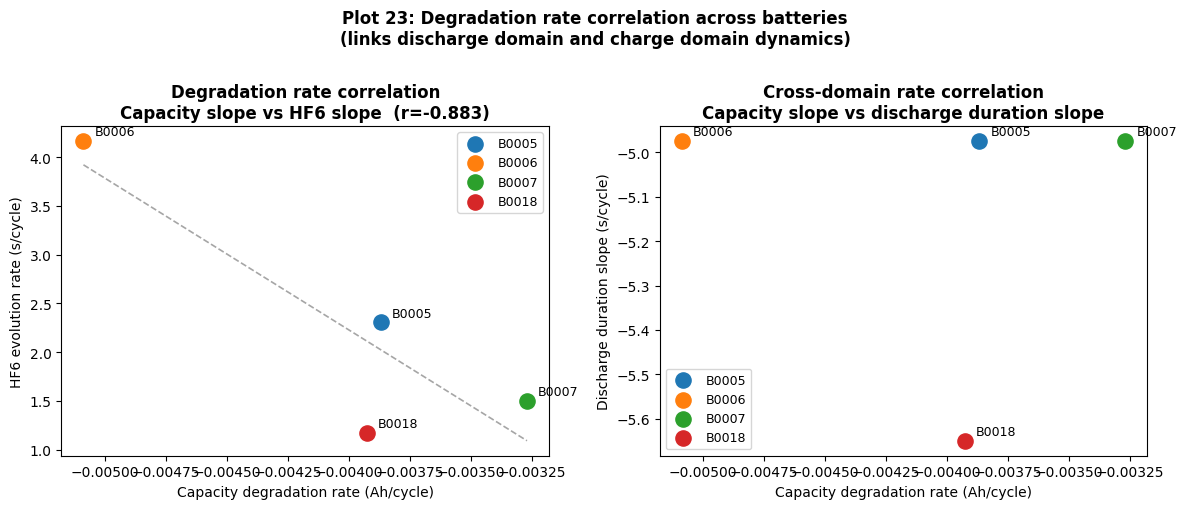

In [82]:
rate_rows = []
for bat in ["B0005","B0006","B0007","B0018"]:

    # Discharge domain: linear fit slope to capacity vs cycle
    sub_cap = feature_df[feature_df["battery"]==bat].sort_values("cycle")
    cycles = sub_cap["cycle"].values
    caps = sub_cap["capacity_Ah"].values
    cap_slope = np.polyfit(cycles, caps, 1)[0]  # Ah per cycle

    # Charge domain: linear fit slope to each HF vs cycle
    sub_hf = hf_df[hf_df["battery"]==bat].sort_values("cycle").dropna(
        subset=SELECTED_HFS
    )
    hf_cycles = sub_hf["cycle"].values
    hf_slopes = {}
    for hf in SELECTED_HFS:
        hf_vals = sub_hf[hf].values
        # Clip outliers before fitting
        mu, sig  = hf_vals.mean(), hf_vals.std()
        mask_hf  = np.abs(hf_vals - mu) < 3*sig
        if mask_hf.sum() > 10:
            hf_slopes[hf] = np.polyfit(
                hf_cycles[mask_hf], hf_vals[mask_hf], 1
            )[0]
        else:
            hf_slopes[hf] = np.nan

    rate_rows.append({
        "battery":bat,
        "cap_slope_Ah/cyc": round(cap_slope, 6),
        "HF1_slope_s/cyc":round(hf_slopes.get("HF1", np.nan), 4),
        "HF2_slope_V/cyc":round(hf_slopes.get("HF2", np.nan), 6),
        "HF3_slope_A/cyc": round(hf_slopes.get("HF3", np.nan), 6),
        "HF6_slope_s/cyc": round(hf_slopes.get("HF6", np.nan), 4),
    })

rate_df = pd.DataFrame(rate_rows).set_index("battery")
print(rate_df.to_string())

# Correlation between cap_slope and each HF slope
print("\n Pearson correlation: capacity slope vs HF slope")
for hf_col in ["HF1_slope_s/cyc","HF2_slope_V/cyc",
                "HF3_slope_A/cyc","HF6_slope_s/cyc"]:
    valid = rate_df[["cap_slope_Ah/cyc", hf_col]].dropna()
    if len(valid) >= 3:
        r, p = pearsonr(valid["cap_slope_Ah/cyc"], valid[hf_col])
        print(f"  {hf_col:<22} r={r:+.4f}  p={p:.4f}  "
              f"{'significant' if p < 0.05 else 'not significant'}")

# Plot: capacity slope vs HF6 slope (expected strongest)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for bat in ["B0005","B0006","B0007","B0018"]:
    row = rate_df.loc[bat]
    col = BAT_COLORS[bat]
    ax.scatter(row["cap_slope_Ah/cyc"], row["HF6_slope_s/cyc"],
               color=col, s=120, zorder=5, label=bat)
    ax.annotate(bat, (row["cap_slope_Ah/cyc"], row["HF6_slope_s/cyc"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Fit line
valid_r = rate_df[["cap_slope_Ah/cyc","HF6_slope_s/cyc"]].dropna()
m, b = np.polyfit(valid_r["cap_slope_Ah/cyc"],
                  valid_r["HF6_slope_s/cyc"], 1)
x_line = np.linspace(valid_r["cap_slope_Ah/cyc"].min(),
                     valid_r["cap_slope_Ah/cyc"].max(), 50)
ax.plot(x_line, m*x_line+b, color="gray",
        linewidth=1.2, linestyle="--", alpha=0.7)
r_val, _ = pearsonr(valid_r["cap_slope_Ah/cyc"],
                    valid_r["HF6_slope_s/cyc"])
ax.set_xlabel("Capacity degradation rate (Ah/cycle)")
ax.set_ylabel("HF6 evolution rate (s/cycle)")
ax.set_title(f"Degradation rate correlation\n"
             f"Capacity slope vs HF6 slope  (r={r_val:.3f})",
             fontweight="bold")
ax.legend(fontsize=9)

# Discharge duration slope vs capacity slope
ax = axes[1]
for bat in ["B0005","B0006","B0007","B0018"]:
    sub = feature_df[feature_df["battery"]==bat].sort_values("cycle")
    cyc_b = sub["cycle"].values
    dur_b = sub["discharge_dur_s"].values
    dur_slope = np.polyfit(cyc_b, dur_b, 1)[0]
    cap_slope = rate_df.loc[bat, "cap_slope_Ah/cyc"]
    ax.scatter(cap_slope, dur_slope,
               color=BAT_COLORS[bat], s=120, zorder=5, label=bat)
    ax.annotate(bat, (cap_slope, dur_slope),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Capacity degradation rate (Ah/cycle)")
ax.set_ylabel("Discharge duration slope (s/cycle)")
ax.set_title("Cross-domain rate correlation\n"
             "Capacity slope vs discharge duration slope",
             fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Plot 23: Degradation rate correlation across batteries\n"
             "(links discharge domain and charge domain dynamics)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot23_degradation_rates.png", dpi=150, bbox_inches="tight")
plt.show()

```
ANALYSIS 4: Cross-domain SHAP convergence
Side-by-side SHAP bar charts: discharge domain vs charge domain
```

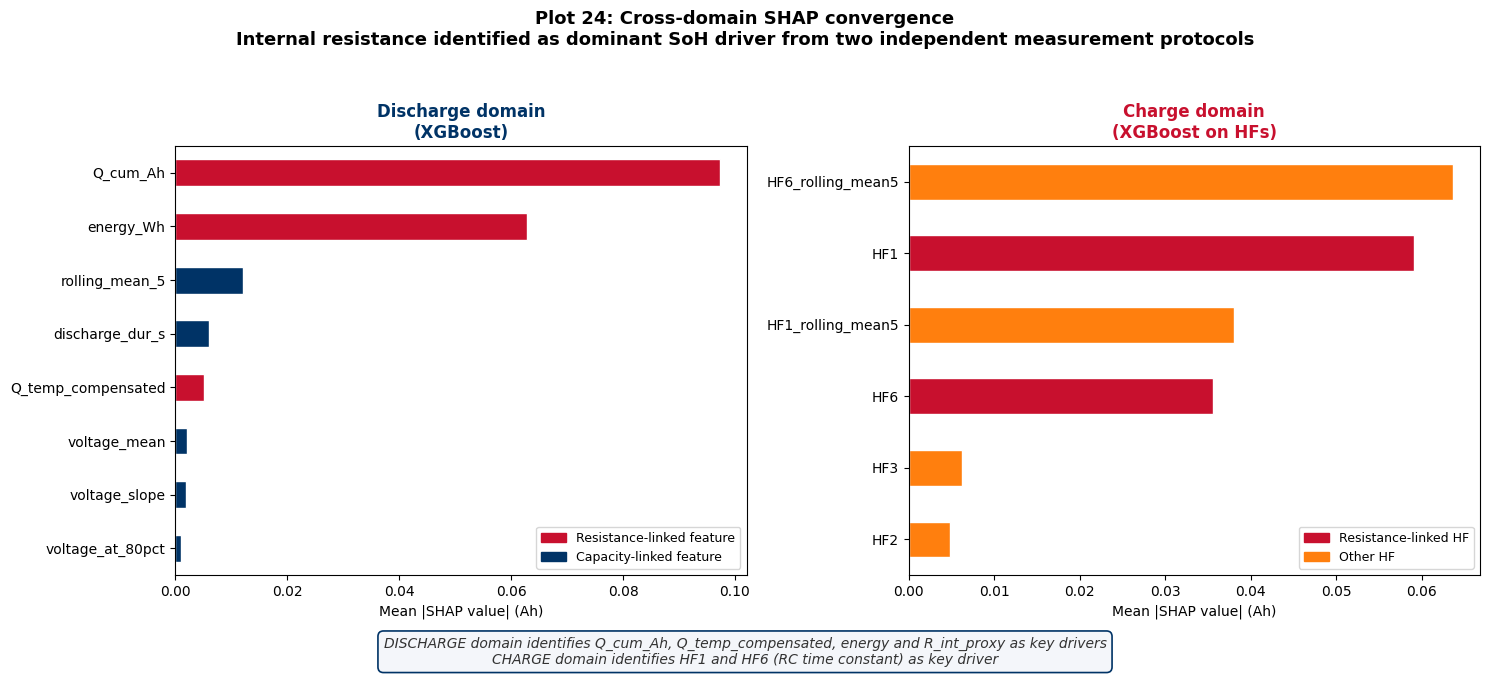


Numerical convergence summary

Discharge domain: top 3 SHAP features:
Q_cum_Ah                     mean|SHAP|=0.09724 Ah
energy_Wh                    mean|SHAP|=0.06290 Ah
rolling_mean_5               mean|SHAP|=0.01208 Ah

Charge domain top 2 SHAP features:
HF6_rolling_mean5 mean|SHAP|=0.06363 Ah
HF1        mean|SHAP|=0.05908 Ah


In [ ]:
# Discharge domain SHAP 
xgb_discharge = trained["XGBoost"]
xgb_inner = xgb_discharge[-1]
scaler_steps = xgb_discharge[:-1]
X_train_xgb = pd.DataFrame(
    scaler_steps.transform(X_train), columns=feat_cols
)
explainer_dis = shap.TreeExplainer(xgb_inner)
shap_dis = explainer_dis(X_train_xgb)
mean_abs_dis = pd.Series(
    np.abs(shap_dis.values).mean(axis=0), index=feat_cols
).sort_values(ascending=False)

# Charge domain SHAP 
mean_abs_hf = pd.Series(
    np.abs(shap_train_hf.values).mean(axis=0),
    index=FEATURES_MAP
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Discharge domain — top 8 features
ax = axes[0]
top8_dis = mean_abs_dis.head(8).sort_values(ascending=True)
r_int_features = {"R_int_proxy","energy_Wh","Q_cum_Ah",
                  "Q_temp_compensated","dQdV_peak_height","dQdV_peak_voltage"}
colors_dis = ["#C8102E" if f in r_int_features else "#003366"
              for f in top8_dis.index]
top8_dis.plot(kind="barh", ax=ax, color=colors_dis, edgecolor="white")
ax.set_xlabel("Mean |SHAP value| (Ah)")
ax.set_title("Discharge domain\n(XGBoost)",
             fontweight="bold", color="#003366")
from matplotlib.patches import Patch, FancyArrowPatch
ax.legend(handles=[
    Patch(color="#C8102E", label="Resistance-linked feature"),
    Patch(color="#003366", label="Capacity-linked feature"),
], fontsize=9, loc="lower right")

# Charge domain
ax = axes[1]
hf_sorted = mean_abs_hf.sort_values(ascending=True)
r_int_hfs = {"HF6", "HF1"}
colors_hf = ["#C8102E" if h in r_int_hfs else "#ff7f0e"
             for h in hf_sorted.index]
hf_sorted.plot(kind="barh", ax=ax, color=colors_hf, edgecolor="white")
ax.set_xlabel("Mean |SHAP value| (Ah)")
ax.set_title("Charge domain\n(XGBoost on HFs)",
             fontweight="bold", color="#C8102E")
ax.legend(handles=[
    Patch(color="#C8102E", label="Resistance-linked HF"),
    Patch(color="#ff7f0e", label="Other HF"),
], fontsize=9, loc="lower right")

# Central convergence annotation
fig.text(0.5, -0.05,
         "DISCHARGE domain identifies Q_cum_Ah, Q_temp_compensated, energy and R_int_proxy as key drivers"
         "\nCHARGE domain identifies HF1 and HF6 (RC time constant) as key driver",
         ha="center", fontsize=10, style="italic",
         color="#333333",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#F4F6FA",
                   edgecolor="#003366", linewidth=1.2))

plt.suptitle("Plot 24: Cross-domain SHAP convergence\n"
             "Internal resistance identified as dominant SoH driver "
             "from two independent measurement protocols",
             fontweight="bold", y=1.04, fontsize=13)
plt.tight_layout()
plt.savefig("./assets/plot24_shap_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# summary
print("\nNumerical convergence summary")
print(f"\nDischarge domain: top 3 SHAP features:")
for feat, val in mean_abs_dis.head(3).items():
    print(f"{feat:<28} mean|SHAP|={val:.5f} Ah")

print(f"\nCharge domain top 2 SHAP features:")
for feat, val in mean_abs_hf.head(2).items():
    print(f"{feat:<10} mean|SHAP|={val:.5f} Ah")

```
SHAP analysis across two independent measurement domains reveals convergent evidence for a two-pathway degradation model. 
The discharge domain identifies cumulative energy throughput (energy_Wh, Q_cum_Ah) as the dominant SoH drivers directly quantifying capacity delivered per cycle. 
The charge domain identifies the RC time constant trend (HF6_rolling_mean5) and CC charging time (HF1) as dominant drivers, quantifying how internal resistance affects the charging rate. 
Both pathways measure the same underlying phenomenon: as internal resistance increases with aging, less energy is delivered per discharge cycle and more time is required per charge cycle. 
EIS measurements of Rct (r=−0.70) and Re (r=−0.64) provide independent electrochemical confirmation that resistance increase accompanies capacity fade, though with moderate correlation strength on this four-battery dataset. Together, these findings support a causal model where aging-driven resistance increase is the primary mediator between cycle count and capacity fade
```

# DEPLOYMENT

## GIT Deployed
For reproducability the project is hosted on git hub repo: [battery-soh-ml](https://github.com/adithyaprasadsv/battery-soh-ml)

## Model Limitations and Scope of Validity

### Performance summary

| Model | Domain | B0018 SoH RMSE (Ah) | Evaluation |
|---|---|---|---|
| Ridge | Discharge features (True) | 0.0041 | Cross-battery holdout |
| XGBoost | Discharge features (True) | 0.0069 | Cross-battery holdout |
| XGBoost (LSTM-forecasted HFs: raw) | Charge features | 0.0594 | Cross-battery holdout |
| XGBoost (LSTM-forecasted HFs: Q75) | Charge features | 0.0434 | Cross-battery holdout |
| XGBoost (LSTM-forecasted HFs: True) | Charge features | 0.0579 | Cross-battery holdout |

The within-battery (paper) and cross-battery evaluations are not directly comparable. The above table only summarizes all the model results with the respective strategy. Also charge and discharge model outcomes are not directly comparable, the models serve the interest of diving into the explainability of drivers for battery capacity.

### RUL RMSE on B0018 (Linear Extrapolation)

| Model                 | Early (1–44)     | Mid (45–88)     | Late (89–132)     | Overall |
|-----------------------|------------------|------------------|--------------------|---------|
| Ridge (discharge)     | 14.18 (n=34)     | 6.47 (n=44)      | 0.94 (n=44)        | 8.45    |
| XGBoost (discharge)   | 13.59 (n=34)     | 6.44 (n=44)      | 1.29 (n=44)        | 8.19    |
| XGBoost-HF raw        | 23.48 (n=24)     | 13.59 (n=44)     | 2.15 (n=44)        | 13.88   |
| XGBoost-HF true HF    | 71.46 (n=24)     | 59.09 (n=44)     | 21.68 (n=44)       | 51.49   |
| XGBoost-HF Q75        | 14.72 (n=24)     | 2.59 (n=44)      | 2.53 (n=44)        | 7.18    |
| XGBoost-HF Q90        | 10.77 (n=24)     | 5.69 (n=44)      | 8.70 (n=44)        | 8.20    |


### Scope of validity

This model was trained and validated exclusively on the NASA PCoE lithium-ion battery
dataset (B0005, B0006, B0007 for training; B0018 held out for testing). Predictions should
**not** be assumed to generalize beyond the following conditions present in that dataset:

- **Chemistry**: 18650 LiCoO₂ cells, rated ~2.0 Ah (1.86 Ah for B0018).
- **Charge protocol**: 1.5 A constant-current to 4.2 V, followed by constant-voltage until
  charge current drops to 20 mA.
- **Discharge protocol**: constant 2 A load to a fixed cutoff voltage (2.7 V / 2.5 V / 2.2 V
  depending on battery).
- **Ambient temperature**: ~24°C, controlled lab conditions, no thermal cycling, no
  field-representative temperature swings.
- **Cycle count**: validated over roughly 130–170 cycles per battery; extrapolation
  behavior beyond the observed cycle range is untested.

Application of this model to a different chemistry, charge/discharge protocol, or operating
temperature (e.g. a real EV or grid-storage deployment) would require retraining and
re-validation of the physics-informed features (R_int_proxy, HF6 RC time constant). They are
likely to transfer conceptually, but the fitted numeric relationships will differ.

### Failure modes

- **Cross-battery generalization gap for B0006-like conditions.** Leave-one-battery-out
  validation showed substantially higher validation loss when B0006 was held out
  (val loss ~0.85–0.95, vs. ~0.1–0.3 for the other two folds), despite normal training
  convergence. B0018 shares B0006's discharge cutoff voltage (2.5 V), so this gap is a
  meaningful caveat for the actual holdout evaluation, not just a CV artifact.
- **LSTM rollout error accumulation.** The auto-regressive health-factor forecast is seeded
  from only the first 10 true cycles and then self-feeds for the remaining ~120+ cycles.
  Forecast error compounds over that horizon. HF predictions late in a battery's life are
  measurably less reliable than early-life predictions.
- **Capacity-regeneration events are not modeled.** Both the discharge features and the
  charge-domain health factors show sharp, transient capacity increases (a known
  electrochemical phenomenon) that neither the LSTM nor XGBoost explicitly models and are 
  treated as prediction spikes/errors around regeneration cycles rather than being predicted
  in advance.
- **Small sample size.** Only 3 batteries utilized for training (4 including the
  holdout). All cross-validation and error estimates in this project should be read as
  indicative, not statistically robust. A single "unusual" battery can dominate an
  aggregate metric, as seen with B0006.

### Comparison to published benchmark

Zhao et al. (2022) report an RMSE of 0.0150 Ah for their GPR+LSTM SoH model on the same
underlying battery data, but under a **within-battery** train/test split, the model is
fit and evaluated on data from the same battery, just different cycle ranges. This project
deliberately used a stricter **cross-battery** holdout (train on B0005/B0006/B0007, test
entirely on unseen B0018) because it better reflects a realistic deployment scenario where
the model must generalize to a battery it has never seen. The higher error under this
stricter evaluation is expected and should not be read as underperformance relative to the benchmark.
Similarly the discharge based model has lower error as it utilizes true values from the NASA tests, hence
is not directly comparable and does not indicate true better performance to benchmark.

### Real BMS Deployment (hypothetical)

- **Input validation**: incoming cycle data should be checked against the training
  distribution (e.g., R_int_proxy range, discharge duration range) before inference;
  out-of-range inputs should trigger a fallback/flag rather than a silent extrapolation.
- **Retraining triggers**: a change in cell chemistry, charge/discharge protocol, or a
  systematic drift in resistance/capacity trends relative to the training batteries should
  trigger retraining rather than continued use of this fixed model.
- **Safety consideration**: RUL under-prediction (predicting less life than actually
  remains) is operationally costly but safe; RUL over-prediction (predicting more life than
  actually remains) is the failure mode that matters for safety-critical use and should be
  the focus of any further error analysis before real deployment.